# One-dimensional stochastic degradation model

In this part, we simulate and estimate a one-dimensional stochastic degradation model for machine health indices.

The model has the form

$$
S(t) = R(t) + T(t),
$$

where $T(t)$ is a deterministic trend and $R(t)$ is a random component. The random component is defined as

$$
R(t) = SC(t)R2(t),
$$

where $SC(t)$ is a time-varying scale function and $R2(t)$ is a stationary autoregressive process.

The goal of this section is to:
1. simulate data from the model,
2. estimate the trend and scale,
3. normalize the random component,
4. fit an AR model,
5. estimate the stability index $\alpha$ of the residual noise.

In [1]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import simulation1d
import estimation1d

importlib.reload(simulation1d)
importlib.reload(estimation1d)

from simulation1d import simulate_1d_model
from estimation1d import estimate_1d_model, summarize_1d_estimation, estimate_1d_model_fixed_ar_order

## Simulation parameters

We use the same general parameter setting as in the reference methodology:

$$
N=2000,\quad \tau_1=N/3,\quad \tau_2=2N/3.
$$

The random component is generated from an AR(1) model with coefficient $\phi=0.5$. The scale function increases from 
$\sigma_1=1$ to $\sigma_4=25$, and the deterministic trend starts from $c_1=10$.

In [2]:
N = 2000
tau1 = N / 3
tau2 = 2 * N / 3

base_params = dict(
    N=N,
    tau1=tau1,
    tau2=tau2,
    phi=(0.5,),
    gamma=1.0,
    sigma1=1.0,
    sigma2=2.5,
    sigma3=5.0,
    sigma4=25.0,
    c1=10.0,
)

## Single trajectory simulation

First, we simulate one trajectory for $\alpha=1.9$. This corresponds to a non-Gaussian heavy-tailed noise distribution. We expect the signal to be relatively stable at the beginning and more volatile in the final degradation regime due to the increasing scale.

In [3]:
simulation = simulate_1d_model(
    **base_params,
    alpha=1.9,
    random_state=42,
)

simulation.keys()

dict_keys(['t', 'S', 'R', 'R2', 'R3', 'SC', 'T', 'scale_params', 'trend_params', 'params'])

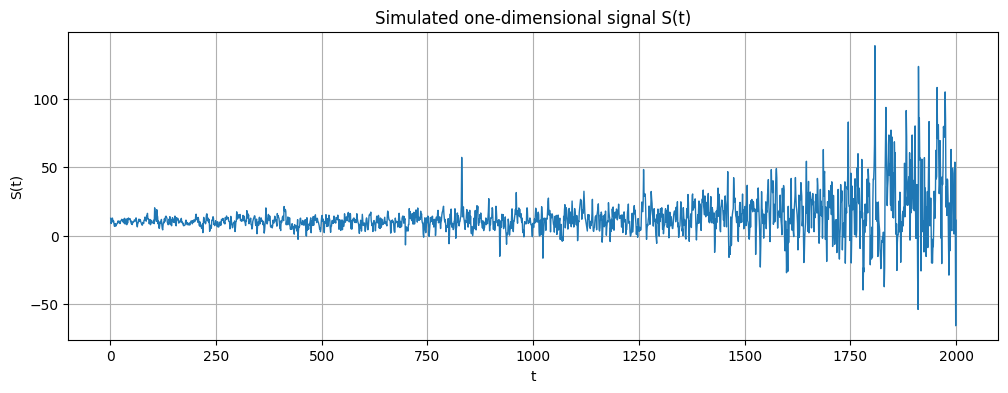

In [4]:
t = simulation["t"]

plt.figure(figsize=(12, 4))
plt.plot(t, simulation["S"], linewidth=1)
plt.title("Simulated one-dimensional signal S(t)")
plt.xlabel("t")
plt.ylabel("S(t)")
plt.grid(True)
plt.show()

The simulated signal shows three qualitative stages. In the initial part, the variability is relatively low. Later, both the trend and the scale increase. In the final regime, the signal becomes much more volatile, which reflects the accelerated degradation stage.

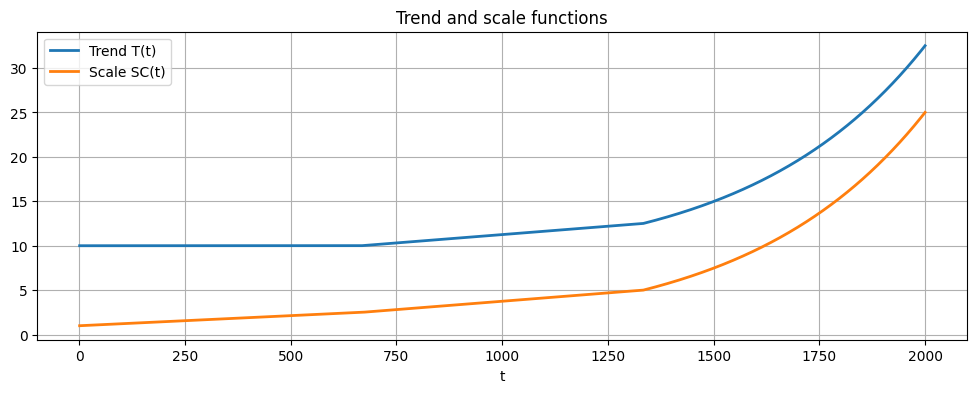

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(t, simulation["T"], label="Trend T(t)", linewidth=2)
plt.plot(t, simulation["SC"], label="Scale SC(t)", linewidth=2)
plt.title("Trend and scale functions")
plt.xlabel("t")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
SC = simulation["SC"]
T = simulation["T"]

idx_tau1 = int(tau1) - 1
idx_tau2 = int(tau2) - 1

boundary_check = pd.DataFrame({
    "quantity": ["SC(1)", "SC(tau1 approx)", "SC(tau2 approx)", "SC(N)", "T(1)", "T(N)"],
    "value": [
        SC[0],
        SC[idx_tau1],
        SC[idx_tau2],
        SC[-1],
        T[0],
        T[-1],
    ]
})

boundary_check

,quantity,value
0,SC(1),1.000000
1,SC(tau1 approx),2.498498
2,SC(tau2 approx),4.998750
3,SC(N),25.000000
4,T(1),10.000000
5,T(N),32.500000


## One-dimensional estimation

The estimation procedure is applied in the reverse order compared to simulation. First, the deterministic trend is estimated using a moving median. Then the trend is removed, the time-varying scale is estimated with a robust scale estimator, and the random component is normalized. Finally, an AR model is fitted to remove temporal dependence, and the stability index $\alpha$ is estimated from the residuals using McCulloch's quantile method.

In [7]:
est = estimate_1d_model(
    simulation["S"],
    trend_window=101,
    scale_window=151,
    p_max=5,
    h_max=30,
    include_zero_order=True,
    relative_tolerance=0.10,
)

summarize_1d_estimation(est)

One-dimensional estimation summary
---------------------------------
Estimated AR order p_opt: 1
Estimated phi: [0.50130107]
Estimated intercept: 0.0
Estimated alpha: 1.9127

AR order candidates:
  p=0: K=0.251303
  p=1: K=0.00372695
  p=2: K=0.00390953
  p=3: K=0.00393131
  p=4: K=0.00357815
  p=5: K=0.00373268


The diagnostic statistic $K$ reached its absolute minimum for $p=4$, but the value obtained for $p=1$ was almost identical. Since the data were generated from an AR(1) process and the robust ACF of the residuals after fitting AR(1) was already close to zero, we selected the simpler AR(1) model. This avoids unnecessary overfitting while preserving the main temporal dependence structure.

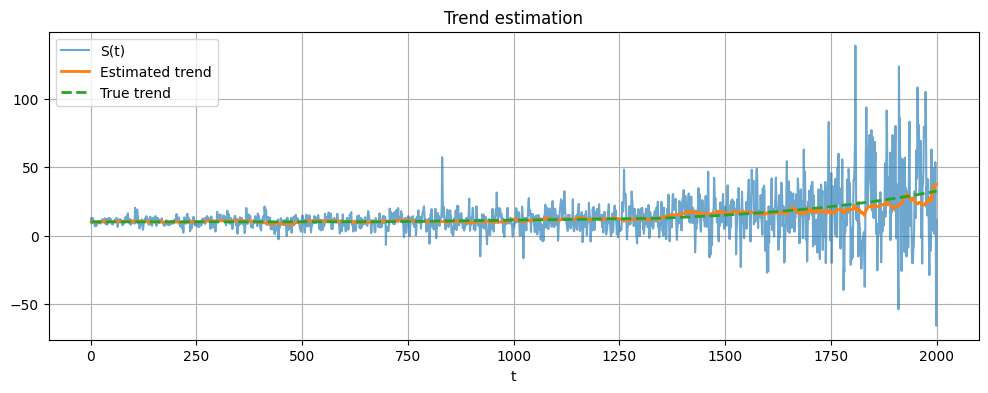

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(t, simulation["S"], label="S(t)", alpha=0.65)
plt.plot(t, est["T_hat"], label="Estimated trend", linewidth=2)
plt.plot(t, simulation["T"], label="True trend", linewidth=2, linestyle="--")
plt.title("Trend estimation")
plt.xlabel("t")
plt.legend()
plt.grid(True)
plt.show()

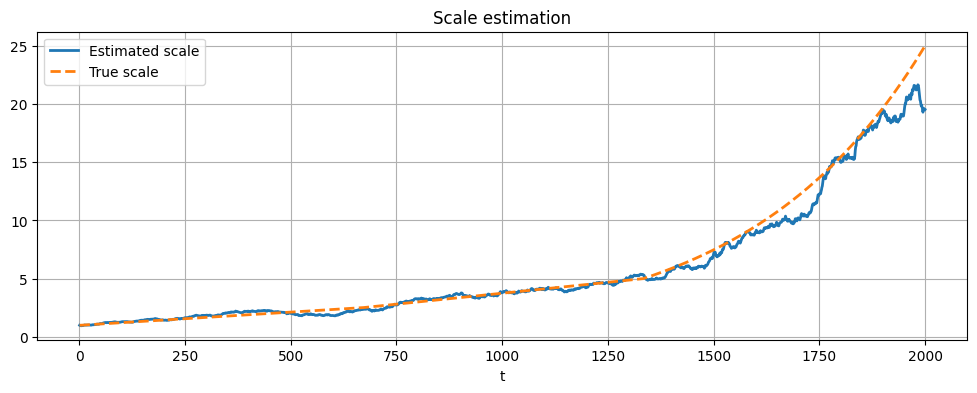

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(t, est["SC_hat"], label="Estimated scale", linewidth=2)
plt.plot(t, simulation["SC"], label="True scale", linewidth=2, linestyle="--")
plt.title("Scale estimation")
plt.xlabel("t")
plt.legend()
plt.grid(True)
plt.show()

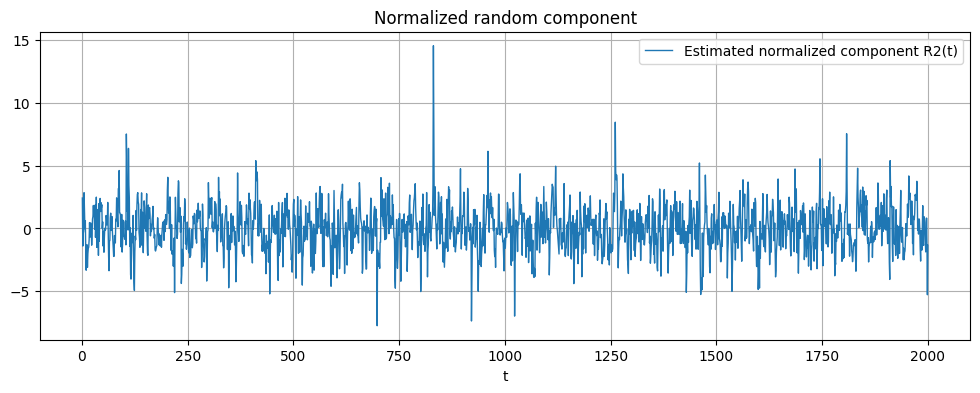

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(t, est["R2_hat"], label="Estimated normalized component R2(t)", linewidth=1)
plt.title("Normalized random component")
plt.xlabel("t")
plt.legend()
plt.grid(True)
plt.show()

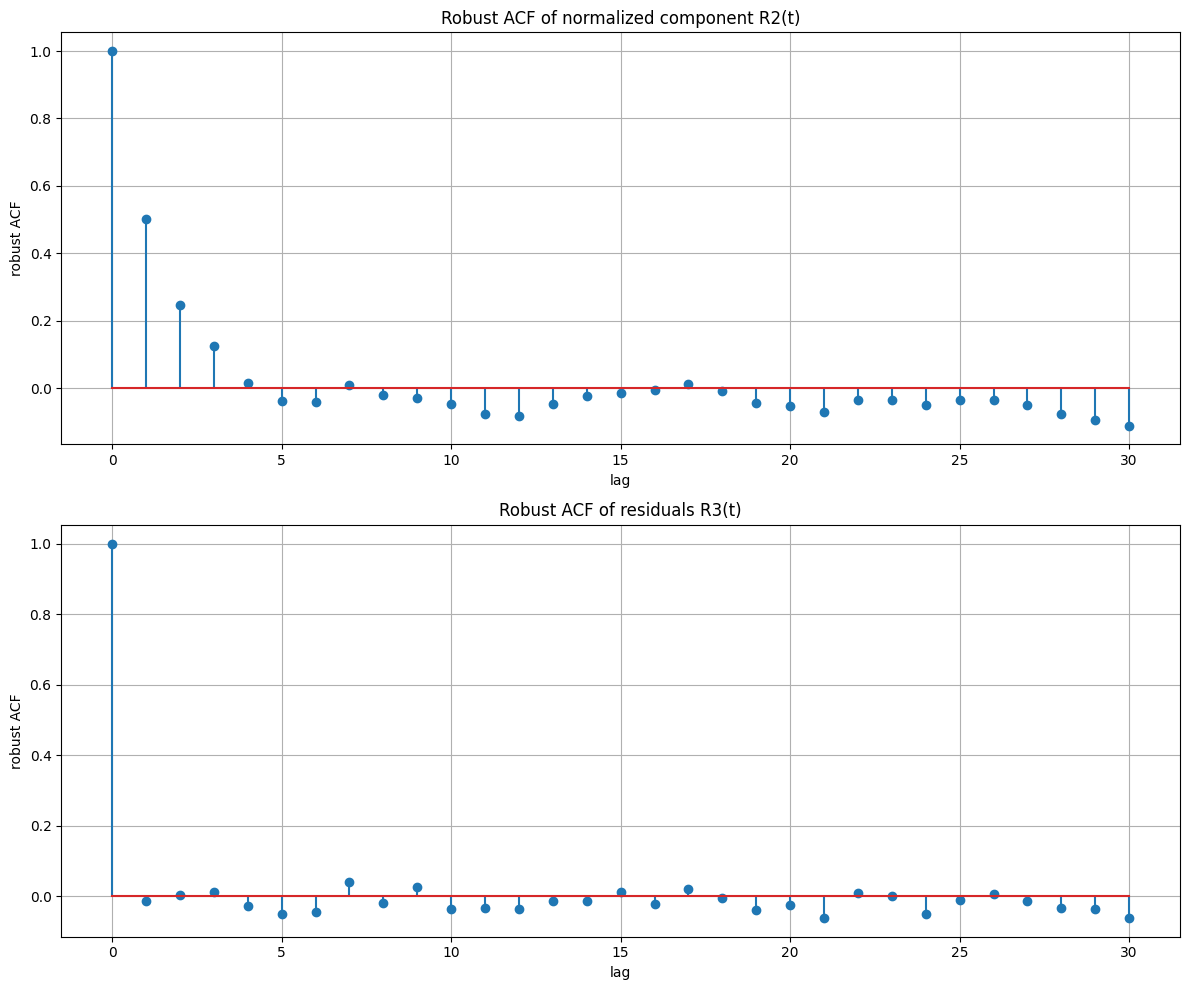

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].stem(range(len(est["acf_R2"])), est["acf_R2"])
axes[0].set_title("Robust ACF of normalized component R2(t)")
axes[0].set_xlabel("lag")
axes[0].set_ylabel("robust ACF")
axes[0].grid(True)

axes[1].stem(range(len(est["acf_R3"])), est["acf_R3"])
axes[1].set_title("Robust ACF of residuals R3(t)")
axes[1].set_xlabel("lag")
axes[1].set_ylabel("robust ACF")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [16]:
ar_table = pd.DataFrame([
    {
        "p": item["p"],
        "K": item["K"],
        "selected": item["p"] == est["p_opt"],
    }
    for item in est["ar_candidates"]
])

ar_table

,p,K,selected
0,0,0.251303,False
1,1,0.003727,True
2,2,0.003910,False
3,3,0.003931,False
4,4,0.003578,False
5,5,0.003733,False


The diagnostic statistic $K$ is computed from the robust ACF of residuals. The absolute minimum can sometimes be achieved by a higher-order AR model, but the improvement may be negligible. Therefore, we use a simple parsimony rule: we select the smallest AR order whose diagnostic statistic is within 10% of the best value.

In this experiment, $p=1$ is selected. This is consistent with the data-generating process, because the simulated normalized component was generated from an AR(1) model with coefficient $\phi=0.5$.

In [17]:
single_run_summary = pd.DataFrame({
    "parameter": ["alpha", "phi", "AR order"],
    "true value": [1.9, 0.5, 1],
    "estimated value": [
        est["alpha_hat"],
        est["phi_hat"][0] if len(est["phi_hat"]) > 0 else np.nan,
        est["p_opt"],
    ],
})

single_run_summary

,parameter,true value,estimated value
0,alpha,1.9,1.912686
1,phi,0.5,0.501301
2,AR order,1.0,1.000000


## Comparison for different stability indices

We now repeat the simulation and estimation for several values of the stability index:

$$
\alpha \in \{2.00, 1.95, 1.90, 1.85\}.
$$

The case $\alpha=2$ corresponds to the Gaussian case, while smaller values of $\alpha$ produce heavier tails and more impulsive behaviour.

In [145]:
alphas = [2.0, 1.95, 1.9, 1.85]

simulations_by_alpha = {}
estimations_by_alpha = {}

for alpha in alphas:
    sim_alpha = simulate_1d_model(
        **base_params,
        alpha=alpha,
        random_state=42,
    )

    est_alpha = estimate_1d_model(
        sim_alpha["S"],
        trend_window=101,
        scale_window=151,
        p_max=5,
        h_max=30,
        include_zero_order=True,
        relative_tolerance=0.10,
    )

    simulations_by_alpha[alpha] = sim_alpha
    estimations_by_alpha[alpha] = est_alpha

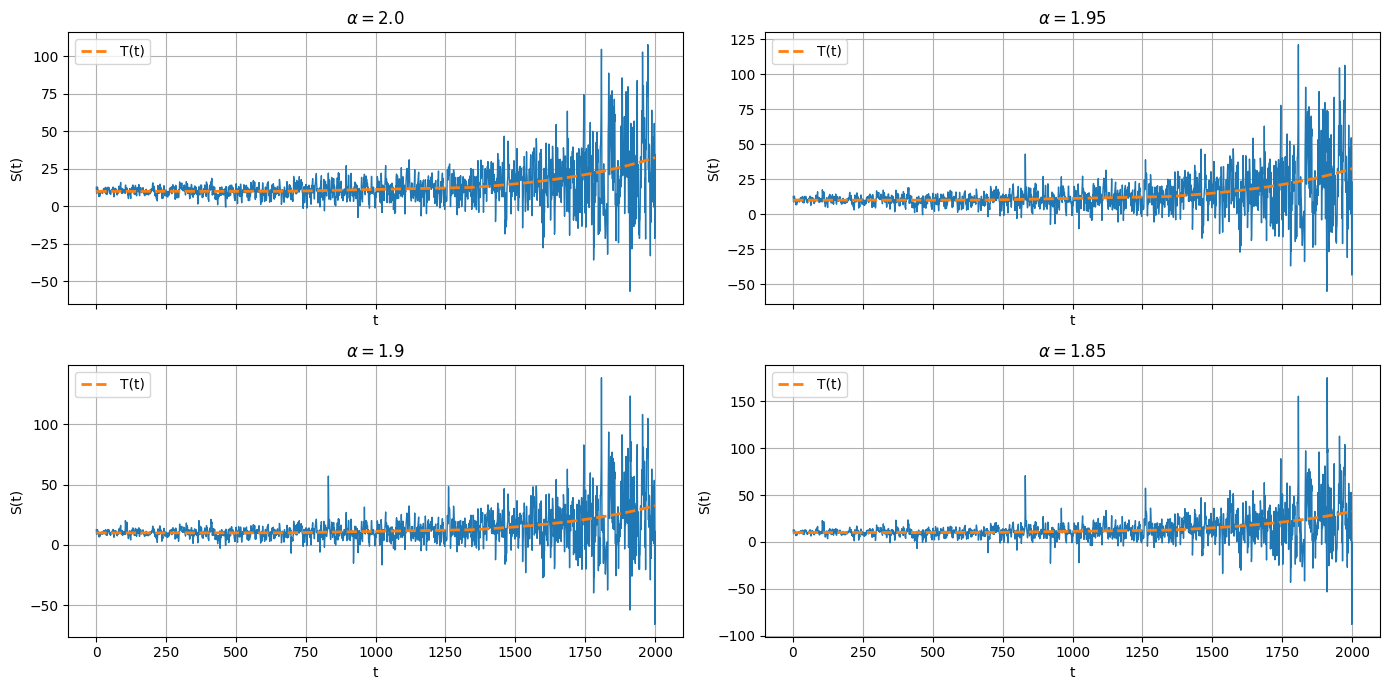

In [148]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
axes = axes.ravel()

for ax, alpha in zip(axes, alphas):
    sim_alpha = simulations_by_alpha[alpha]
    ax.plot(sim_alpha["t"], sim_alpha["S"], linewidth=1)
    ax.plot(sim_alpha["t"], sim_alpha["T"], linewidth=2, linestyle="--", label="T(t)")
    ax.set_title(rf"$\alpha = {alpha}$")
    ax.set_xlabel("t")
    ax.set_ylabel("S(t)")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

In [149]:
alpha_comparison_rows = []

for alpha in alphas:
    est_alpha = estimations_by_alpha[alpha]

    phi_est = est_alpha["phi_hat"][0] if len(est_alpha["phi_hat"]) > 0 else np.nan

    alpha_comparison_rows.append({
        "true_alpha": alpha,
        "estimated_alpha": est_alpha["alpha_hat"],
        "true_phi": 0.5,
        "estimated_phi": phi_est,
        "p_opt": est_alpha["p_opt"],
    })

alpha_comparison = pd.DataFrame(alpha_comparison_rows)
alpha_comparison

,true_alpha,estimated_alpha,true_phi,estimated_phi,p_opt
0,2.00,2.000000,0.5,0.492804,1
1,1.95,1.970024,0.5,0.497912,1
2,1.90,1.912686,0.5,0.501301,1
3,1.85,1.845556,0.5,0.503290,1


# MONTE CARLO

To evaluate the estimation procedure more reliably, we repeat the simulation-estimation pipeline several times for each value of $\alpha$. For each replication, a new trajectory is generated and the full estimation procedure is applied.

This allows us to assess the variability of the estimates instead of relying on a single trajectory.

# NEEDED FUNCTIONS

In [5]:
def run_single_1d_experiment(alpha, seed):
    sim_exp = simulate_1d_model(
        **base_params,
        alpha=alpha,
        random_state=seed,
    )

    est_exp = estimate_1d_model(
        sim_exp["S"],
        trend_window=501,
        scale_window=151,
        p_max=5,
        h_max=30,
        include_zero_order=True,
        relative_tolerance=0.10,
    )

    phi_est = est_exp["phi_hat"][0] if len(est_exp["phi_hat"]) > 0 else np.nan

    return {
        "true_alpha": alpha,
        "estimated_alpha": est_exp["alpha_hat"],
        "true_phi": 0.5,
        "estimated_phi": phi_est,
        "p_opt": est_exp["p_opt"],
    }

In [6]:
def run_mc_1d_for_alpha(
    alpha,
    n_replications=100,
    base_seed=10_000,
    trend_window=501,
    scale_window=151,
):
    T_hats = []
    SC_hats = []
    phi_hats = []
    alpha_hats = []

    representative_sim = None
    representative_est = None

    for rep in range(n_replications):
        seed = base_seed + rep

        sim_rep = simulate_1d_model(
            **base_params,
            alpha=alpha,
            random_state=seed,
        )

        est_rep = estimate_1d_model_fixed_ar_order(
            sim_rep["S"],
            trend_window=trend_window,
            scale_window=scale_window,
            ar_order=1,
            h_max=30,
            compute_diagnostics=(rep == 0),
        )

        T_hats.append(est_rep["T_hat"])
        SC_hats.append(est_rep["SC_hat"])
        phi_hats.append(est_rep["phi_hat"][0])
        alpha_hats.append(est_rep["alpha_hat"])

        if rep == 0:
            representative_sim = sim_rep
            representative_est = est_rep

    return {
        "alpha": alpha,
        "t": representative_sim["t"],
        "true_T": representative_sim["T"],
        "true_SC": representative_sim["SC"],
        "T_hats": np.asarray(T_hats),
        "SC_hats": np.asarray(SC_hats),
        "phi_hats": np.asarray(phi_hats),
        "alpha_hats": np.asarray(alpha_hats),
        "representative_sim": representative_sim,
        "representative_est": representative_est,
    }

# Poprawka - oddzielne wykresy

In [8]:
def plot_1d_trend_trajectories(result):
    alpha = result["alpha"]
    t = result["t"]
    true_trend = result["true_T"]
    trend_estimates = result["T_hats"]

    plt.figure(figsize=(8, 5))

    for tr in trend_estimates:
        plt.plot(t, tr, color="gray", alpha=0.15, linewidth=0.8)

    plt.plot(t, true_trend, color="blue", linewidth=2.5, label="True trend")

    plt.title(rf"Estimated trend trajectories, $\alpha={alpha}$")
    plt.xlabel("t")
    plt.ylabel("T(t)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [9]:
def plot_1d_scale_trajectories(result):
    alpha = result["alpha"]
    t = result["t"]
    true_scale = result["true_SC"]
    scale_estimates = result["SC_hats"]

    plt.figure(figsize=(8, 5))

    for sc in scale_estimates:
        plt.plot(t, sc, color="gray", alpha=0.15, linewidth=0.8)

    plt.plot(t, true_scale, color="orange", linewidth=2.5, label="True scale")

    plt.title(rf"Estimated scale trajectories, $\alpha={alpha}$")
    plt.xlabel("t")
    plt.ylabel("SC(t)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [10]:
def plot_1d_phi_boxplot(result, true_phi=0.5):
    phi_hats = result["phi_hats"]

    plt.figure(figsize=(5, 5))
    plt.boxplot(phi_hats)
    plt.axhline(true_phi, color="red", linestyle="--", label=rf"true $\phi={true_phi}$")

    plt.title("Distribution of AR(1) coefficient estimates")
    plt.ylabel(r"$\hat{\phi}$")
    plt.xticks([1], [r"$\hat{\phi}$"])
    plt.legend()
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()

In [11]:
def plot_1d_alpha_boxplot(result):
    alpha = result["alpha"]
    alpha_hats = result["alpha_hats"]

    plt.figure(figsize=(5, 5))
    plt.boxplot(alpha_hats)
    plt.axhline(alpha, color="red", linestyle="--", label=rf"true $\alpha={alpha}$")

    plt.title("Distribution of stability index estimates")
    plt.ylabel(r"$\hat{\alpha}$")
    plt.xticks([1], [r"$\hat{\alpha}$"])
    plt.legend()
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()

In [12]:
def plot_1d_acf_before(result):
    alpha = result["alpha"]
    est_rep = result["representative_est"]

    acf_before = est_rep["acf_R2"]
    R2_hat = est_rep["R2_hat"]

    lags = np.arange(len(acf_before))
    band = 1.96 / np.sqrt(len(R2_hat))

    plt.figure(figsize=(8, 4.5))
    plt.stem(lags, acf_before)
    plt.axhline(0, color="red", linewidth=1)
    plt.axhline(band, linestyle="--", label="95% band")
    plt.axhline(-band, linestyle="--")

    plt.title(rf"Before AR(1): robust ACF of $R2(t)$, $\alpha={alpha}$")
    plt.xlabel("Lag")
    plt.ylabel("Robust ACF")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [13]:
def plot_1d_acf_after(result):
    alpha = result["alpha"]
    est_rep = result["representative_est"]

    acf_after = est_rep["acf_R3"]
    R3_hat = est_rep["R3_hat"]

    lags = np.arange(len(acf_after))
    band = 1.96 / np.sqrt(len(R3_hat))

    plt.figure(figsize=(8, 4.5))
    plt.stem(lags, acf_after)
    plt.axhline(0, color="red", linewidth=1)
    plt.axhline(band, linestyle="--", label="95% band")
    plt.axhline(-band, linestyle="--")

    plt.title(rf"After AR(1): robust ACF of residuals, $\alpha={alpha}$")
    plt.xlabel("Lag")
    plt.ylabel("Robust ACF")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [14]:
def plot_1d_median_trend(result):
    alpha = result["alpha"]
    t = result["t"]

    true_trend = result["true_T"]
    T_hats = result["T_hats"]

    median_trend = np.median(T_hats, axis=0)
    q05_trend = np.quantile(T_hats, 0.05, axis=0)
    q95_trend = np.quantile(T_hats, 0.95, axis=0)

    plt.figure(figsize=(8, 5))
    plt.fill_between(t, q05_trend, q95_trend, alpha=0.25, label="5%-95% band")
    plt.plot(t, true_trend, linestyle="--", linewidth=2.2, label="True trend")
    plt.plot(t, median_trend, linewidth=2.2, label="Median estimated trend")

    plt.title(rf"Median trend estimate, $\alpha={alpha}$")
    plt.xlabel("t")
    plt.ylabel("T(t)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [15]:
def plot_1d_median_scale(result):
    alpha = result["alpha"]
    t = result["t"]

    true_scale = result["true_SC"]
    SC_hats = result["SC_hats"]

    median_scale = np.median(SC_hats, axis=0)
    q05_scale = np.quantile(SC_hats, 0.05, axis=0)
    q95_scale = np.quantile(SC_hats, 0.95, axis=0)

    plt.figure(figsize=(8, 5))
    plt.fill_between(t, q05_scale, q95_scale, alpha=0.25, label="5%-95% band")
    plt.plot(t, true_scale, linestyle="--", linewidth=2.2, label="True scale")
    plt.plot(t, median_scale, linewidth=2.2, label="Median estimated scale")

    plt.title(rf"Median scale estimate, $\alpha={alpha}$")
    plt.xlabel("t")
    plt.ylabel("SC(t)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [16]:
def plot_1d_residuals_after_ar(result):
    alpha = result["alpha"]
    est_rep = result["representative_est"]

    R3_hat = est_rep["R3_hat"]
    t_res = np.arange(1, len(R3_hat) + 1)

    plt.figure(figsize=(9, 4.5))
    plt.plot(t_res, R3_hat, linewidth=1)

    plt.axhline(0, color="red", linewidth=1)

    plt.title(rf"Estimated residuals after AR(1), $\alpha={alpha}$")
    plt.xlabel("t")
    plt.ylabel(r"$\hat{R3}(t)$")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [17]:
def plot_1d_normalized_component(result):
    alpha = result["alpha"]
    est_rep = result["representative_est"]

    R2_hat = est_rep["R2_hat"]
    t = np.arange(1, len(R2_hat) + 1)

    plt.figure(figsize=(9, 4.5))
    plt.plot(t, R2_hat, linewidth=1)

    plt.axhline(0, color="red", linewidth=1)

    plt.title(rf"Estimated normalized random component $R2(t)$, $\alpha={alpha}$")
    plt.xlabel("t")
    plt.ylabel(r"$\hat{R2}(t)$")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# SiMULATION (FOR N=100)

In [7]:
mc_1d_final = {}

alphas_order = [1.85, 1.90, 1.95, 2.00]
n_replications = 100

for idx, alpha in enumerate(alphas_order):
    print(f"Running FINAL Monte Carlo for alpha={alpha}...")
    mc_1d_final[alpha] = run_mc_1d_for_alpha(
        alpha=alpha,
        n_replications=n_replications,
        base_seed=10_000 + idx * 10_000,
        trend_window=501,
        scale_window=151,
    )

print("Done.")

Running FINAL Monte Carlo for alpha=1.85...
Running FINAL Monte Carlo for alpha=1.9...
Running FINAL Monte Carlo for alpha=1.95...
Running FINAL Monte Carlo for alpha=2.0...
Done.


In [18]:
final_summary = []

for alpha in alphas_order:
    final_summary.append({
        "alpha": alpha,
        "mean_phi": np.mean(mc_1d_final[alpha]["phi_hats"]),
        "median_phi": np.median(mc_1d_final[alpha]["phi_hats"]),
        "std_phi": np.std(mc_1d_final[alpha]["phi_hats"], ddof=1),
        "mean_alpha_hat": np.mean(mc_1d_final[alpha]["alpha_hats"]),
        "median_alpha_hat": np.median(mc_1d_final[alpha]["alpha_hats"]),
    })

final_summary = pd.DataFrame(final_summary)
final_summary

,alpha,mean_phi,median_phi,std_phi,mean_alpha_hat,median_alpha_hat
0,1.85,0.506525,0.507124,0.020441,1.867957,1.866071
1,1.90,0.500638,0.502745,0.021544,1.908314,1.913825
2,1.95,0.496793,0.495754,0.020993,1.939421,1.954353
3,2.00,0.491720,0.494268,0.022605,1.971059,2.000000


In [19]:
mc_summary_rows = []

for alpha in alphas_order:
    result = mc_1d_final[alpha]

    mc_summary_rows.append({
        "true_alpha": alpha,
        "mean_alpha_hat": np.mean(result["alpha_hats"]),
        "std_alpha_hat": np.std(result["alpha_hats"], ddof=1),
        "median_alpha_hat": np.median(result["alpha_hats"]),
        "mean_phi_hat": np.mean(result["phi_hats"]),
        "std_phi_hat": np.std(result["phi_hats"], ddof=1),
        "median_phi_hat": np.median(result["phi_hats"]),
        "true_phi": 0.5,
        "n_replications": n_replications,
    })

mc_summary_1d = pd.DataFrame(mc_summary_rows)
mc_summary_1d

,true_alpha,mean_alpha_hat,std_alpha_hat,median_alpha_hat,mean_phi_hat,std_phi_hat,median_phi_hat,true_phi,n_replications
0,1.85,1.867957,0.072825,1.866071,0.506525,0.020441,0.507124,0.5,100
1,1.90,1.908314,0.064777,1.913825,0.500638,0.021544,0.502745,0.5,100
2,1.95,1.939421,0.057825,1.954353,0.496793,0.020993,0.495754,0.5,100
3,2.00,1.971059,0.046542,2.000000,0.491720,0.022605,0.494268,0.5,100


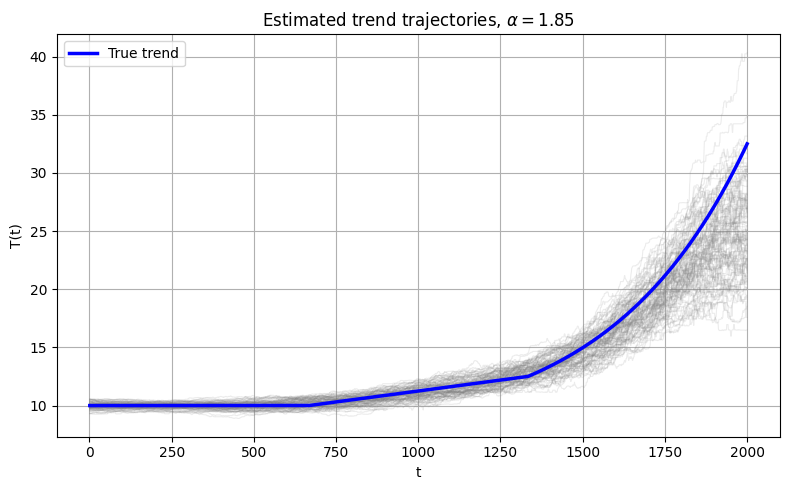

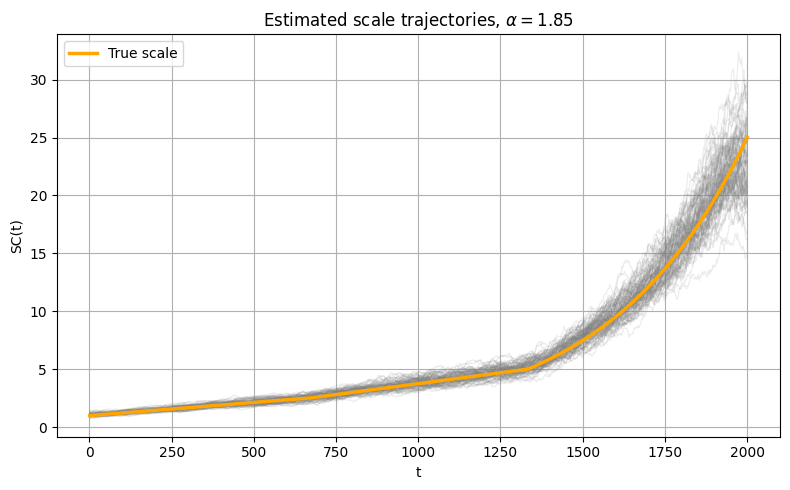

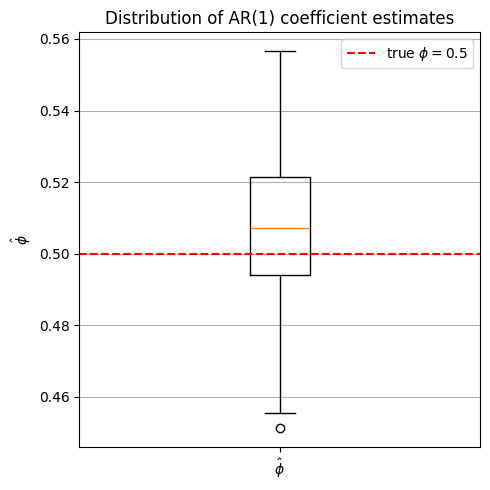

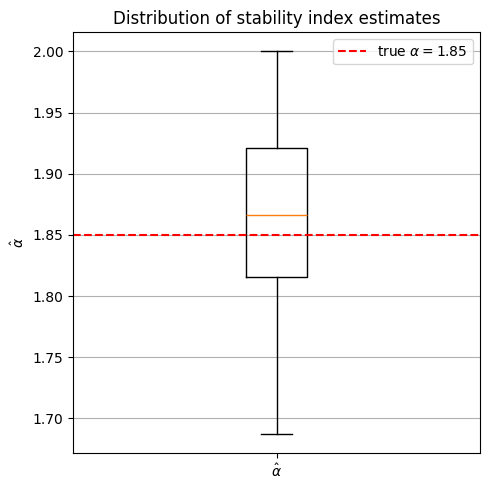

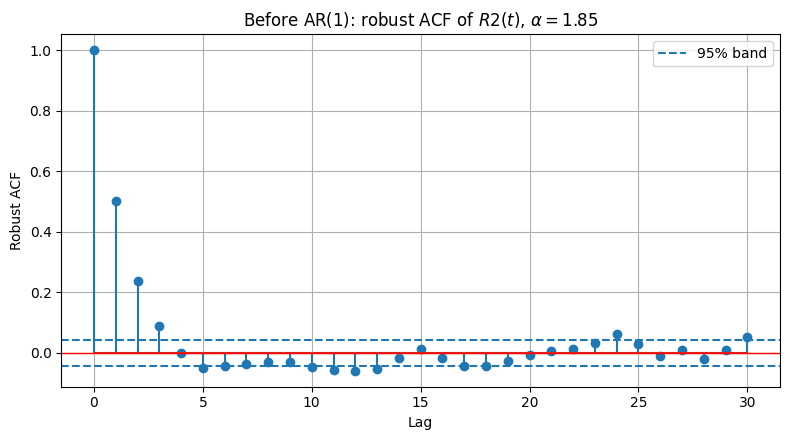

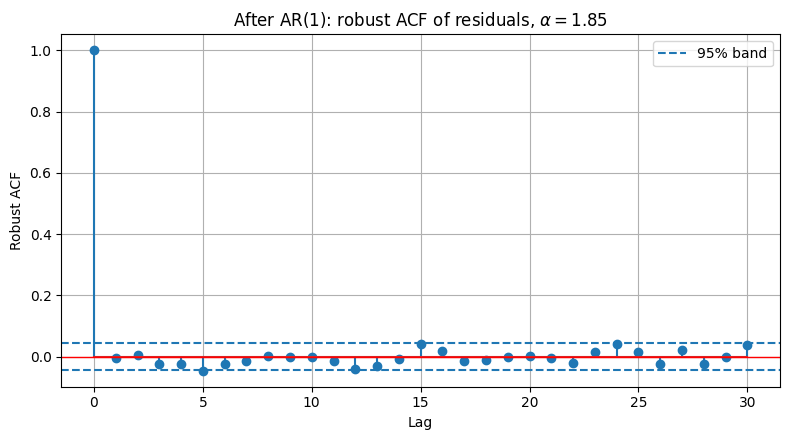

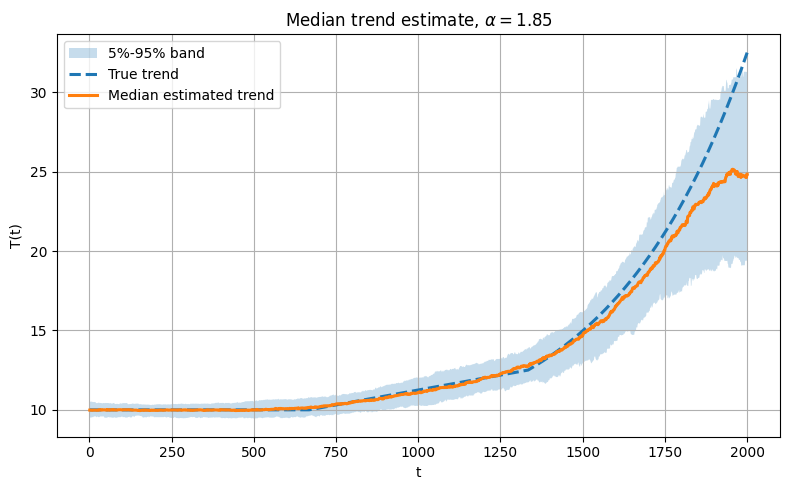

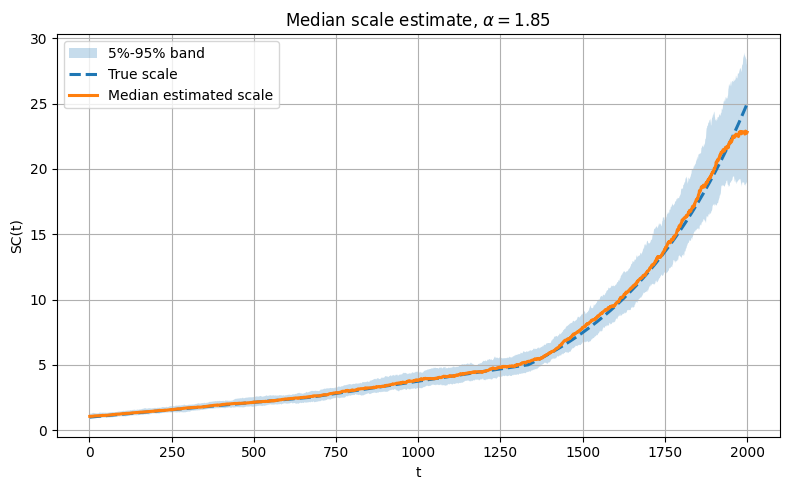

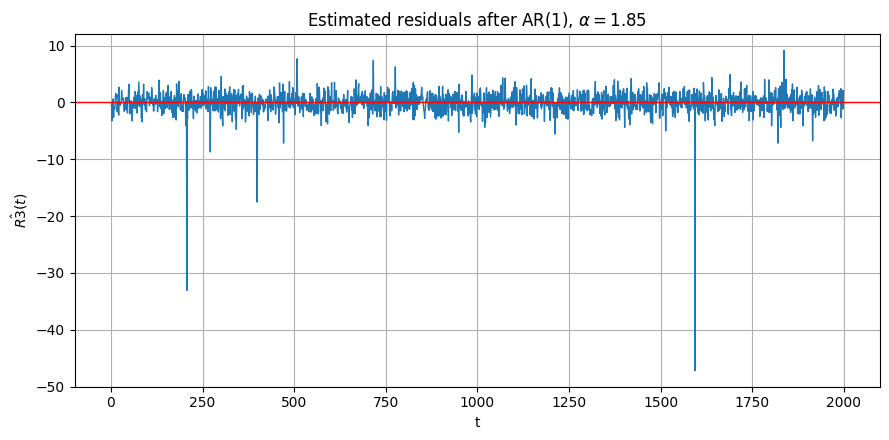

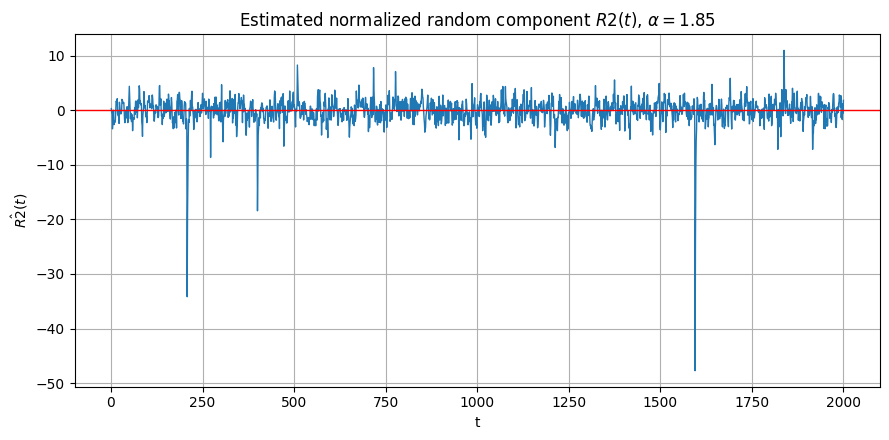

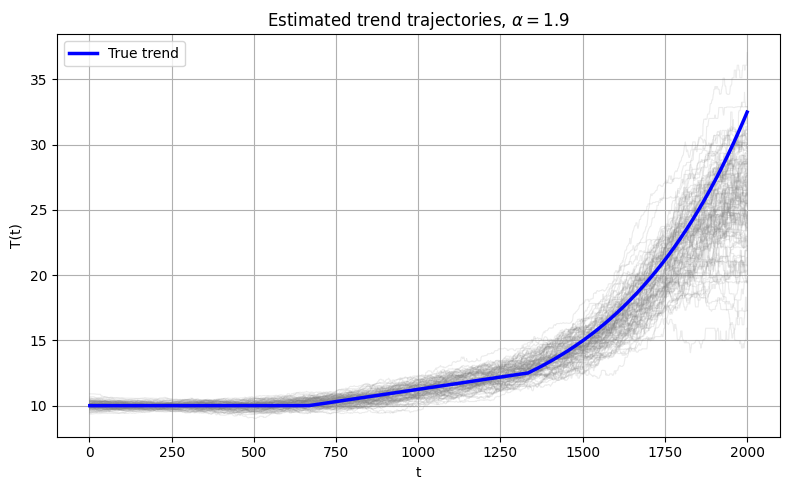

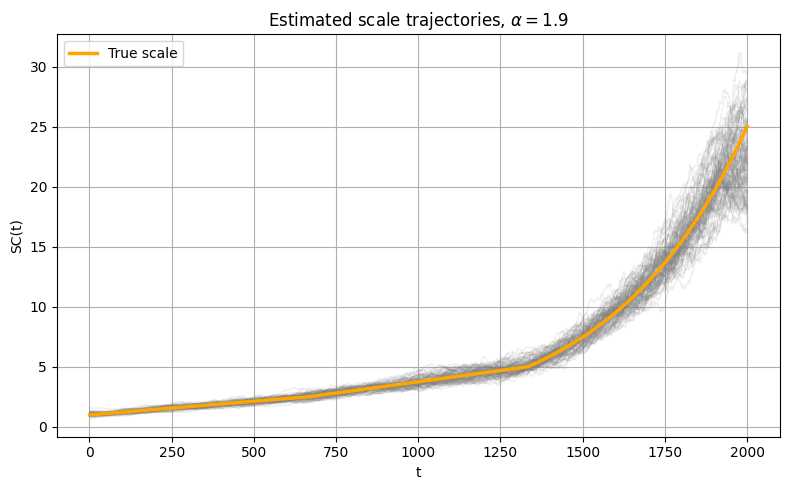

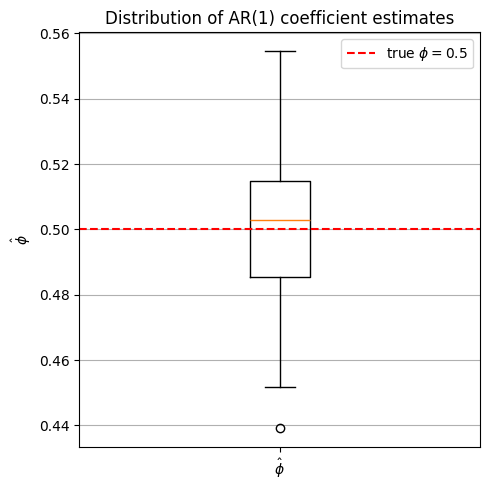

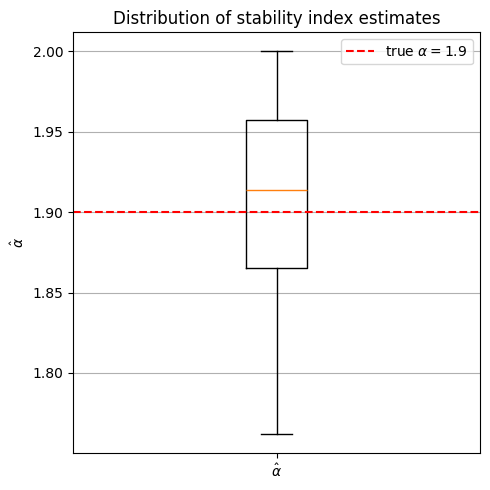

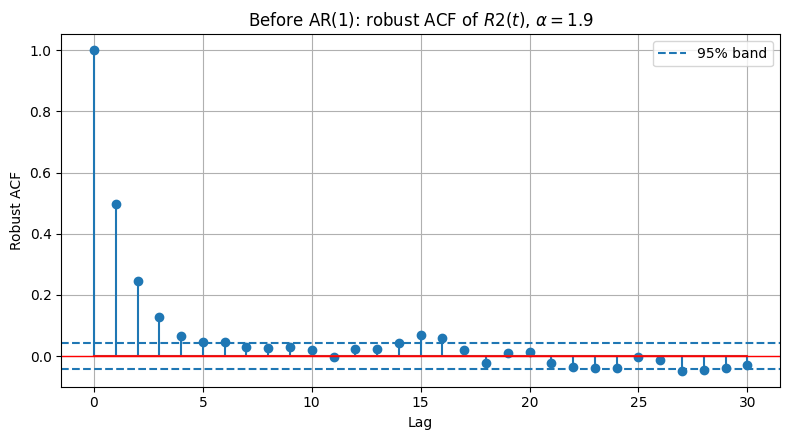

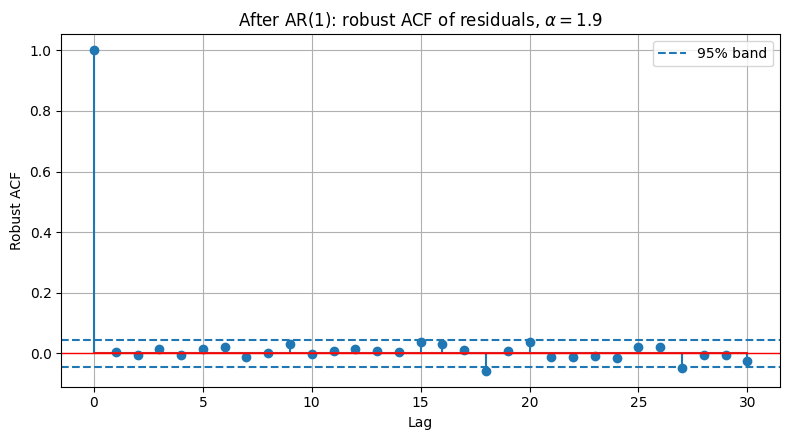

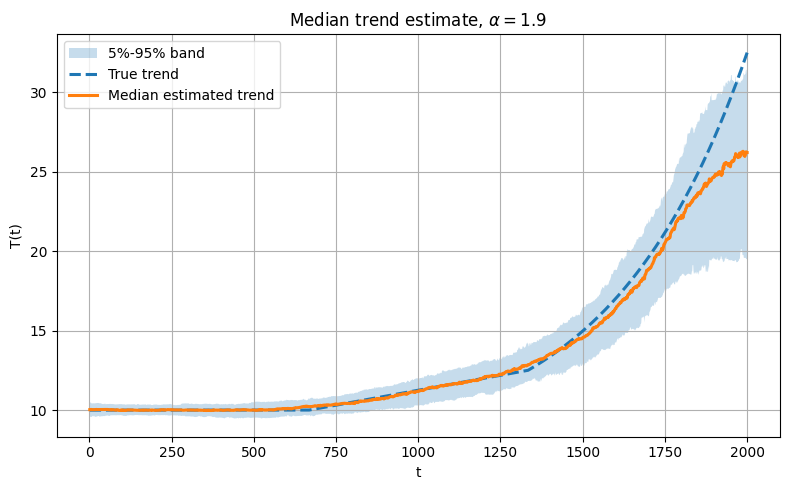

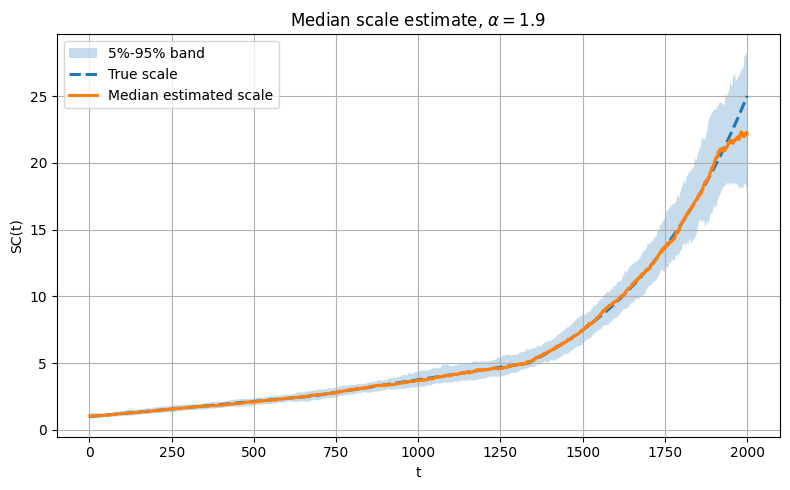

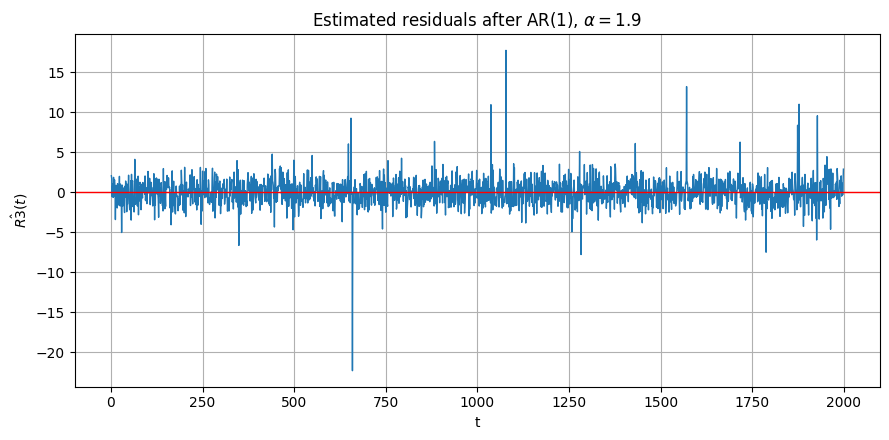

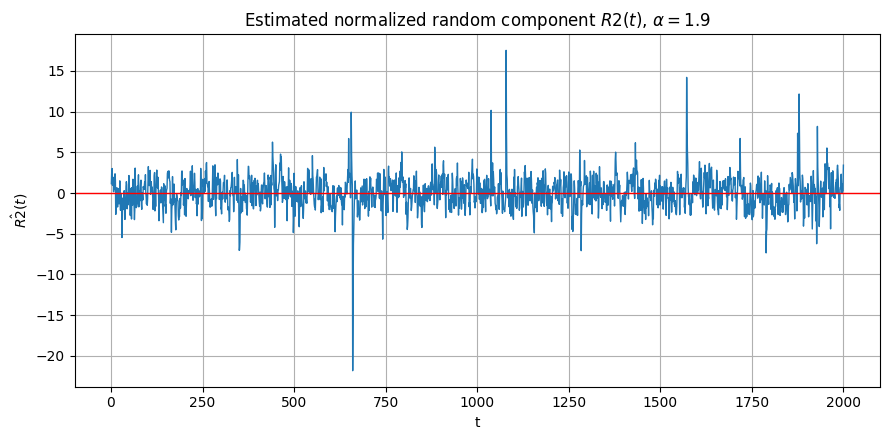

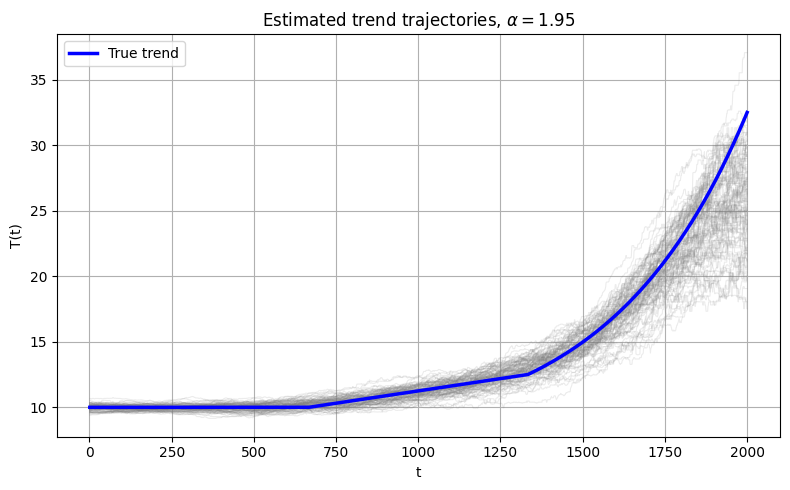

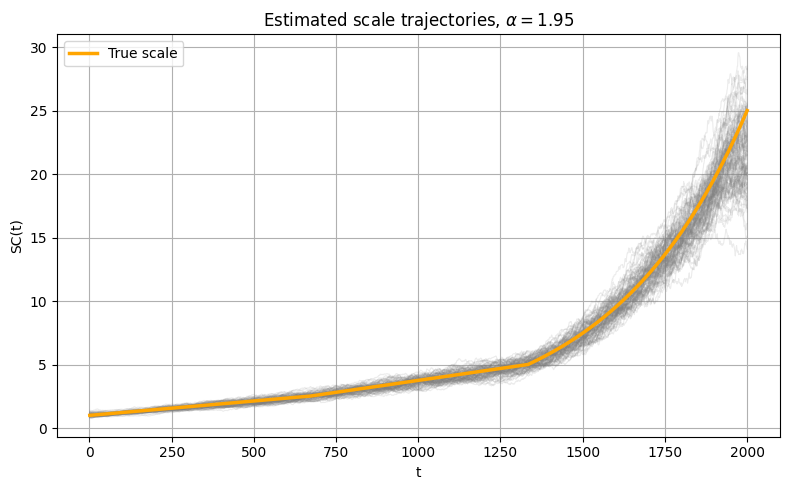

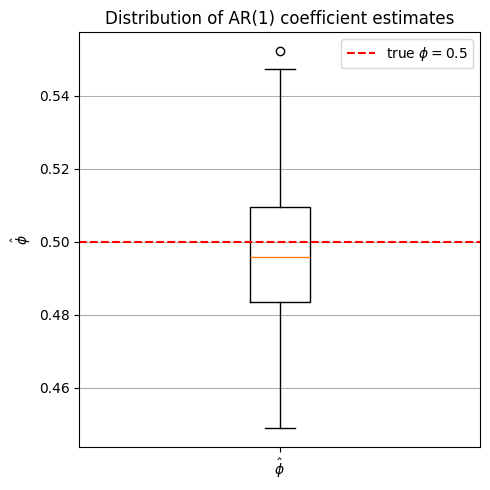

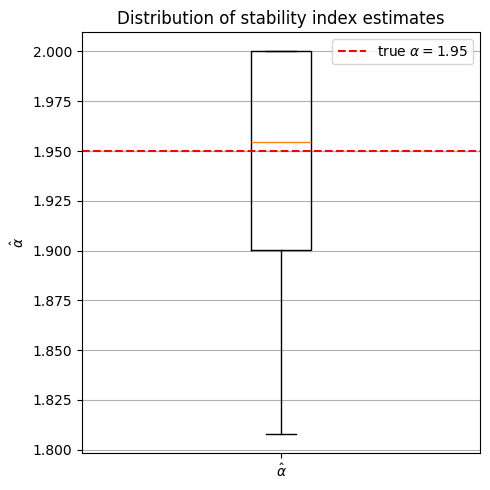

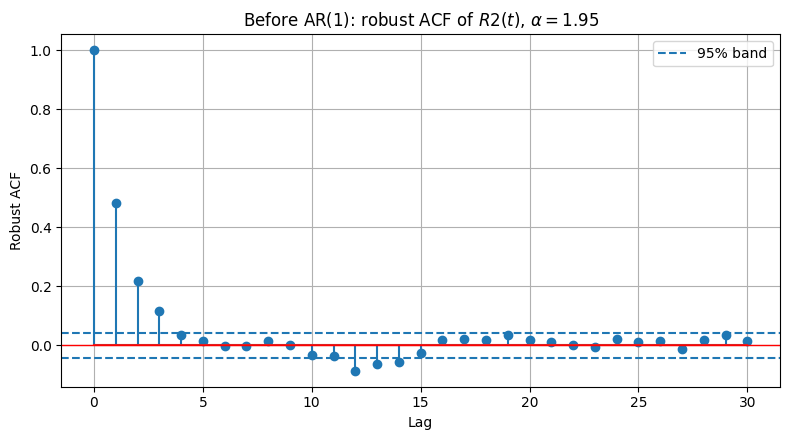

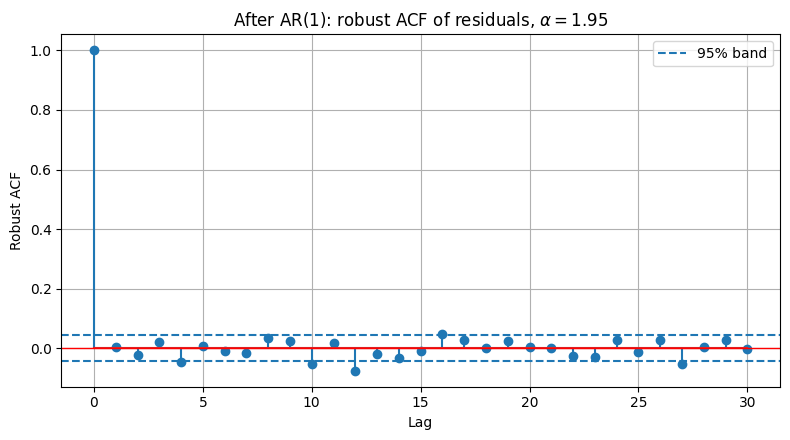

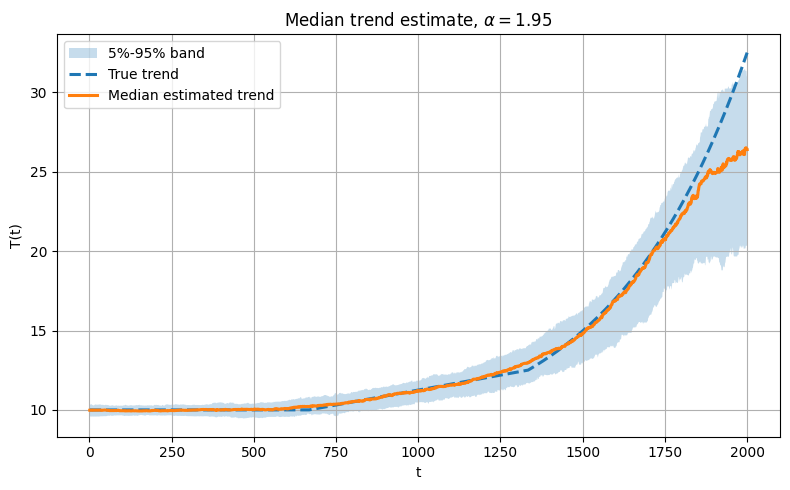

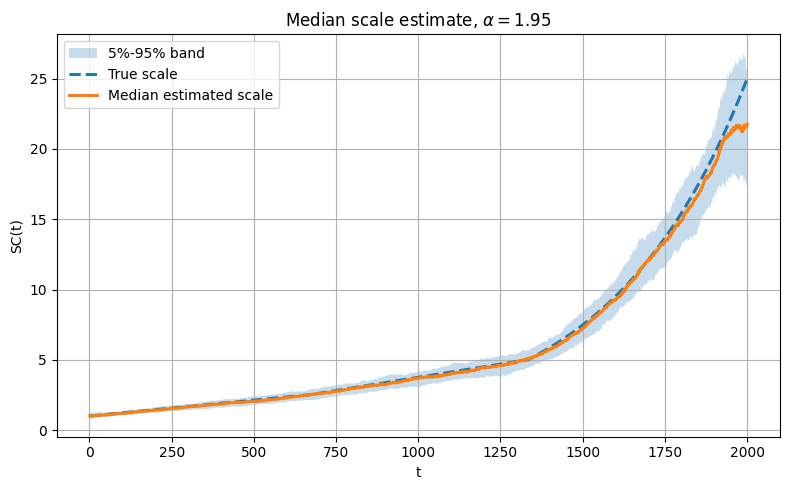

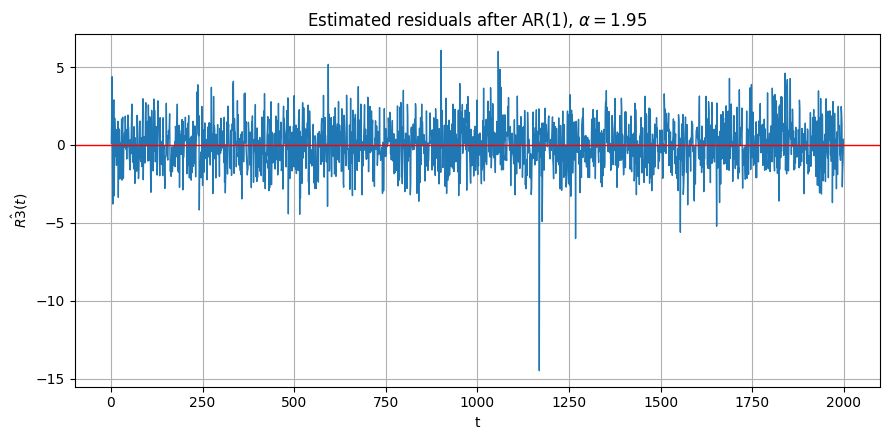

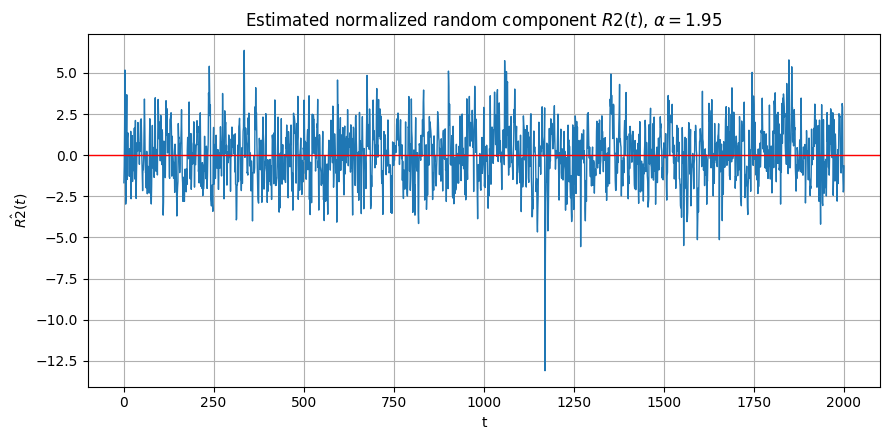

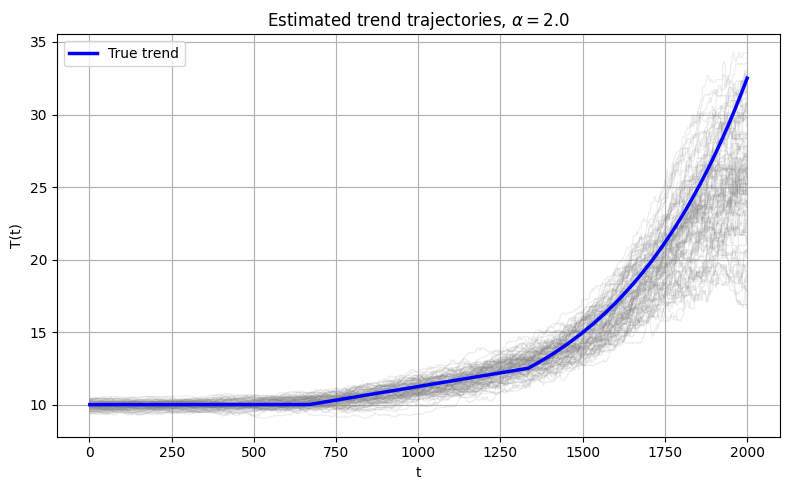

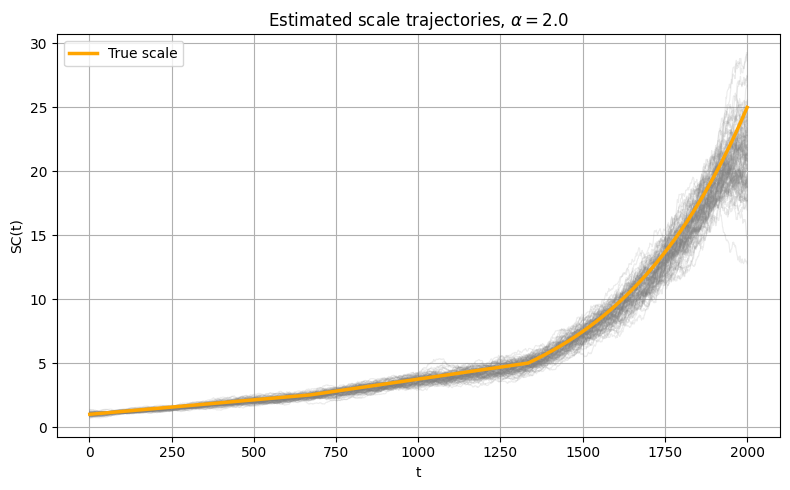

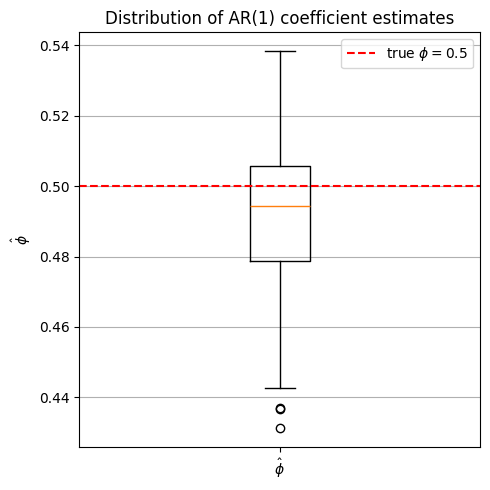

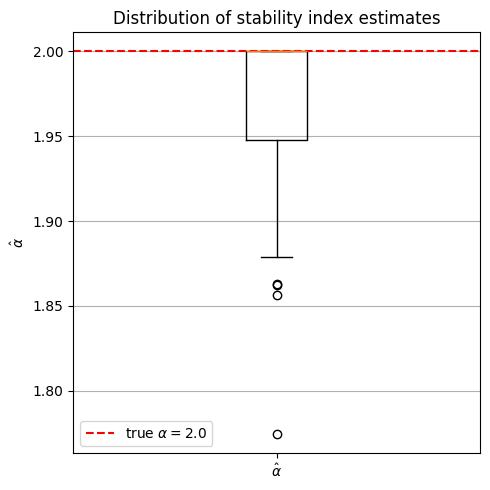

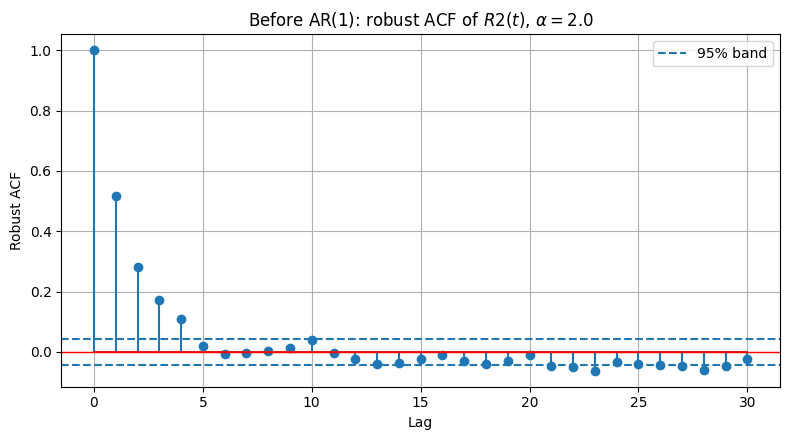

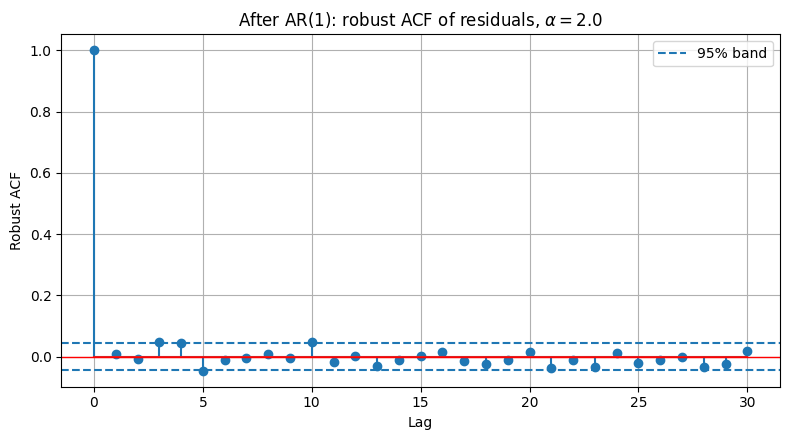

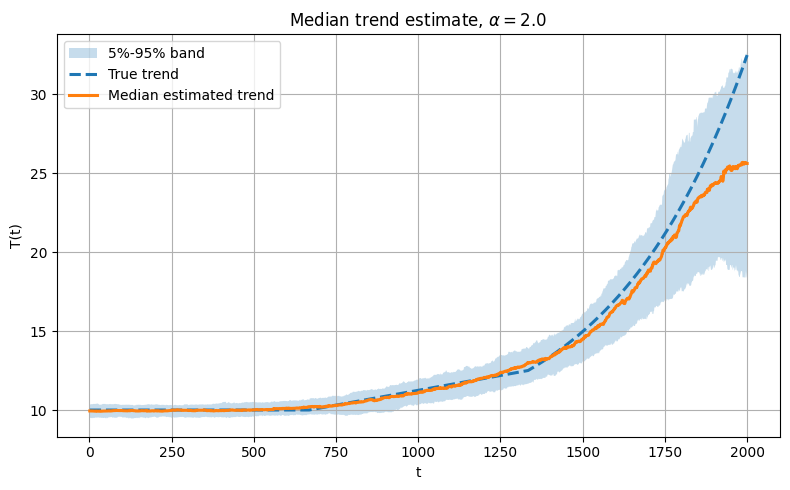

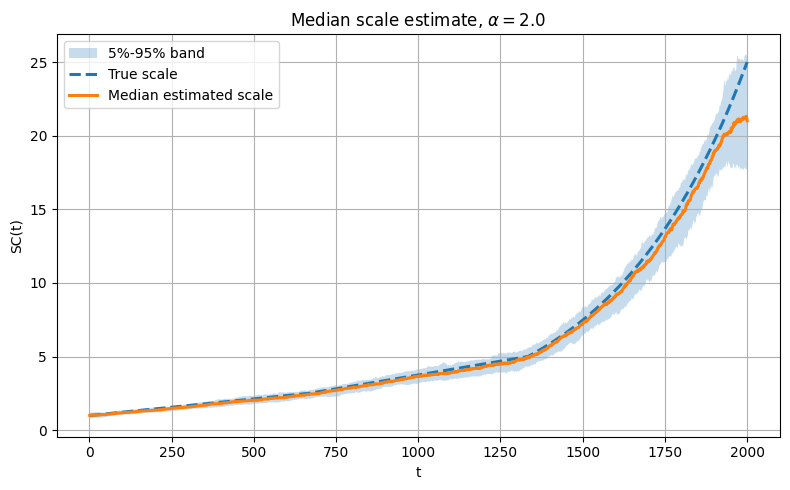

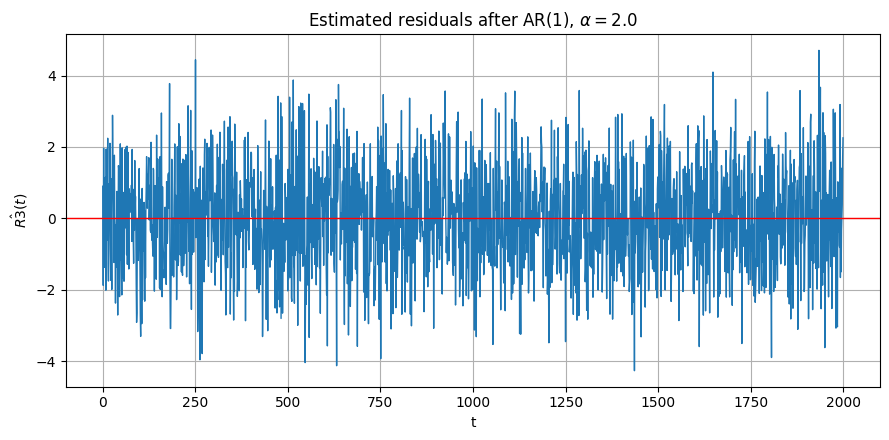

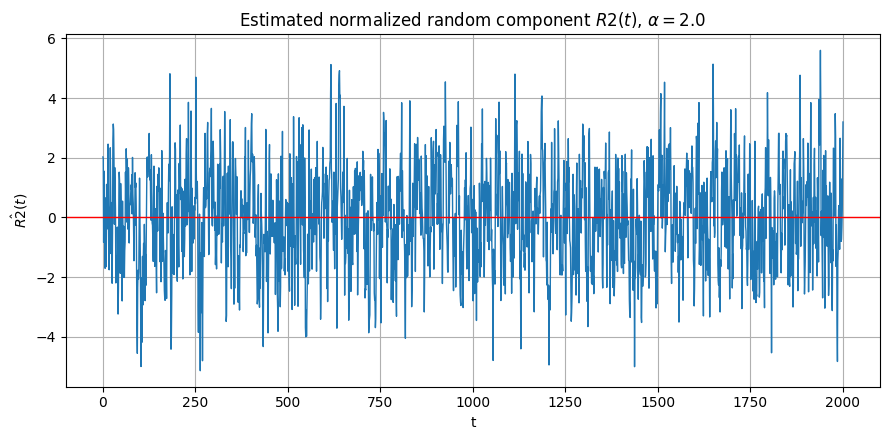

In [20]:
for alpha in [1.85, 1.90, 1.95, 2.00]:
    res = mc_1d_final[alpha]

    plot_1d_trend_trajectories(res)
    plot_1d_scale_trajectories(res)
    plot_1d_phi_boxplot(res)
    plot_1d_alpha_boxplot(res)

    plot_1d_acf_before(res)
    plot_1d_acf_after(res)

    plot_1d_median_trend(res)
    plot_1d_median_scale(res)

    plot_1d_residuals_after_ar(res)
    plot_1d_normalized_component(res)

# UWAGA - dodatek

# uwaga uwaga uwaga uwaga

TESTY KTORE UDOWADNIAJA WINE TREND_WINDOW NA BOXPLOTY (NAJPIERW TESTY SCALE_WINDOW POTEM TREND)

In [72]:
def run_phi_window_test(
    alpha=2.0,
    scale_windows=(51, 101, 151, 201, 251, 301),
    trend_window=101,
    n_replications=30,
):
    rows = []

    for scale_window in scale_windows:
        phi_hats = []
        alpha_hats = []

        for rep in range(n_replications):
            sim_rep = simulate_1d_model(
                **base_params,
                alpha=alpha,
                random_state=120_000 + int(alpha * 1000) + 1000 * scale_window + rep,
            )

            est_rep = estimate_1d_model_fixed_ar_order(
                sim_rep["S"],
                trend_window=trend_window,
                scale_window=scale_window,
                ar_order=1,
                h_max=30,
                compute_diagnostics=False,
            )

            phi_hats.append(est_rep["phi_hat"][0])
            alpha_hats.append(est_rep["alpha_hat"])

        rows.append({
            "alpha": alpha,
            "trend_window": trend_window,
            "scale_window": scale_window,
            "mean_phi_hat": np.mean(phi_hats),
            "median_phi_hat": np.median(phi_hats),
            "std_phi_hat": np.std(phi_hats, ddof=1),
            "mean_alpha_hat": np.mean(alpha_hats),
            "median_alpha_hat": np.median(alpha_hats),
        })

    return pd.DataFrame(rows)

In [73]:
phi_window_test_alpha2 = run_phi_window_test(
    alpha=2.0,
    scale_windows=(51, 101, 151, 201, 251, 301),
    trend_window=101,
    n_replications=30,
)

phi_window_test_alpha2

,alpha,trend_window,scale_window,mean_phi_hat,median_phi_hat,std_phi_hat,mean_alpha_hat,median_alpha_hat
0,2.0,101,51,0.476494,0.475669,0.017945,1.975861,2.000000
1,2.0,101,101,0.483028,0.485901,0.020690,1.942749,1.944591
2,2.0,101,151,0.481079,0.480691,0.022314,1.978426,2.000000
3,2.0,101,201,0.479807,0.481220,0.022569,1.978877,2.000000
4,2.0,101,251,0.476892,0.477945,0.022245,1.961929,1.997753
5,2.0,101,301,0.474152,0.472713,0.025256,1.961077,1.995154


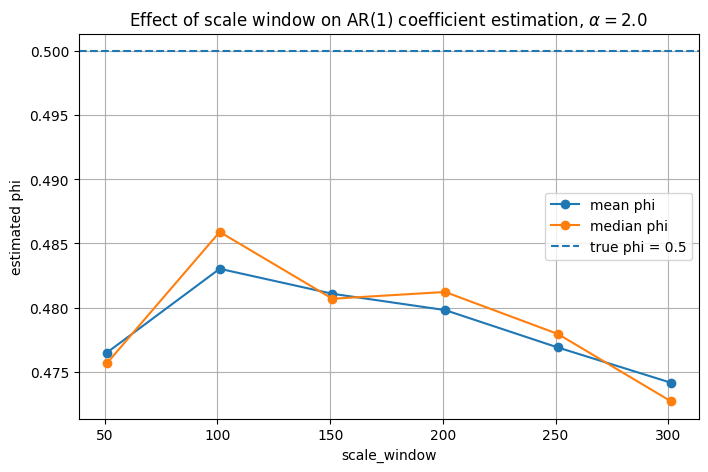

In [74]:
plt.figure(figsize=(8, 5))
plt.plot(phi_window_test_alpha2["scale_window"], phi_window_test_alpha2["mean_phi_hat"], marker="o", label="mean phi")
plt.plot(phi_window_test_alpha2["scale_window"], phi_window_test_alpha2["median_phi_hat"], marker="o", label="median phi")
plt.axhline(0.5, linestyle="--", label="true phi = 0.5")
plt.xlabel("scale_window")
plt.ylabel("estimated phi")
plt.title(r"Effect of scale window on AR(1) coefficient estimation, $\alpha=2.0$")
plt.grid(True)
plt.legend()
plt.show()

In [75]:
phi_window_test_alpha19 = run_phi_window_test(
    alpha=1.9,
    scale_windows=(51, 101, 151, 201, 251, 301),
    trend_window=101,
    n_replications=30,
)

phi_window_test_alpha19

,alpha,trend_window,scale_window,mean_phi_hat,median_phi_hat,std_phi_hat,mean_alpha_hat,median_alpha_hat
0,1.9,101,51,0.484673,0.485954,0.026067,1.887961,1.886544
1,1.9,101,101,0.491553,0.487513,0.020793,1.894771,1.876971
2,1.9,101,151,0.489849,0.486430,0.023520,1.913957,1.916210
3,1.9,101,201,0.485253,0.486333,0.024630,1.895267,1.915579
4,1.9,101,251,0.489405,0.486145,0.024653,1.888176,1.901771
5,1.9,101,301,0.487088,0.491884,0.024879,1.865309,1.845367


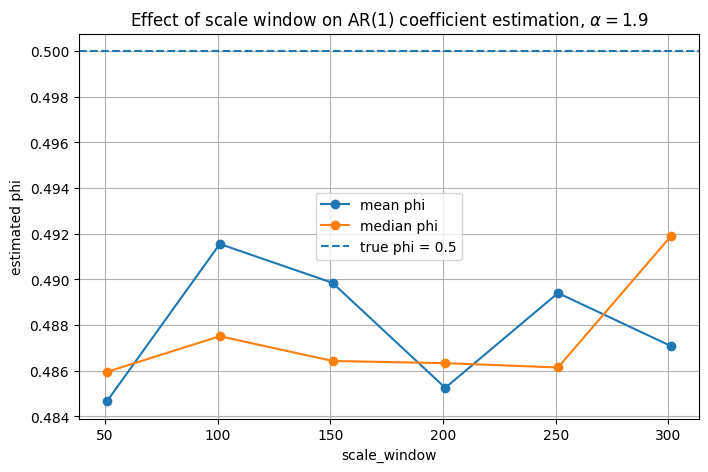

In [76]:
plt.figure(figsize=(8, 5))
plt.plot(phi_window_test_alpha19["scale_window"], phi_window_test_alpha19["mean_phi_hat"], marker="o", label="mean phi")
plt.plot(phi_window_test_alpha19["scale_window"], phi_window_test_alpha19["median_phi_hat"], marker="o", label="median phi")
plt.axhline(0.5, linestyle="--", label="true phi = 0.5")
plt.xlabel("scale_window")
plt.ylabel("estimated phi")
plt.title(r"Effect of scale window on AR(1) coefficient estimation, $\alpha=1.9$")
plt.grid(True)
plt.legend()
plt.show()

In [77]:
from estimation1d import (
    remove_trend,
    rolling_scq_scale,
    normalize_random_component,
    estimate_ar_yule_walker_robust,
)

def estimate_phi_from_series_R2(R2):
    phi_hat, intercept_hat, info = estimate_ar_yule_walker_robust(R2, p=1)
    return phi_hat[0]


def run_phi_source_diagnostic(
    alpha=2.0,
    trend_window=101,
    scale_window=151,
    n_replications=50,
):
    rows = []

    for rep in range(n_replications):
        sim_rep = simulate_1d_model(
            **base_params,
            alpha=alpha,
            random_state=150_000 + int(alpha * 1000) + rep,
        )

        S = sim_rep["S"]
        T_true = sim_rep["T"]
        SC_true = sim_rep["SC"]
        R_true = sim_rep["R"]
        R2_true = sim_rep["R2"]

        # 1. Oracle: true R2
        phi_oracle_R2 = estimate_phi_from_series_R2(R2_true)

        # 2. True trend + true scale
        R_from_true_T = S - T_true
        R2_true_T_true_SC = R_from_true_T / SC_true
        phi_true_T_true_SC = estimate_phi_from_series_R2(R2_true_T_true_SC)

        # 3. Estimated trend + true scale
        R_hat, T_hat = remove_trend(S, trend_window=trend_window)
        R2_est_T_true_SC = R_hat / SC_true
        phi_est_T_true_SC = estimate_phi_from_series_R2(R2_est_T_true_SC)

        # 4. True trend + estimated scale
        SC_hat_from_true_R = rolling_scq_scale(R_true, window=scale_window)
        R2_true_T_est_SC = R_true / SC_hat_from_true_R
        phi_true_T_est_SC = estimate_phi_from_series_R2(R2_true_T_est_SC)

        # 5. Full pipeline
        SC_hat_from_R_hat = rolling_scq_scale(R_hat, window=scale_window)
        R2_full = R_hat / SC_hat_from_R_hat
        phi_full = estimate_phi_from_series_R2(R2_full)

        rows.extend([
            {
                "alpha": alpha,
                "replication": rep,
                "variant": "oracle_true_R2",
                "phi_hat": phi_oracle_R2,
            },
            {
                "alpha": alpha,
                "replication": rep,
                "variant": "true_trend_true_scale",
                "phi_hat": phi_true_T_true_SC,
            },
            {
                "alpha": alpha,
                "replication": rep,
                "variant": "estimated_trend_true_scale",
                "phi_hat": phi_est_T_true_SC,
            },
            {
                "alpha": alpha,
                "replication": rep,
                "variant": "true_trend_estimated_scale",
                "phi_hat": phi_true_T_est_SC,
            },
            {
                "alpha": alpha,
                "replication": rep,
                "variant": "full_pipeline",
                "phi_hat": phi_full,
            },
        ])

    return pd.DataFrame(rows)

In [78]:
phi_source_alpha2 = run_phi_source_diagnostic(
    alpha=2.0,
    trend_window=101,
    scale_window=151,
    n_replications=50,
)

phi_source_summary_alpha2 = (
    phi_source_alpha2
    .groupby("variant")
    .agg(
        mean_phi_hat=("phi_hat", "mean"),
        median_phi_hat=("phi_hat", "median"),
        std_phi_hat=("phi_hat", "std"),
    )
    .reset_index()
)

phi_source_summary_alpha2

,variant,mean_phi_hat,median_phi_hat,std_phi_hat
0,estimated_trend_true_scale,0.485743,0.485840,0.019577
1,full_pipeline,0.482897,0.482109,0.019344
2,oracle_true_R2,0.501829,0.503141,0.019641
3,true_trend_estimated_scale,0.499251,0.500974,0.019394
4,true_trend_true_scale,0.501829,0.503141,0.019641


<Figure size 1100x500 with 0 Axes>

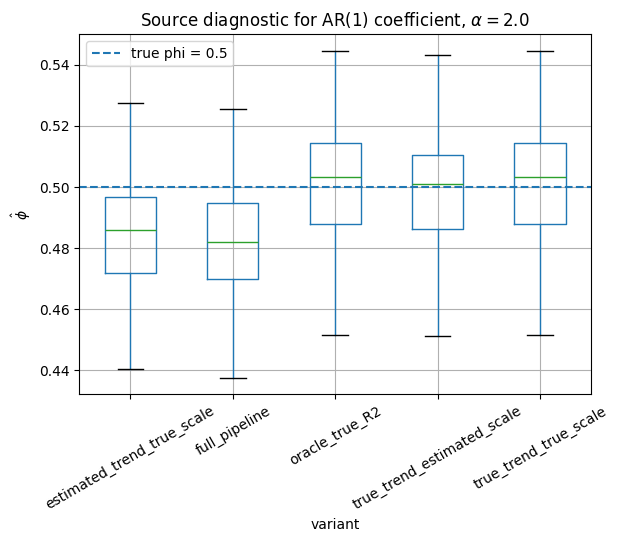

In [79]:
plt.figure(figsize=(11, 5))
phi_source_alpha2.boxplot(column="phi_hat", by="variant", rot=30)
plt.axhline(0.5, linestyle="--", label="true phi = 0.5")
plt.title(r"Source diagnostic for AR(1) coefficient, $\alpha=2.0$")
plt.suptitle("")
plt.ylabel(r"$\hat{\phi}$")
plt.grid(True)
plt.legend()
plt.show()

In [80]:
phi_source_alpha19 = run_phi_source_diagnostic(
    alpha=1.9,
    trend_window=101,
    scale_window=151,
    n_replications=50,
)

phi_source_summary_alpha19 = (
    phi_source_alpha19
    .groupby("variant")
    .agg(
        mean_phi_hat=("phi_hat", "mean"),
        median_phi_hat=("phi_hat", "median"),
        std_phi_hat=("phi_hat", "std"),
    )
    .reset_index()
)

phi_source_summary_alpha19

,variant,mean_phi_hat,median_phi_hat,std_phi_hat
0,estimated_trend_true_scale,0.490616,0.491197,0.019643
1,full_pipeline,0.488100,0.487872,0.019548
2,oracle_true_R2,0.508170,0.506515,0.018669
3,true_trend_estimated_scale,0.505906,0.504594,0.018905
4,true_trend_true_scale,0.508170,0.506515,0.018669


In [81]:
def run_phi_trend_window_test(
    alpha=2.0,
    trend_windows=(51, 101, 151, 201, 251, 301, 401, 501),
    scale_window=101,
    n_replications=30,
):
    rows = []

    for trend_window in trend_windows:
        phi_hats = []
        alpha_hats = []

        for rep in range(n_replications):
            sim_rep = simulate_1d_model(
                **base_params,
                alpha=alpha,
                random_state=220_000 + int(alpha * 1000) + 1000 * trend_window + rep,
            )

            est_rep = estimate_1d_model_fixed_ar_order(
                sim_rep["S"],
                trend_window=trend_window,
                scale_window=scale_window,
                ar_order=1,
                h_max=30,
                compute_diagnostics=False,
            )

            phi_hats.append(est_rep["phi_hat"][0])
            alpha_hats.append(est_rep["alpha_hat"])

        rows.append({
            "alpha": alpha,
            "trend_window": trend_window,
            "scale_window": scale_window,
            "mean_phi_hat": np.mean(phi_hats),
            "median_phi_hat": np.median(phi_hats),
            "std_phi_hat": np.std(phi_hats, ddof=1),
            "mean_alpha_hat": np.mean(alpha_hats),
            "median_alpha_hat": np.median(alpha_hats),
        })

    return pd.DataFrame(rows)

In [82]:
phi_trend_test_alpha2 = run_phi_trend_window_test(
    alpha=2.0,
    trend_windows=(51, 101, 151, 201, 251, 301, 401, 501),
    scale_window=101,
    n_replications=30,
)

phi_trend_test_alpha2

,alpha,trend_window,scale_window,mean_phi_hat,median_phi_hat,std_phi_hat,mean_alpha_hat,median_alpha_hat
0,2.0,51,101,0.457743,0.458779,0.023545,1.970719,2.000000
1,2.0,101,101,0.477864,0.478446,0.022410,1.984815,2.000000
2,2.0,151,101,0.480587,0.480962,0.021220,1.956826,1.982192
3,2.0,201,101,0.482418,0.482586,0.023295,1.970258,2.000000
4,2.0,251,101,0.489004,0.485886,0.019332,1.970597,2.000000
5,2.0,301,101,0.489713,0.488638,0.019511,1.956774,1.988756
6,2.0,401,101,0.492491,0.494807,0.015736,1.973167,2.000000
7,2.0,501,101,0.493018,0.495109,0.016690,1.968548,2.000000


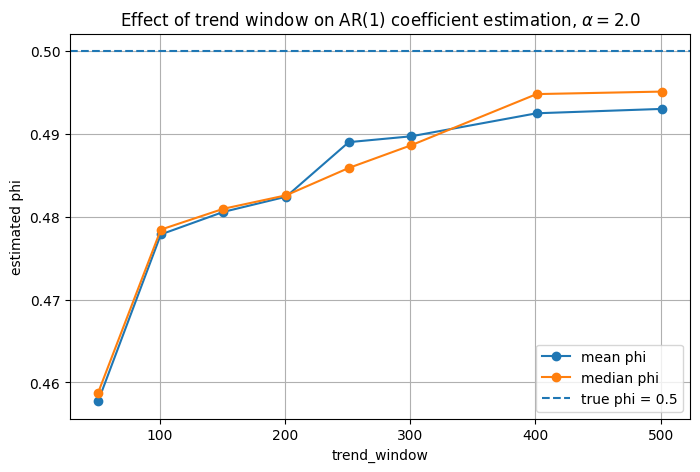

In [83]:
plt.figure(figsize=(8, 5))
plt.plot(phi_trend_test_alpha2["trend_window"], phi_trend_test_alpha2["mean_phi_hat"], marker="o", label="mean phi")
plt.plot(phi_trend_test_alpha2["trend_window"], phi_trend_test_alpha2["median_phi_hat"], marker="o", label="median phi")
plt.axhline(0.5, linestyle="--", label="true phi = 0.5")
plt.xlabel("trend_window")
plt.ylabel("estimated phi")
plt.title(r"Effect of trend window on AR(1) coefficient estimation, $\alpha=2.0$")
plt.grid(True)
plt.legend()
plt.show()

In [84]:
phi_trend_test_alpha19 = run_phi_trend_window_test(
    alpha=1.9,
    trend_windows=(51, 101, 151, 201, 251, 301, 401, 501),
    scale_window=101,
    n_replications=30,
)

phi_trend_test_alpha19

,alpha,trend_window,scale_window,mean_phi_hat,median_phi_hat,std_phi_hat,mean_alpha_hat,median_alpha_hat
0,1.9,51,101,0.465934,0.464786,0.023424,1.914356,1.914509
1,1.9,101,101,0.482252,0.482418,0.024887,1.896398,1.895125
2,1.9,151,101,0.493342,0.492902,0.026096,1.901223,1.909018
3,1.9,201,101,0.493268,0.495600,0.023074,1.884492,1.879803
4,1.9,251,101,0.496301,0.498036,0.018286,1.920641,1.925162
5,1.9,301,101,0.497858,0.499473,0.016578,1.887447,1.877593
6,1.9,401,101,0.505511,0.511491,0.024926,1.901395,1.904967
7,1.9,501,101,0.500805,0.501015,0.016067,1.881349,1.885388


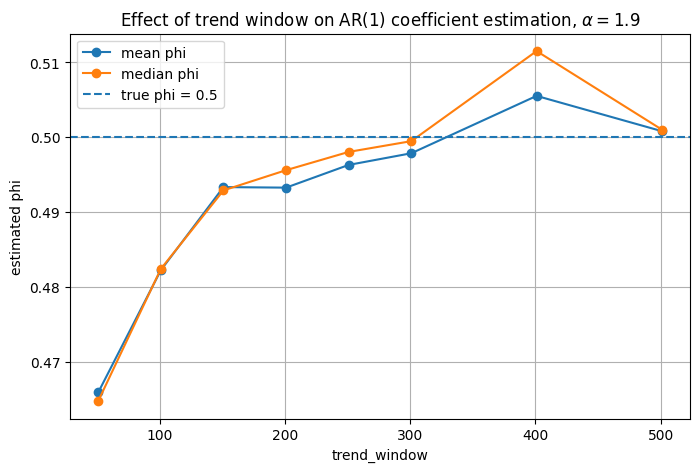

In [85]:
plt.figure(figsize=(8, 5))
plt.plot(phi_trend_test_alpha19["trend_window"], phi_trend_test_alpha19["mean_phi_hat"], marker="o", label="mean phi")
plt.plot(phi_trend_test_alpha19["trend_window"], phi_trend_test_alpha19["median_phi_hat"], marker="o", label="median phi")
plt.axhline(0.5, linestyle="--", label="true phi = 0.5")
plt.xlabel("trend_window")
plt.ylabel("estimated phi")
plt.title(r"Effect of trend window on AR(1) coefficient estimation, $\alpha=1.9$")
plt.grid(True)
plt.legend()
plt.show()

definitywnie wybieramy trend 501 a teraz jeszcze ktory scale

In [86]:
scale_after_trend501_alpha2 = run_phi_window_test(
    alpha=2.0,
    scale_windows=(101, 151, 201),
    trend_window=501,
    n_replications=30,
)

scale_after_trend501_alpha2

,alpha,trend_window,scale_window,mean_phi_hat,median_phi_hat,std_phi_hat,mean_alpha_hat,median_alpha_hat
0,2.0,501,101,0.494709,0.492403,0.019500,1.941363,1.954259
1,2.0,501,151,0.495054,0.494680,0.022843,1.973216,1.999878
2,2.0,501,201,0.496349,0.494298,0.021216,1.984068,2.000000


In [87]:
scale_after_trend501_alpha19 = run_phi_window_test(
    alpha=1.9,
    scale_windows=(101, 151, 201),
    trend_window=501,
    n_replications=30,
)

scale_after_trend501_alpha19

,alpha,trend_window,scale_window,mean_phi_hat,median_phi_hat,std_phi_hat,mean_alpha_hat,median_alpha_hat
0,1.9,501,101,0.505508,0.502156,0.020486,1.901312,1.915452
1,1.9,501,151,0.503268,0.503607,0.022068,1.920780,1.927823
2,1.9,501,201,0.498449,0.496122,0.025169,1.908795,1.920994


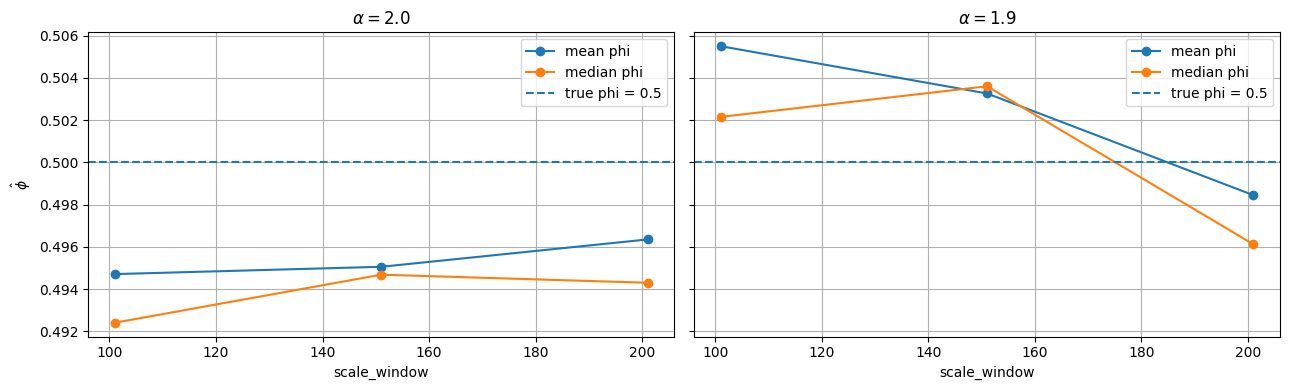

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

axes[0].plot(scale_after_trend501_alpha2["scale_window"],
             scale_after_trend501_alpha2["mean_phi_hat"],
             marker="o", label="mean phi")
axes[0].plot(scale_after_trend501_alpha2["scale_window"],
             scale_after_trend501_alpha2["median_phi_hat"],
             marker="o", label="median phi")
axes[0].axhline(0.5, linestyle="--", label="true phi = 0.5")
axes[0].set_title(r"$\alpha=2.0$")
axes[0].set_xlabel("scale_window")
axes[0].set_ylabel(r"$\hat{\phi}$")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(scale_after_trend501_alpha19["scale_window"],
             scale_after_trend501_alpha19["mean_phi_hat"],
             marker="o", label="mean phi")
axes[1].plot(scale_after_trend501_alpha19["scale_window"],
             scale_after_trend501_alpha19["median_phi_hat"],
             marker="o", label="median phi")
axes[1].axhline(0.5, linestyle="--", label="true phi = 0.5")
axes[1].set_title(r"$\alpha=1.9$")
axes[1].set_xlabel("scale_window")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# Multidimensional model

In the multidimensional case, the observed signal is a vector

$$
\mathbf{S}(t)=\mathbf{R}(t)+\mathbf{T}(t).
$$

Each component has its own trend and scale function, but the regime change points $\tau_1$ and $\tau_2$ are common to all components. The normalized random component is modelled using a VAR(1) process:

$$
\mathbf{R2}(t)=\Theta \mathbf{R2}(t-1)+\mathbf{R3}(t).
$$

The innovation vector $\mathbf{R3}(t)$ is generated from a sub-Gaussian $S\alpha S$ distribution.

In [150]:
import importlib
import simulation2d

importlib.reload(simulation2d)

from simulation2d import simulate_2d_model

In [151]:
N = 2000
tau1 = N / 3
tau2 = 2 * N / 3

Theta_true = np.array([
    [0.5, 0.2],
    [-0.1, 0.6],
])

Sigma_true = np.array([
    [0.64, 0.32],
    [0.32, 0.64],
])

base_params_2d = dict(
    N=N,
    tau1=tau1,
    tau2=tau2,
    Theta=Theta_true,
    Sigma=Sigma_true,
    sigma_1=np.array([1.0, 0.8]),
    sigma_2=np.array([2.5, 1.5]),
    sigma_3=np.array([5.0, 2.0]),
    sigma_4=np.array([25.0, 10.0]),
    c1=np.array([10.0, -5.0]),
)

In [152]:
sim2d = simulate_2d_model(
    **base_params_2d,
    alpha=1.9,
    random_state=42,
)

sim2d.keys()

dict_keys(['t', 'S', 'R', 'R2', 'R3', 'SC', 'T', 'Theta', 'Sigma', 'scale_params', 'trend_params', 'params'])

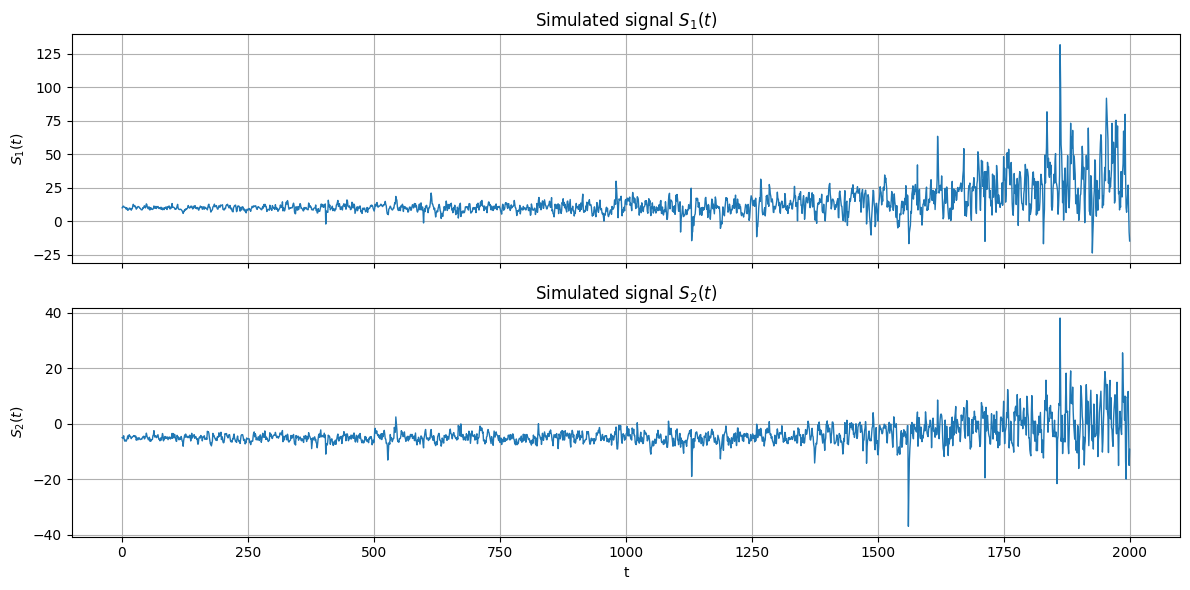

In [153]:
t = sim2d["t"]
S = sim2d["S"]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t, S[:, 0], linewidth=1)
axes[0].set_title(r"Simulated signal $S_1(t)$")
axes[0].set_ylabel(r"$S_1(t)$")
axes[0].grid(True)

axes[1].plot(t, S[:, 1], linewidth=1)
axes[1].set_title(r"Simulated signal $S_2(t)$")
axes[1].set_xlabel("t")
axes[1].set_ylabel(r"$S_2(t)$")
axes[1].grid(True)

plt.tight_layout()
plt.show()

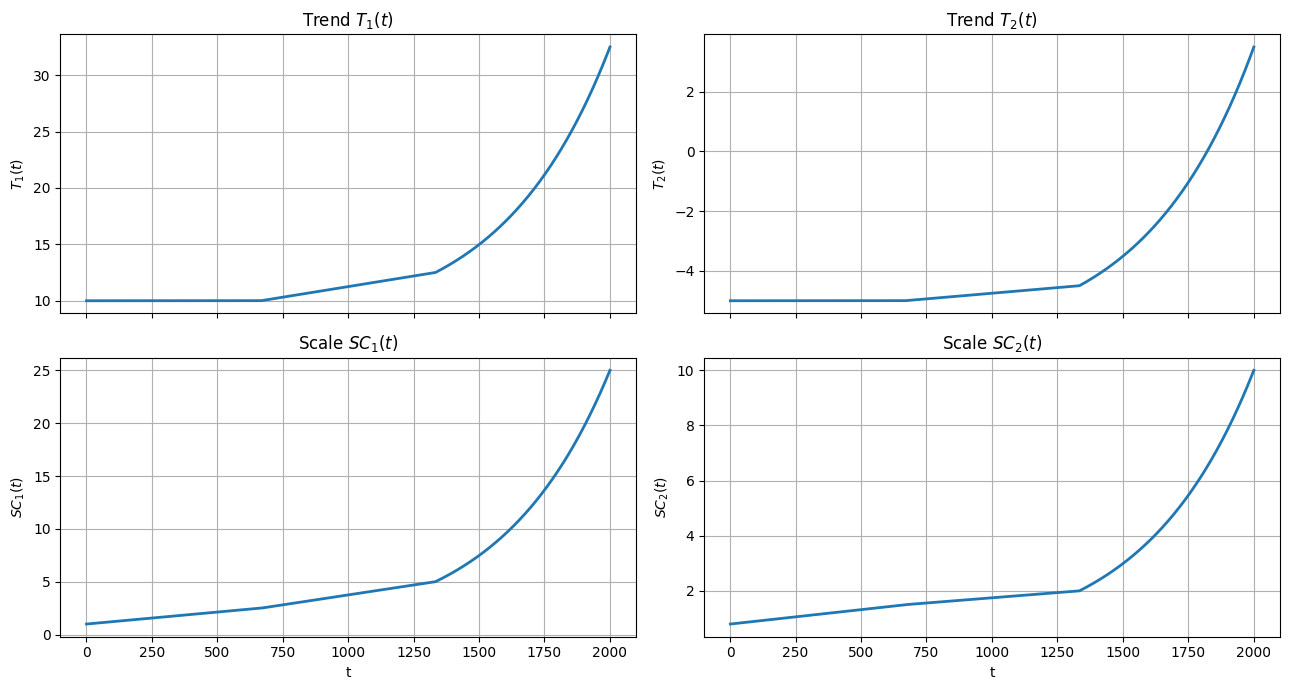

In [154]:
T = sim2d["T"]
SC = sim2d["SC"]

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

axes[0, 0].plot(t, T[:, 0], linewidth=2)
axes[0, 0].set_title(r"Trend $T_1(t)$")
axes[0, 0].set_ylabel(r"$T_1(t)$")
axes[0, 0].grid(True)

axes[0, 1].plot(t, T[:, 1], linewidth=2)
axes[0, 1].set_title(r"Trend $T_2(t)$")
axes[0, 1].set_ylabel(r"$T_2(t)$")
axes[0, 1].grid(True)

axes[1, 0].plot(t, SC[:, 0], linewidth=2)
axes[1, 0].set_title(r"Scale $SC_1(t)$")
axes[1, 0].set_xlabel("t")
axes[1, 0].set_ylabel(r"$SC_1(t)$")
axes[1, 0].grid(True)

axes[1, 1].plot(t, SC[:, 1], linewidth=2)
axes[1, 1].set_title(r"Scale $SC_2(t)$")
axes[1, 1].set_xlabel("t")
axes[1, 1].set_ylabel(r"$SC_2(t)$")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [155]:
print("Theta true:")
print(sim2d["Theta"])

print("\nSigma true:")
print(sim2d["Sigma"])

print("\nFirst rows of S:")
print(sim2d["S"][:5])

Theta true:
[[ 0.5  0.2]
 [-0.1  0.6]]

Sigma true:
[[0.64 0.32]
 [0.32 0.64]]

First rows of S:
[[10.         -5.        ]
 [10.77104386 -5.23213955]
 [11.20653267 -4.93218829]
 [11.20180554 -4.32264953]
 [10.3270969  -5.59754917]]


In [156]:
import importlib
import estimation2d

importlib.reload(estimation2d)

from estimation2d import (
    estimate_2d_model_fixed_var1,
    summarize_2d_estimation,
)

## Estimation for one two-dimensional trajectory

We now apply the two-dimensional estimation pipeline to one simulated trajectory. The procedure follows the same logic as in the one-dimensional case: trend estimation, scale estimation, normalization, VAR(1) fitting, residual calculation and estimation of the stability index.

In [223]:
est2d = estimate_2d_model_fixed_var1(
    sim2d["S"],
    trend_window=501,
    scale_window=151,
    h_max=30,
    compute_diagnostics=True,
    scale_multiplier = 1.6629888237094692
)

summarize_2d_estimation(est2d)

Two-dimensional estimation summary
----------------------------------
Estimated Theta:
[[ 0.49545282  0.19921618]
 [-0.12965311  0.62248887]]

Estimated alpha: 1.8591

Componentwise alpha:
  alpha_1: 1.8422
  alpha_2: 1.8760


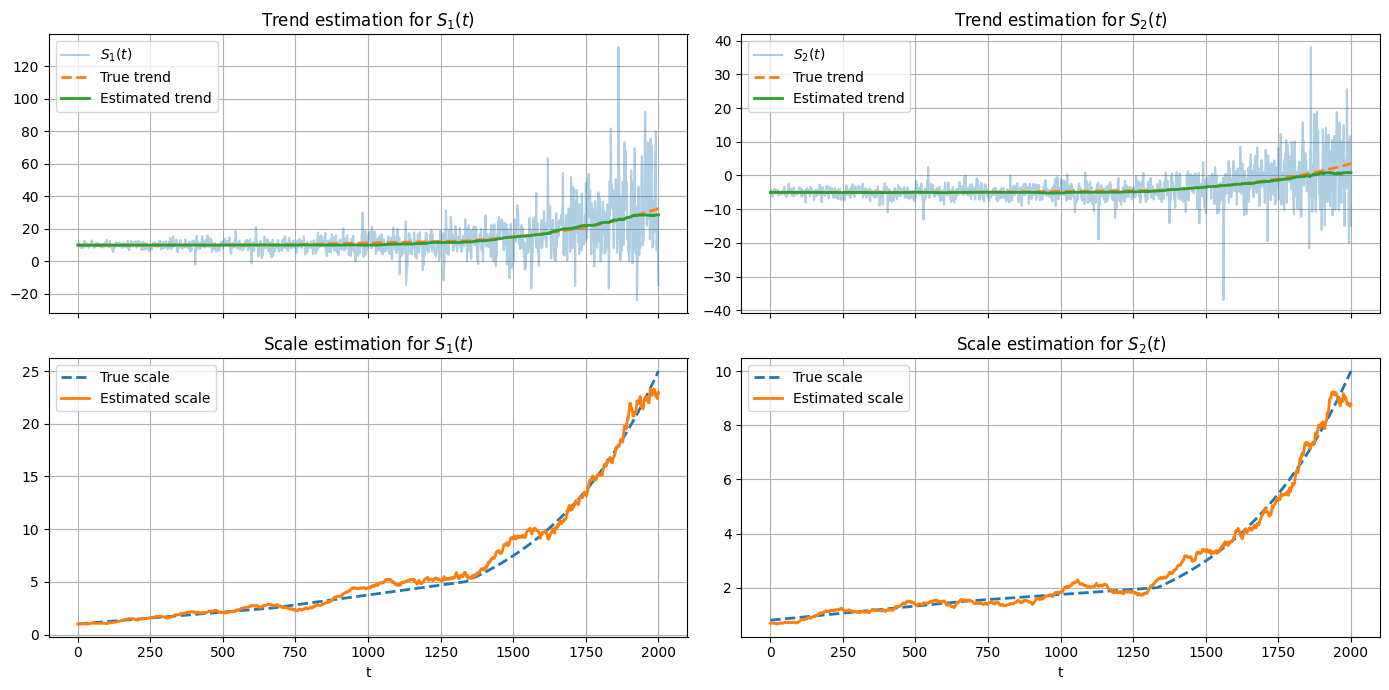

In [224]:
t = sim2d["t"]

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)

axes[0, 0].plot(t, sim2d["S"][:, 0], alpha=0.35, label=r"$S_1(t)$")
axes[0, 0].plot(t, sim2d["T"][:, 0], linestyle="--", linewidth=2, label="True trend")
axes[0, 0].plot(t, est2d["T_hat"][:, 0], linewidth=2, label="Estimated trend")
axes[0, 0].set_title(r"Trend estimation for $S_1(t)$")
axes[0, 0].grid(True)
axes[0, 0].legend()

axes[0, 1].plot(t, sim2d["S"][:, 1], alpha=0.35, label=r"$S_2(t)$")
axes[0, 1].plot(t, sim2d["T"][:, 1], linestyle="--", linewidth=2, label="True trend")
axes[0, 1].plot(t, est2d["T_hat"][:, 1], linewidth=2, label="Estimated trend")
axes[0, 1].set_title(r"Trend estimation for $S_2(t)$")
axes[0, 1].grid(True)
axes[0, 1].legend()

axes[1, 0].plot(t, sim2d["SC"][:, 0], linestyle="--", linewidth=2, label="True scale")
axes[1, 0].plot(t, est2d["SC_hat"][:, 0], linewidth=2, label="Estimated scale")
axes[1, 0].set_title(r"Scale estimation for $S_1(t)$")
axes[1, 0].set_xlabel("t")
axes[1, 0].grid(True)
axes[1, 0].legend()

axes[1, 1].plot(t, sim2d["SC"][:, 1], linestyle="--", linewidth=2, label="True scale")
axes[1, 1].plot(t, est2d["SC_hat"][:, 1], linewidth=2, label="Estimated scale")
axes[1, 1].set_title(r"Scale estimation for $S_2(t)$")
axes[1, 1].set_xlabel("t")
axes[1, 1].grid(True)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [225]:
def plot_2d_acf_ccf_diagnostics(diagnostics, title_prefix=""):
    fig, axes = plt.subplots(2, 2, figsize=(13, 7))

    acf_1 = diagnostics["acf_1"]
    acf_2 = diagnostics["acf_2"]
    ccf_12 = diagnostics["ccf_12"]
    ccf_21 = diagnostics["ccf_21"]

    axes[0, 0].stem(range(len(acf_1)), acf_1)
    axes[0, 0].set_title(f"{title_prefix} robust ACF of component 1")
    axes[0, 0].set_xlabel("Lag")
    axes[0, 0].set_ylabel("ACF")
    axes[0, 0].grid(True)

    axes[0, 1].stem(range(len(ccf_12)), ccf_12)
    axes[0, 1].set_title(f"{title_prefix} robust CCF: component 1 vs 2")
    axes[0, 1].set_xlabel("Lag")
    axes[0, 1].set_ylabel("CCF")
    axes[0, 1].grid(True)

    axes[1, 0].stem(range(len(ccf_21)), ccf_21)
    axes[1, 0].set_title(f"{title_prefix} robust CCF: component 2 vs 1")
    axes[1, 0].set_xlabel("Lag")
    axes[1, 0].set_ylabel("CCF")
    axes[1, 0].grid(True)

    axes[1, 1].stem(range(len(acf_2)), acf_2)
    axes[1, 1].set_title(f"{title_prefix} robust ACF of component 2")
    axes[1, 1].set_xlabel("Lag")
    axes[1, 1].set_ylabel("ACF")
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

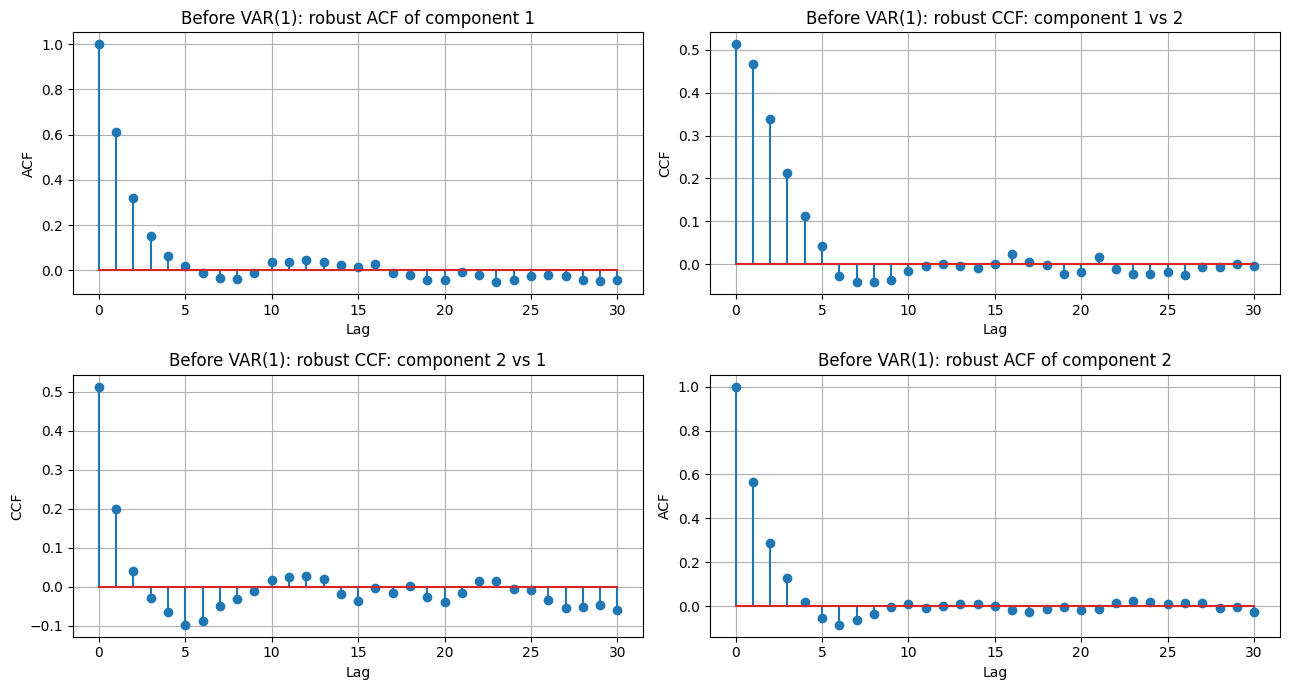

In [226]:
plot_2d_acf_ccf_diagnostics(
    est2d["diagnostics_R2"],
    title_prefix="Before VAR(1):"
)

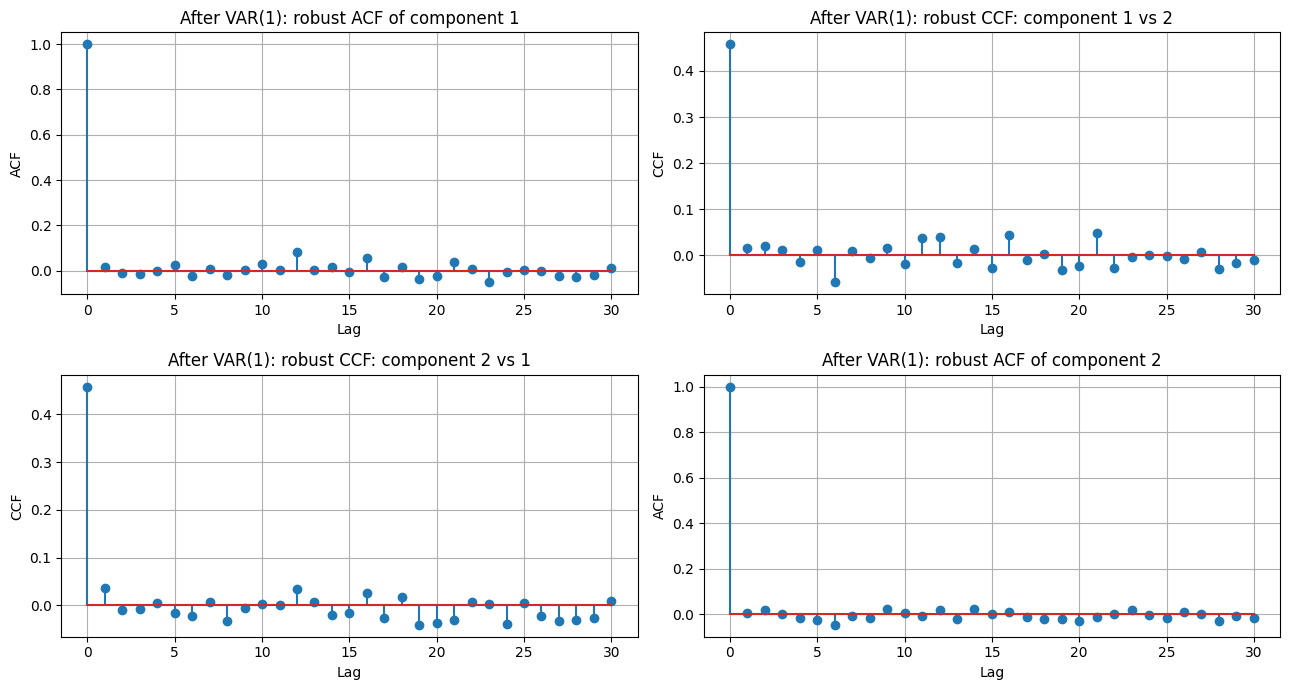

In [227]:
plot_2d_acf_ccf_diagnostics(
    est2d["diagnostics_R3"],
    title_prefix="After VAR(1):"
)

## Monte Carlo study for the two-dimensional model

The two-dimensional Monte Carlo experiment follows the same structure as in the one-dimensional case. For each value of $\alpha$, we generate 100 independent trajectories, apply the full estimation procedure, and collect the estimated trend vectors, scale vectors, VAR(1) matrices and stability indices.

The VAR order is fixed to $p=1$, because the simulated normalized random component is generated from a VAR(1) model.

In [178]:
import importlib
import estimation2d

importlib.reload(estimation2d)

from estimation2d import (
    estimate_2d_model_fixed_var1,
    summarize_2d_estimation,
)

In the two-dimensional case, the scale estimator required an additional calibration of the absolute scale level. The same one-dimensional calibration did not directly transfer to the multidimensional model, because the innovations are generated from a sub-Gaussian vector with covariance matrix $\Sigma$, which changes the effective marginal scale of each component.

Therefore, a common scale multiplier $c_{2D}=1.663$ was applied to both components. This correction affects only the absolute level of the estimated scale trajectories. It does not change the qualitative structure of the estimation procedure and has little influence on the VAR and stability-index estimates, which are mostly scale-invariant.

In [179]:
scale_multiplier_2d = 1.6629888237094692
scale_multiplier_2d

1.6629888237094692

In [180]:
import inspect

print(inspect.signature(estimate_2d_model_fixed_var1))

(S, trend_window=501, scale_window=151, h_max=30, compute_diagnostics=True, scale_multiplier=1.0)


## Functions

In [181]:
def run_mc_2d_for_alpha(
    alpha,
    n_replications=100,
    base_seed=20_000,
    trend_window=501,
    scale_window=151,
    scale_multiplier=1.0,
):
    T_hats = []
    SC_hats = []
    Theta_hats = []
    alpha_hats = []
    alpha_1_hats = []
    alpha_2_hats = []

    representative_sim = None
    representative_est = None

    for rep in range(n_replications):
        seed = base_seed + rep

        sim_rep = simulate_2d_model(
            **base_params_2d,
            alpha=alpha,
            random_state=seed,
        )

        est_rep = estimate_2d_model_fixed_var1(
            sim_rep["S"],
            trend_window=trend_window,
            scale_window=scale_window,
            h_max=30,
            compute_diagnostics=(rep == 0),
            scale_multiplier=scale_multiplier,
        )

        T_hats.append(est_rep["T_hat"])
        SC_hats.append(est_rep["SC_hat"])
        Theta_hats.append(est_rep["Theta_hat"])
        alpha_hats.append(est_rep["alpha_hat"])
        alpha_1_hats.append(est_rep["alpha_info"]["alpha_1"])
        alpha_2_hats.append(est_rep["alpha_info"]["alpha_2"])

        if rep == 0:
            representative_sim = sim_rep
            representative_est = est_rep

    return {
        "alpha": alpha,
        "t": representative_sim["t"],
        "true_T": representative_sim["T"],
        "true_SC": representative_sim["SC"],
        "true_Theta": representative_sim["Theta"],
        "true_Sigma": representative_sim["Sigma"],
        "T_hats": np.asarray(T_hats),
        "SC_hats": np.asarray(SC_hats),
        "Theta_hats": np.asarray(Theta_hats),
        "alpha_hats": np.asarray(alpha_hats),
        "alpha_1_hats": np.asarray(alpha_1_hats),
        "alpha_2_hats": np.asarray(alpha_2_hats),
        "representative_sim": representative_sim,
        "representative_est": representative_est,
    }

In [167]:
def plot_mc_2d_part1(result):
    alpha = result["alpha"]
    t = result["t"]

    T_hats = result["T_hats"]
    SC_hats = result["SC_hats"]
    Theta_hats = result["Theta_hats"]

    true_T = result["true_T"]
    true_SC = result["true_SC"]
    true_Theta = result["true_Theta"]

    fig, axes = plt.subplots(4, 2, figsize=(13, 14))

    # Trend component 1
    ax = axes[0, 0]
    for T_hat in T_hats:
        ax.plot(t, T_hat[:, 0], color="gray", alpha=0.15, linewidth=0.8)
    ax.plot(t, true_T[:, 0], color="blue", linewidth=2.5, label=r"True $T_1(t)$")
    ax.set_title(rf"Estimated trend trajectories $T_1(t)$, $\alpha={alpha}$")
    ax.set_xlabel("t")
    ax.set_ylabel(r"$T_1(t)$")
    ax.grid(True)
    ax.legend()

    # Trend component 2
    ax = axes[0, 1]
    for T_hat in T_hats:
        ax.plot(t, T_hat[:, 1], color="gray", alpha=0.15, linewidth=0.8)
    ax.plot(t, true_T[:, 1], color="red", linewidth=2.5, label=r"True $T_2(t)$")
    ax.set_title(rf"Estimated trend trajectories $T_2(t)$, $\alpha={alpha}$")
    ax.set_xlabel("t")
    ax.set_ylabel(r"$T_2(t)$")
    ax.grid(True)
    ax.legend()

    # Scale component 1
    ax = axes[1, 0]
    for SC_hat in SC_hats:
        ax.plot(t, SC_hat[:, 0], color="gray", alpha=0.15, linewidth=0.8)
    ax.plot(t, true_SC[:, 0], color="blue", linewidth=2.5, label=r"True $SC_1(t)$")
    ax.set_title(rf"Estimated scale trajectories $SC_1(t)$, $\alpha={alpha}$")
    ax.set_xlabel("t")
    ax.set_ylabel(r"$SC_1(t)$")
    ax.grid(True)
    ax.legend()

    # Scale component 2
    ax = axes[1, 1]
    for SC_hat in SC_hats:
        ax.plot(t, SC_hat[:, 1], color="gray", alpha=0.15, linewidth=0.8)
    ax.plot(t, true_SC[:, 1], color="red", linewidth=2.5, label=r"True $SC_2(t)$")
    ax.set_title(rf"Estimated scale trajectories $SC_2(t)$, $\alpha={alpha}$")
    ax.set_xlabel("t")
    ax.set_ylabel(r"$SC_2(t)$")
    ax.grid(True)
    ax.legend()

    theta_entries = [
        (0, 0, r"$\hat{\Theta}_{11}$", true_Theta[0, 0]),
        (0, 1, r"$\hat{\Theta}_{12}$", true_Theta[0, 1]),
        (1, 0, r"$\hat{\Theta}_{21}$", true_Theta[1, 0]),
        (1, 1, r"$\hat{\Theta}_{22}$", true_Theta[1, 1]),
    ]

    positions = [(2, 0), (2, 1), (3, 0), (3, 1)]

    for (i, j, label, true_value), (row, col) in zip(theta_entries, positions):
        ax = axes[row, col]
        values = Theta_hats[:, i, j]
        ax.boxplot(values, labels=[label])
        ax.axhline(true_value, linestyle="--", color="red", label=rf"true = {true_value:.2f}")
        ax.set_title(rf"Distribution of {label}")
        ax.set_ylabel(label)
        ax.grid(True)
        ax.legend()

    fig.suptitle(
        rf"Monte Carlo estimation results for the two-dimensional model, $\alpha={alpha}$ — part I",
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()

In [169]:
def plot_2d_acf_ccf_with_band(diagnostics, n_obs, title_prefix=""):
    fig, axes = plt.subplots(2, 2, figsize=(13, 7))

    names = [
        ("acf_1", "ACF component 1", axes[0, 0]),
        ("ccf_12", "CCF component 1 vs 2", axes[0, 1]),
        ("ccf_21", "CCF component 2 vs 1", axes[1, 0]),
        ("acf_2", "ACF component 2", axes[1, 1]),
    ]

    band = 1.96 / np.sqrt(n_obs)

    for key, title, ax in names:
        values = diagnostics[key]
        lags = np.arange(len(values))

        ax.stem(lags, values)
        ax.axhline(0, linewidth=1)
        ax.axhline(band, linestyle="--", label="approx. 95% band")
        ax.axhline(-band, linestyle="--")
        ax.set_title(f"{title_prefix} {title}")
        ax.set_xlabel("Lag")
        ax.set_ylabel("value")
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [170]:
def plot_mc_2d_part2(result):
    alpha = result["alpha"]
    est_rep = result["representative_est"]

    diagnostics_R2 = est_rep["diagnostics_R2"]
    diagnostics_R3 = est_rep["diagnostics_R3"]

    R2_hat = est_rep["R2_hat"]
    R3_hat = est_rep["R3_hat"]

    print(f"Diagnostics before VAR(1), alpha={alpha}")
    plot_2d_acf_ccf_with_band(
        diagnostics_R2,
        n_obs=len(R2_hat),
        title_prefix=rf"Before VAR(1), $\alpha={alpha}$:"
    )

    print(f"Diagnostics after VAR(1), alpha={alpha}")
    plot_2d_acf_ccf_with_band(
        diagnostics_R3,
        n_obs=len(R3_hat),
        title_prefix=rf"After VAR(1), $\alpha={alpha}$:"
    )

    plt.figure(figsize=(6, 5))

    plt.boxplot(result["alpha_hats"], labels=[r"$\hat{\alpha}$"])
    plt.axhline(alpha, linestyle="--", color="red", label=rf"true $\alpha={alpha}$")
    plt.title(rf"Distribution of stability index estimates, $\alpha={alpha}$")
    plt.ylabel(r"$\hat{\alpha}$")
    plt.grid(True)
    plt.legend()
    plt.show()

## Simulation

In [182]:
alphas_order_2d = [1.85, 1.90, 1.95, 2.00]
n_replications_2d = 100

mc_2d_final_scaled = {}

for idx, alpha in enumerate(alphas_order_2d):
    print(f"Running scaled 2D Monte Carlo for alpha={alpha}...")
    mc_2d_final_scaled[alpha] = run_mc_2d_for_alpha(
        alpha=alpha,
        n_replications=n_replications_2d,
        base_seed=20_000 + idx * 10_000,
        trend_window=501,
        scale_window=151,
        scale_multiplier=scale_multiplier_2d,
    )

print("Done.")

Running scaled 2D Monte Carlo for alpha=1.85...
Running scaled 2D Monte Carlo for alpha=1.9...
Running scaled 2D Monte Carlo for alpha=1.95...
Running scaled 2D Monte Carlo for alpha=2.0...
Done.


In [186]:
mc_2d_summary_scaled_rows = []

for alpha in alphas_order_2d:
    result = mc_2d_final_scaled[alpha]
    Theta_hats = result["Theta_hats"]

    mc_2d_summary_scaled_rows.append({
        "true_alpha": alpha,

        "mean_alpha_hat": np.mean(result["alpha_hats"]),
        "median_alpha_hat": np.median(result["alpha_hats"]),
        "std_alpha_hat": np.std(result["alpha_hats"], ddof=1),

        "mean_alpha_1_hat": np.mean(result["alpha_1_hats"]),
        "mean_alpha_2_hat": np.mean(result["alpha_2_hats"]),

        "mean_theta_11": np.mean(Theta_hats[:, 0, 0]),
        "median_theta_11": np.median(Theta_hats[:, 0, 0]),
        "true_theta_11": Theta_true[0, 0],

        "mean_theta_12": np.mean(Theta_hats[:, 0, 1]),
        "median_theta_12": np.median(Theta_hats[:, 0, 1]),
        "true_theta_12": Theta_true[0, 1],

        "mean_theta_21": np.mean(Theta_hats[:, 1, 0]),
        "median_theta_21": np.median(Theta_hats[:, 1, 0]),
        "true_theta_21": Theta_true[1, 0],

        "mean_theta_22": np.mean(Theta_hats[:, 1, 1]),
        "median_theta_22": np.median(Theta_hats[:, 1, 1]),
        "true_theta_22": Theta_true[1, 1],

        "n_replications": n_replications_2d,
    })

mc_2d_summary_scaled = pd.DataFrame(mc_2d_summary_scaled_rows)
mc_2d_summary_scaled

,true_alpha,mean_alpha_hat,median_alpha_hat,std_alpha_hat,mean_alpha_1_hat,mean_alpha_2_hat,mean_theta_11,median_theta_11,true_theta_11,mean_theta_12,median_theta_12,true_theta_12,mean_theta_21,median_theta_21,true_theta_21,mean_theta_22,median_theta_22,true_theta_22,n_replications
0,1.85,1.853972,1.852878,0.046767,1.852139,1.855805,0.488665,0.486248,0.5,0.188118,0.189874,0.2,-0.108152,-0.108307,-0.1,0.596985,0.597428,0.6,100
1,1.90,1.886680,1.890752,0.047744,1.887711,1.885649,0.497038,0.495775,0.5,0.188254,0.189149,0.2,-0.106244,-0.111650,-0.1,0.594643,0.594761,0.6,100
2,1.95,1.941391,1.939242,0.042502,1.941119,1.941662,0.490795,0.492372,0.5,0.195107,0.195034,0.2,-0.116733,-0.116132,-0.1,0.603795,0.608446,0.6,100
3,2.00,1.967227,1.974637,0.032468,1.965264,1.969190,0.490862,0.492024,0.5,0.192216,0.192791,0.2,-0.109185,-0.110934,-0.1,0.596896,0.596507,0.6,100


The Monte Carlo summary confirms that the VAR(1) matrix is estimated with reasonable accuracy. The diagonal entries $\Theta_{11}$ and $\Theta_{22}$ are recovered particularly well. The off-diagonal entries show slightly larger deviations, which is expected because they describe cross-dependence between components and are more sensitive to errors in trend and scale reconstruction.

The stability index $\alpha$ is also estimated reasonably well. The estimates are close to the true values for all considered cases, with a small downward bias visible for larger values of $\alpha$.

/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/2152976855.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/2152976855.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/2152976855.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/2152976855.py:71: MatplotlibDeprecationWarning: The 'labels' paramet

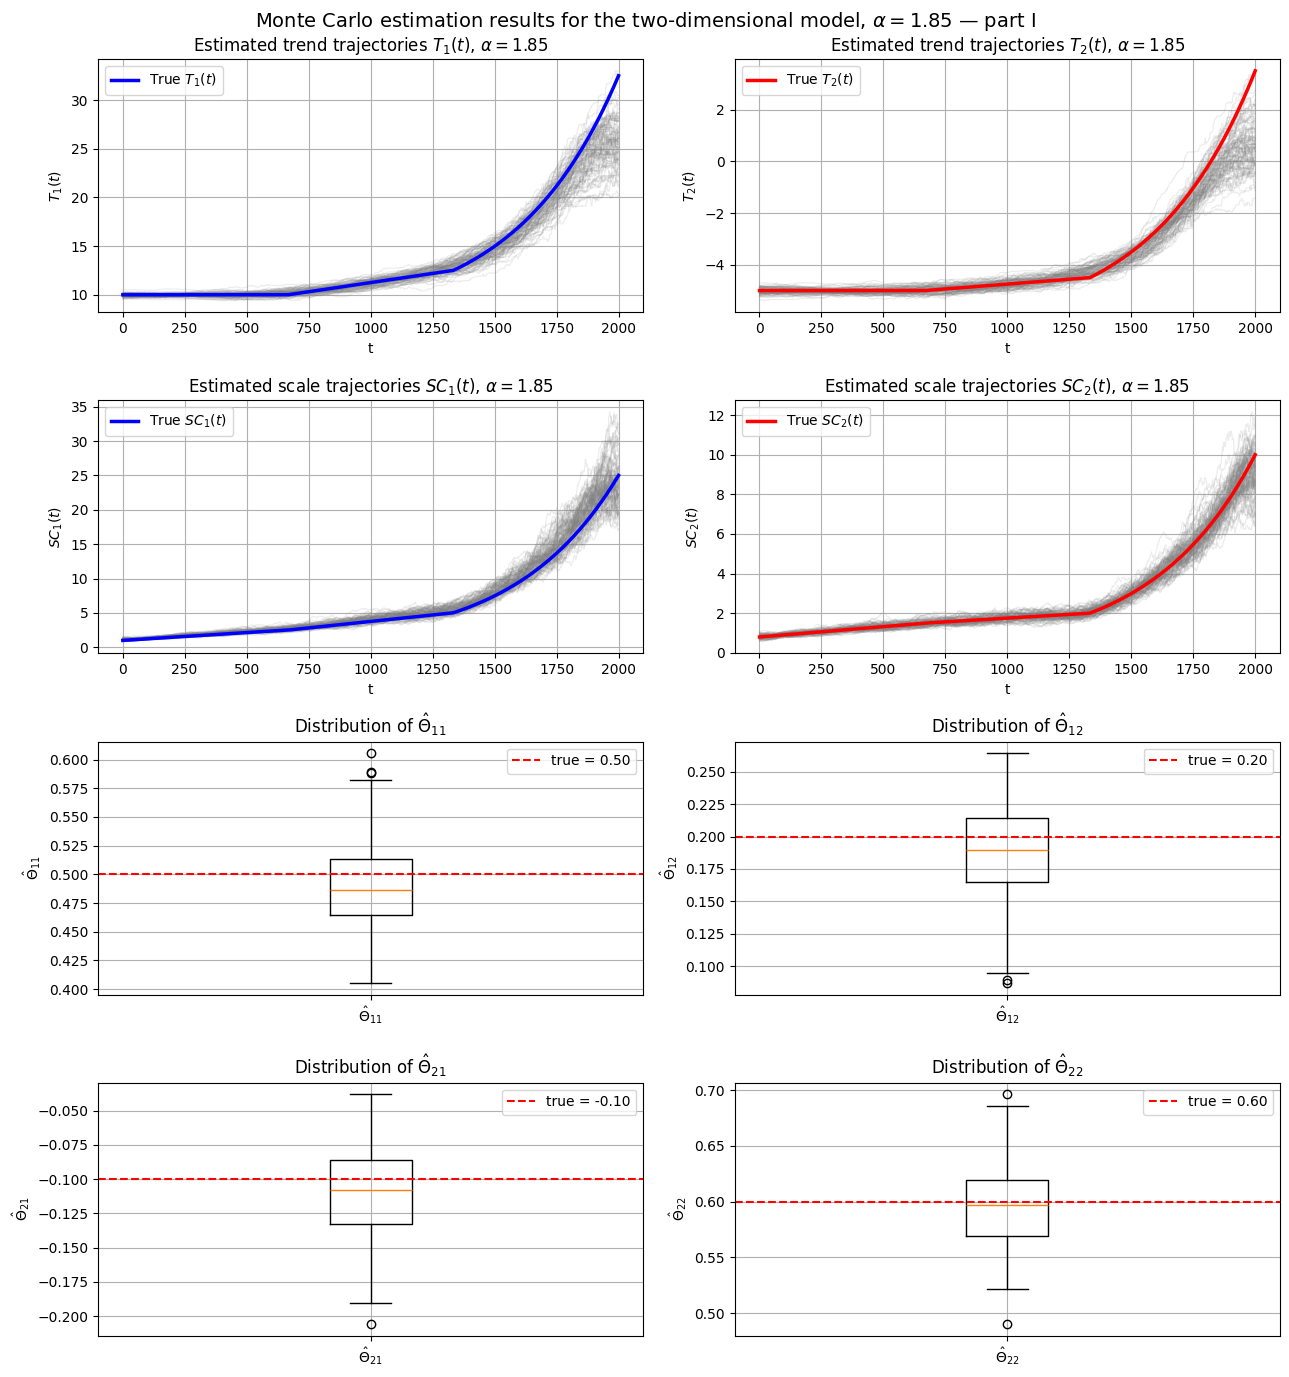

/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/2152976855.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/2152976855.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/2152976855.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/2152976855.py:71: MatplotlibDeprecationWarning: The 'labels' paramet

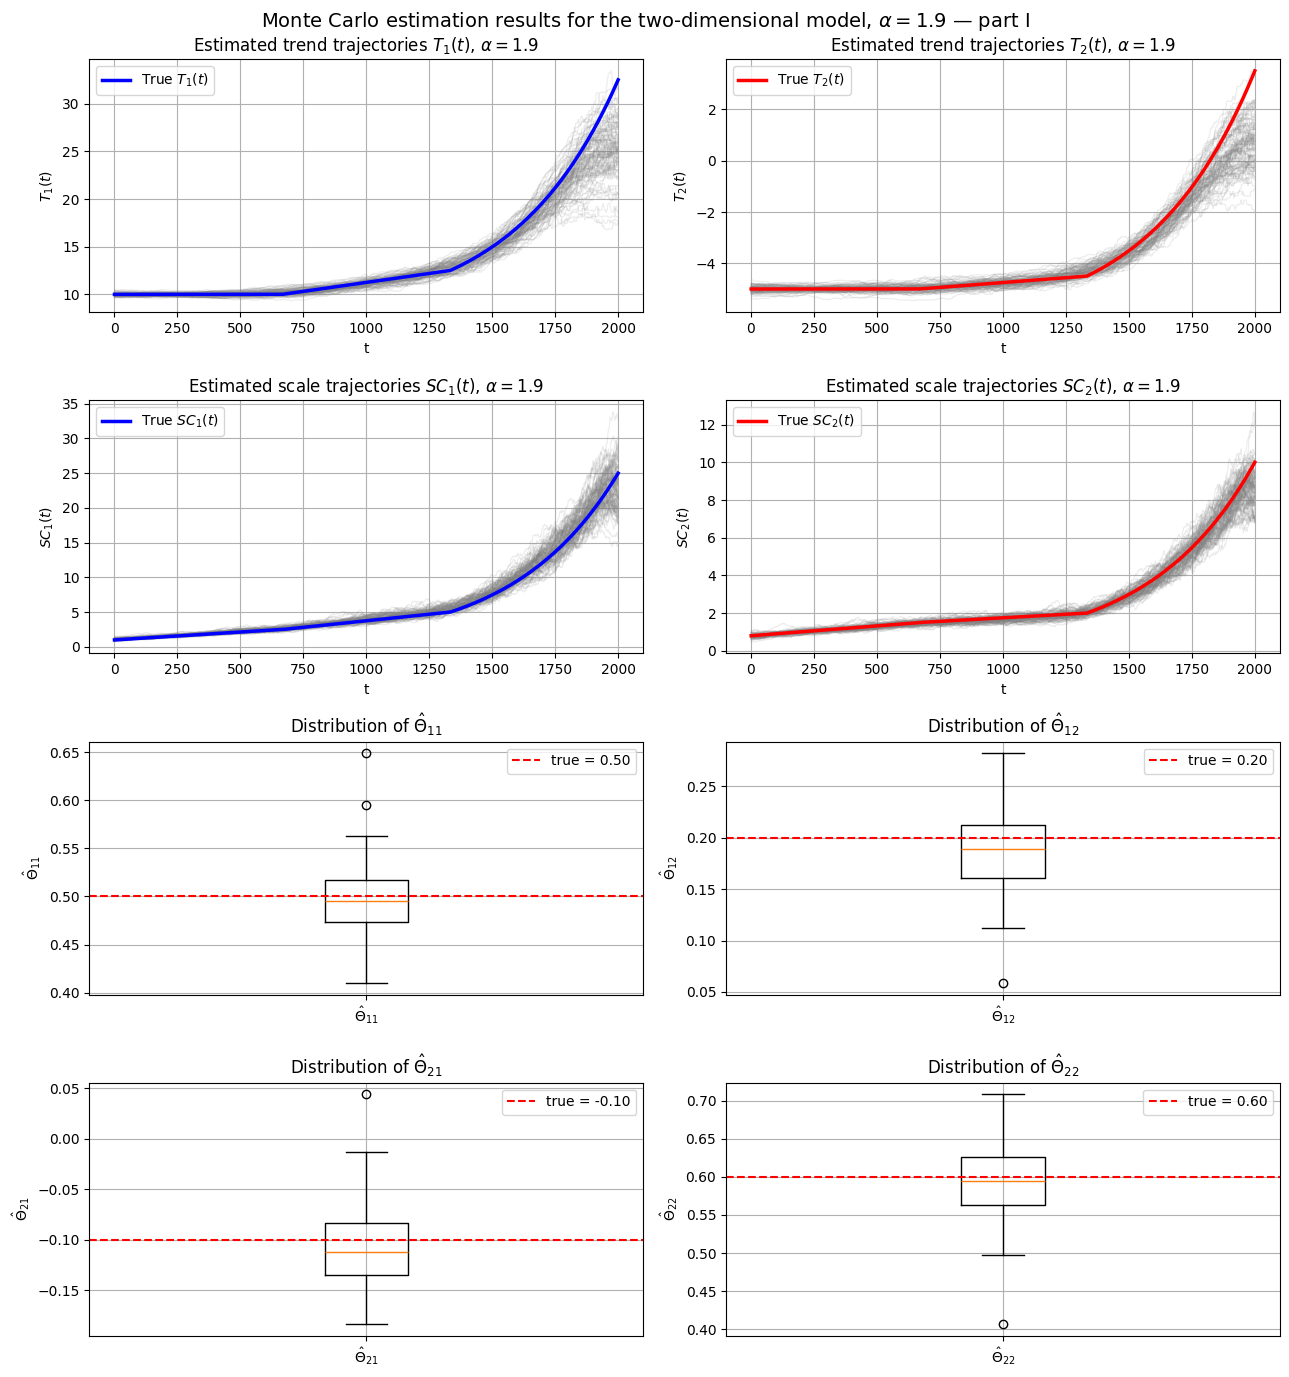

/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/2152976855.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/2152976855.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/2152976855.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/2152976855.py:71: MatplotlibDeprecationWarning: The 'labels' paramet

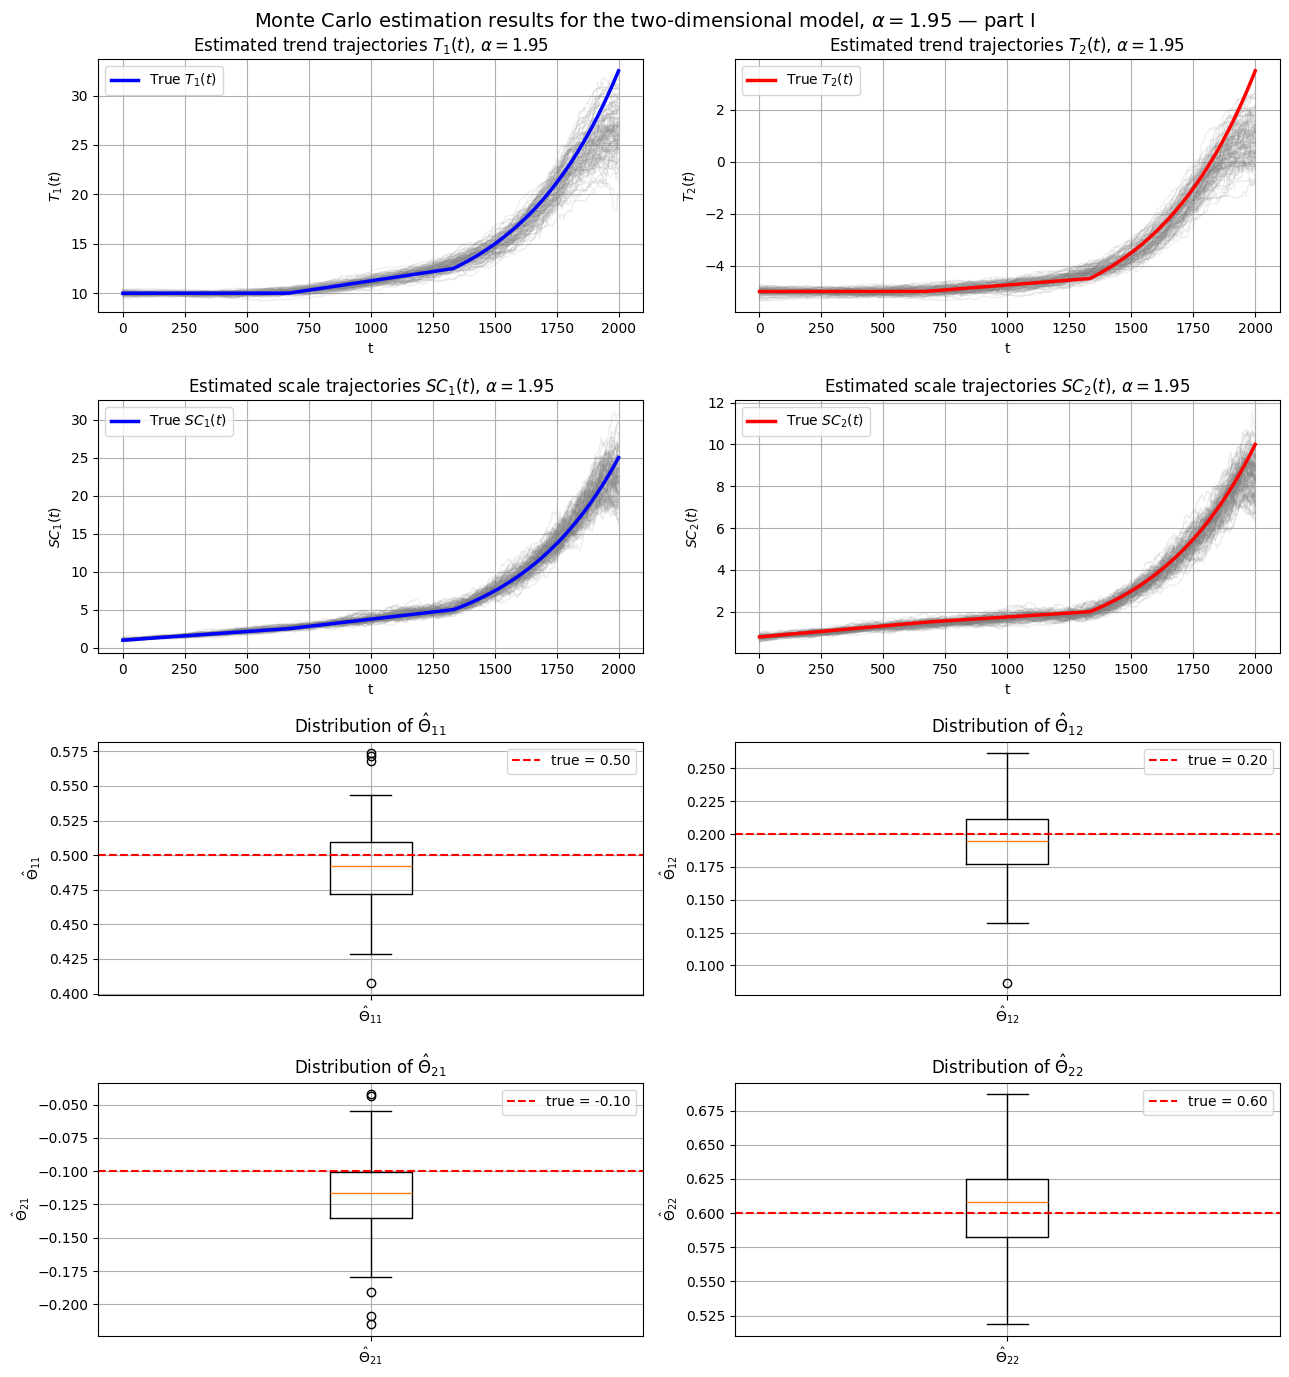

/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/2152976855.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/2152976855.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/2152976855.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/2152976855.py:71: MatplotlibDeprecationWarning: The 'labels' paramet

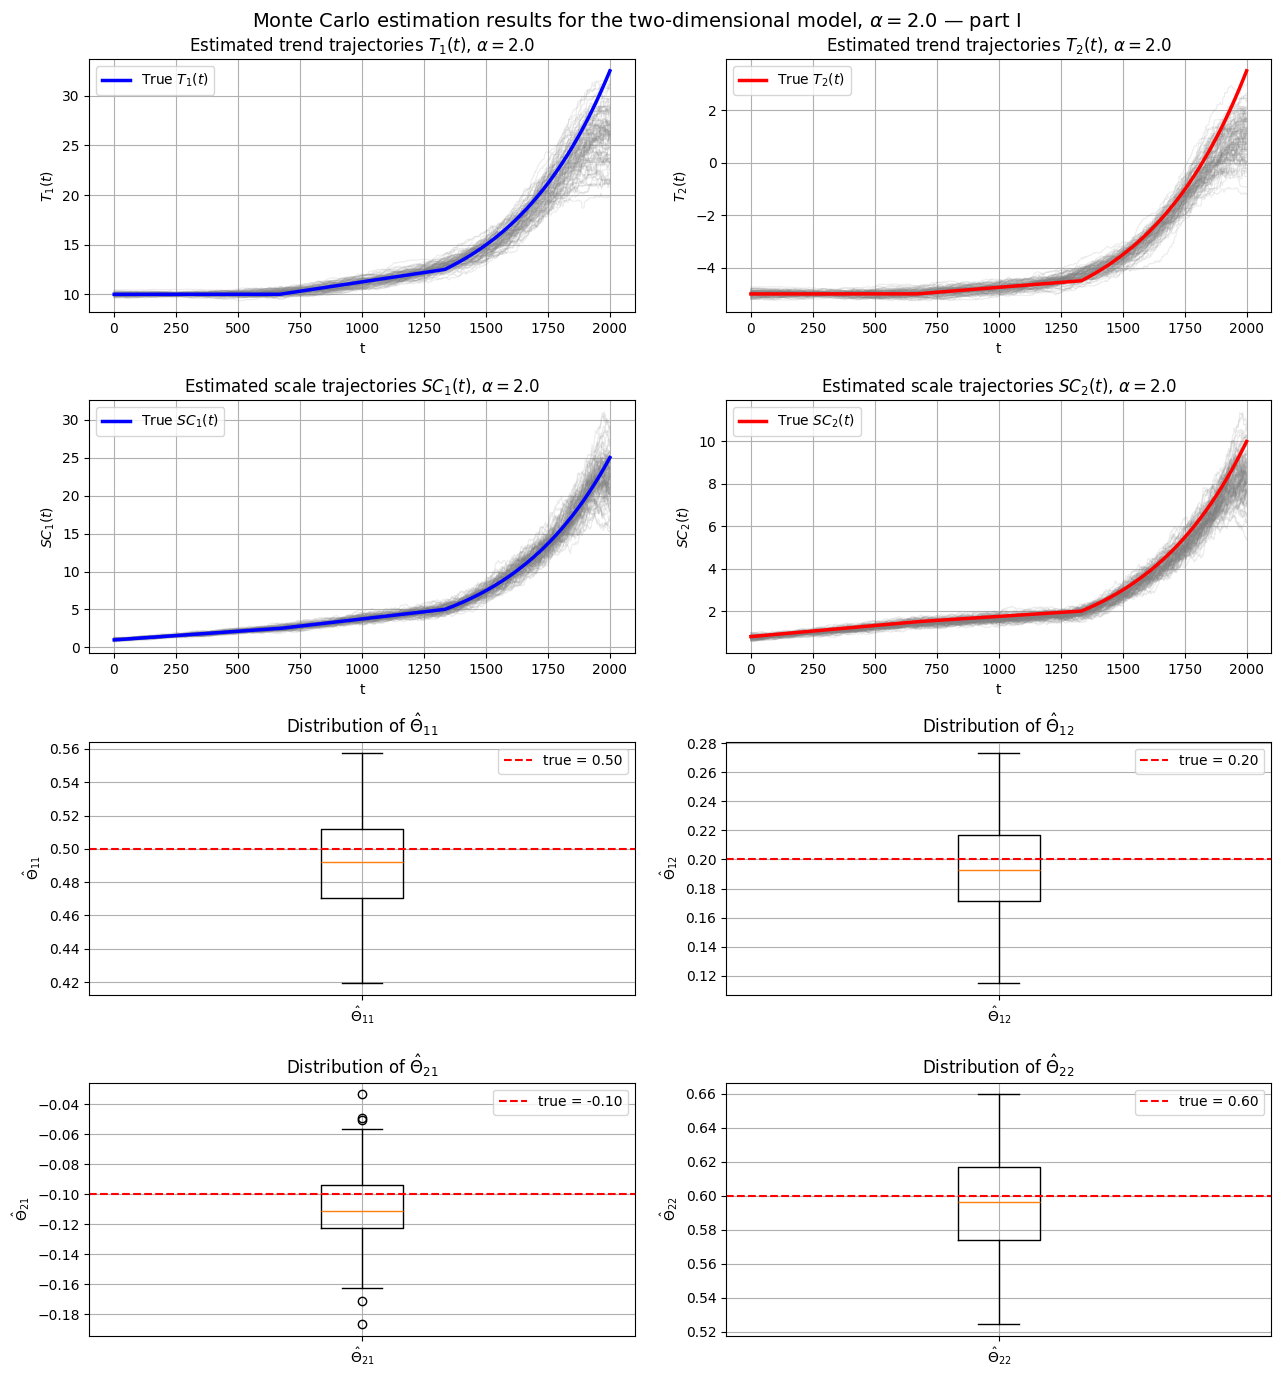

In [187]:
for alpha in alphas_order_2d:
    plot_mc_2d_part1(mc_2d_final_scaled[alpha])

The first two rows show Monte Carlo trajectories of the estimated trend and scale functions. After applying the two-dimensional scale calibration multiplier, the true scale functions are located inside the cloud of estimated trajectories. This indicates that the robust scale estimator correctly captures the shape of the time-varying scale after calibration.

The last two rows show boxplots of the estimated entries of the VAR(1) matrix. The red dashed lines denote the true values used in simulation. The estimates are concentrated close to the true parameters, although small deviations are visible for the off-diagonal entries.

In [188]:
mc_2d_final_scaled[1.90]["representative_est"]["settings"]

{'trend_window': 501,
 'scale_window': 151,
 'h_max': 30,
 'compute_diagnostics': True,
 'var_order': 1,
 'scale_multiplier': 1.6629888237094692}

Diagnostics before VAR(1), alpha=1.85


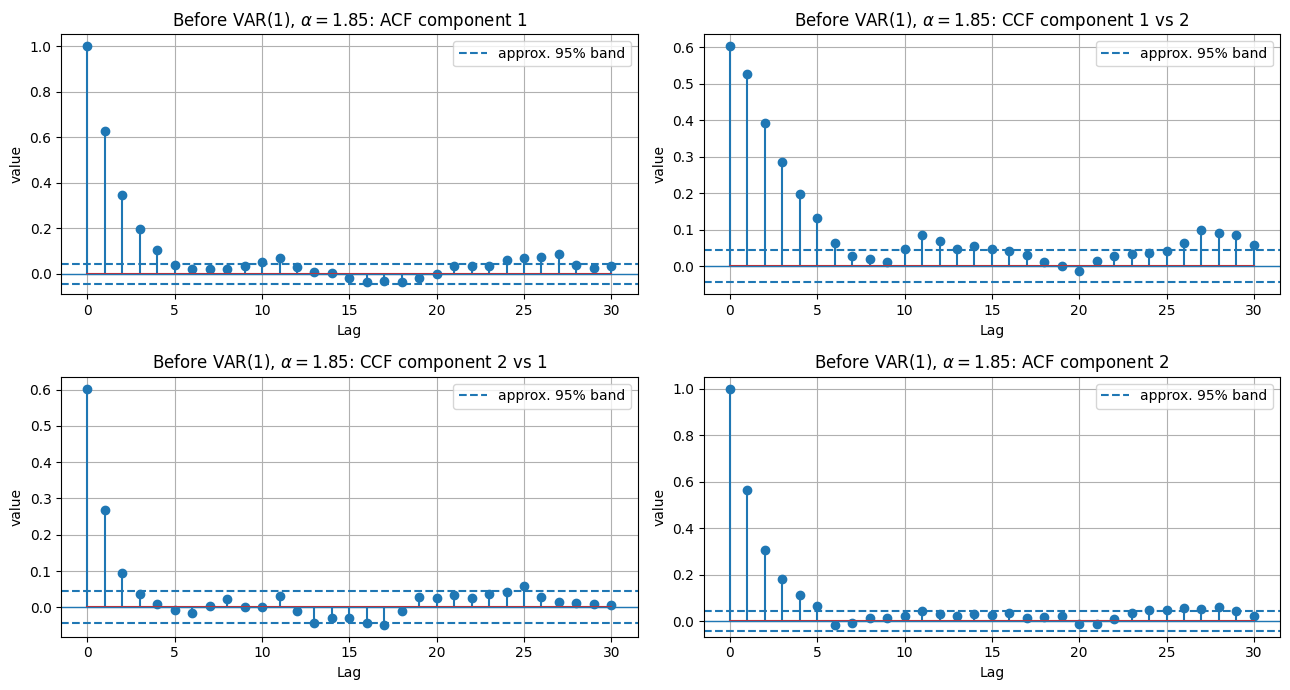

Diagnostics after VAR(1), alpha=1.85


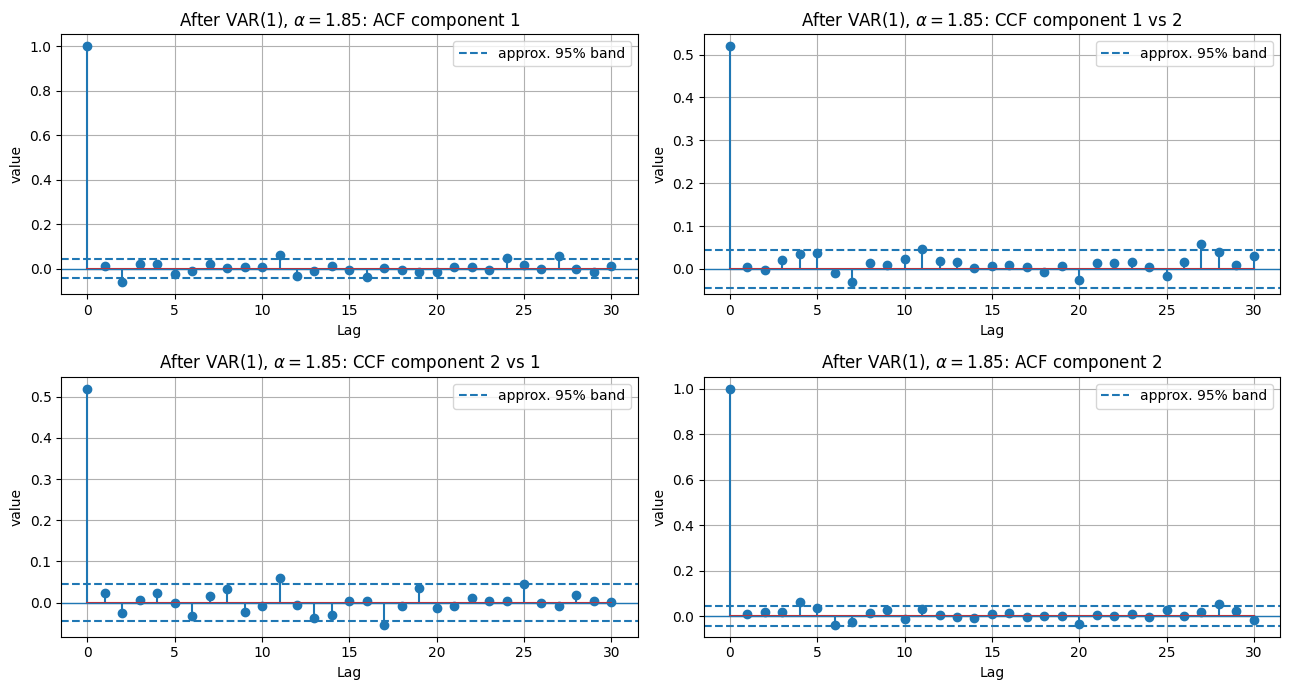

/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/964494109.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result["alpha_hats"], labels=[r"$\hat{\alpha}$"])


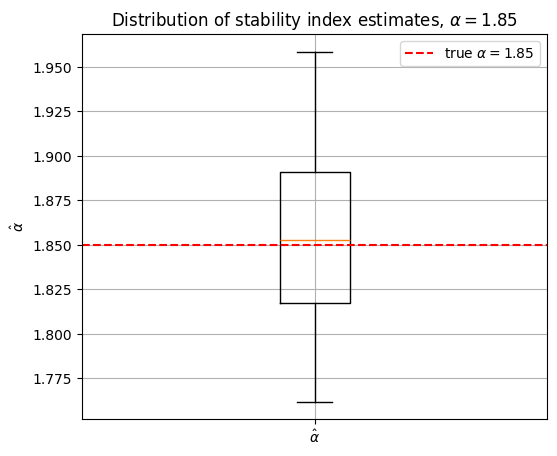

Diagnostics before VAR(1), alpha=1.9


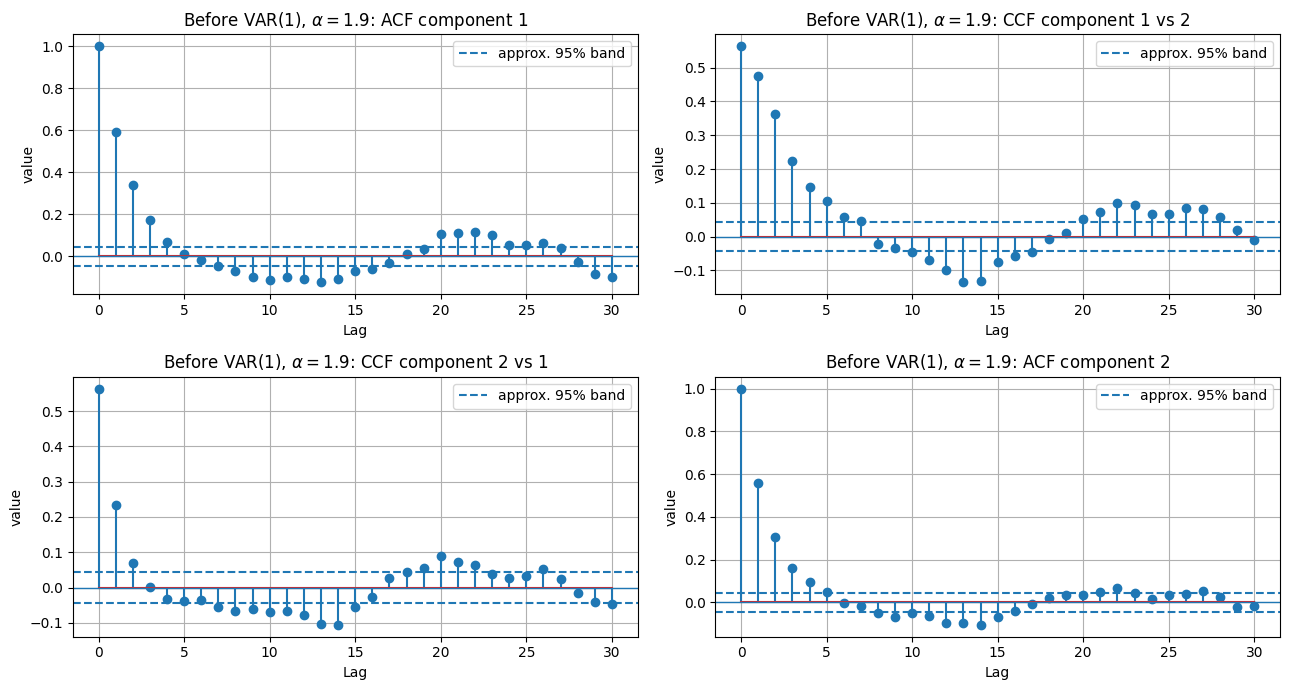

Diagnostics after VAR(1), alpha=1.9


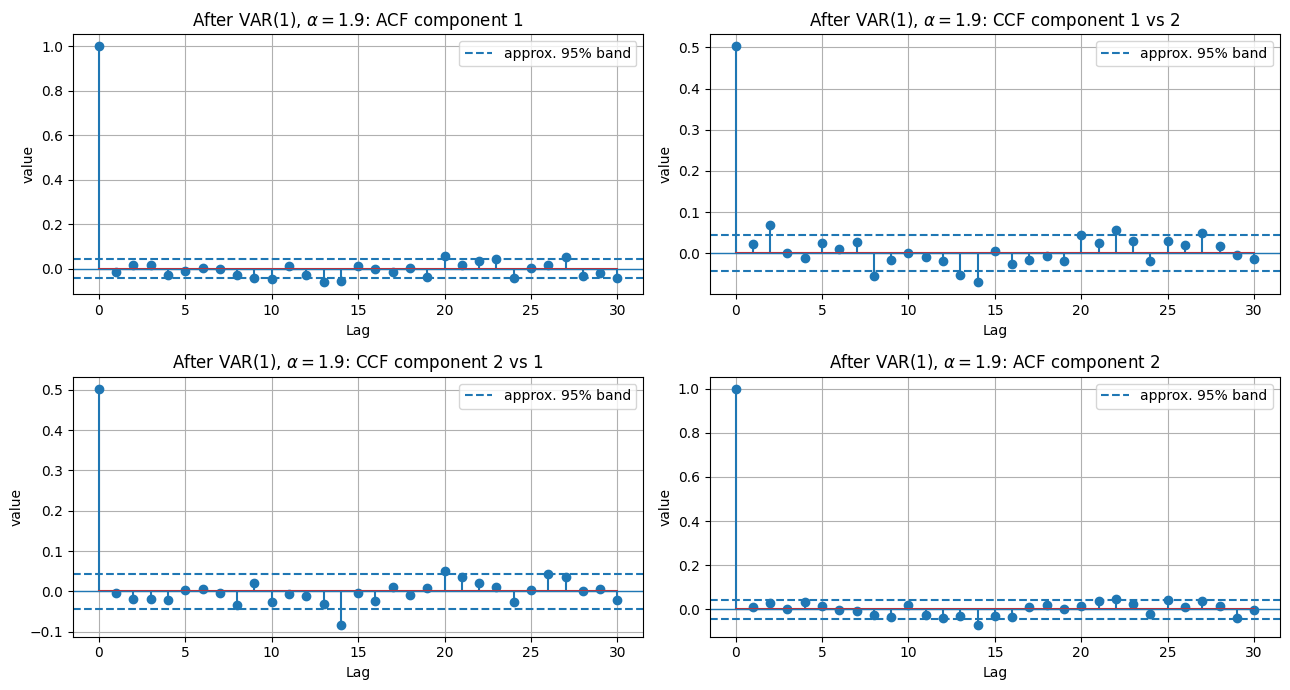

/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/964494109.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result["alpha_hats"], labels=[r"$\hat{\alpha}$"])


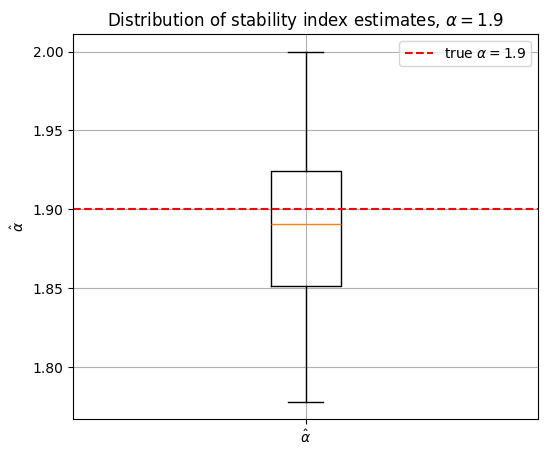

Diagnostics before VAR(1), alpha=1.95


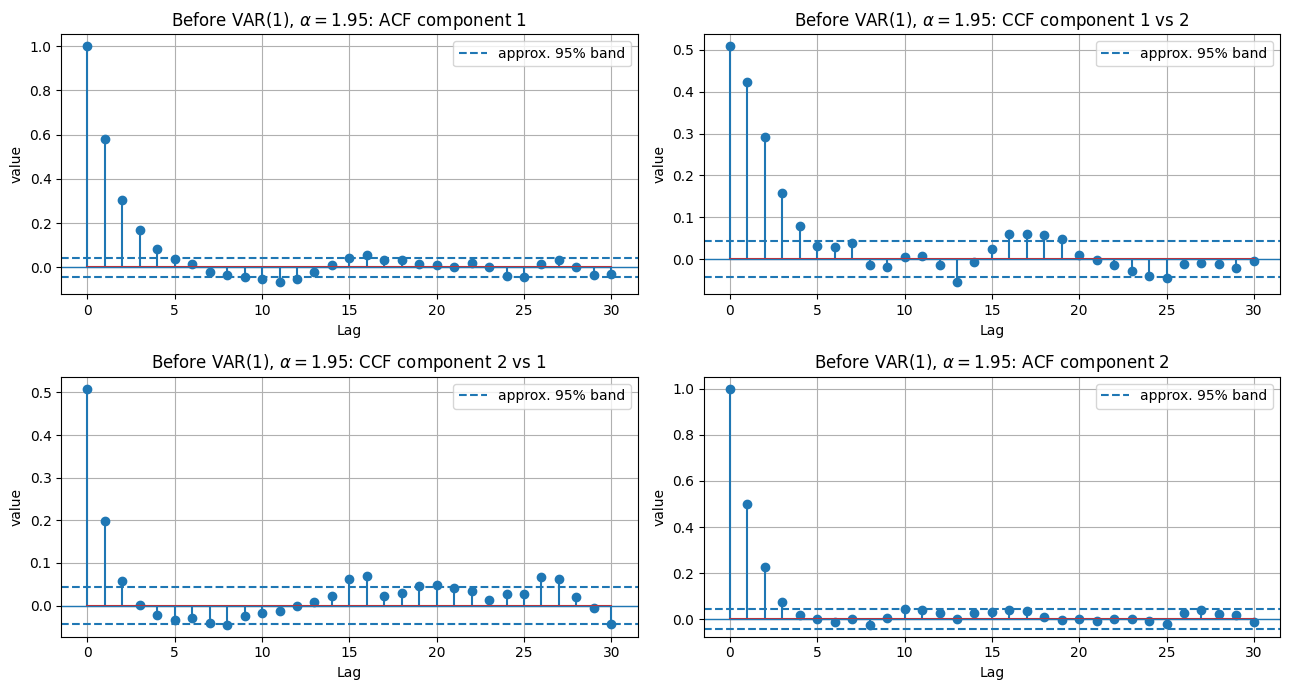

Diagnostics after VAR(1), alpha=1.95


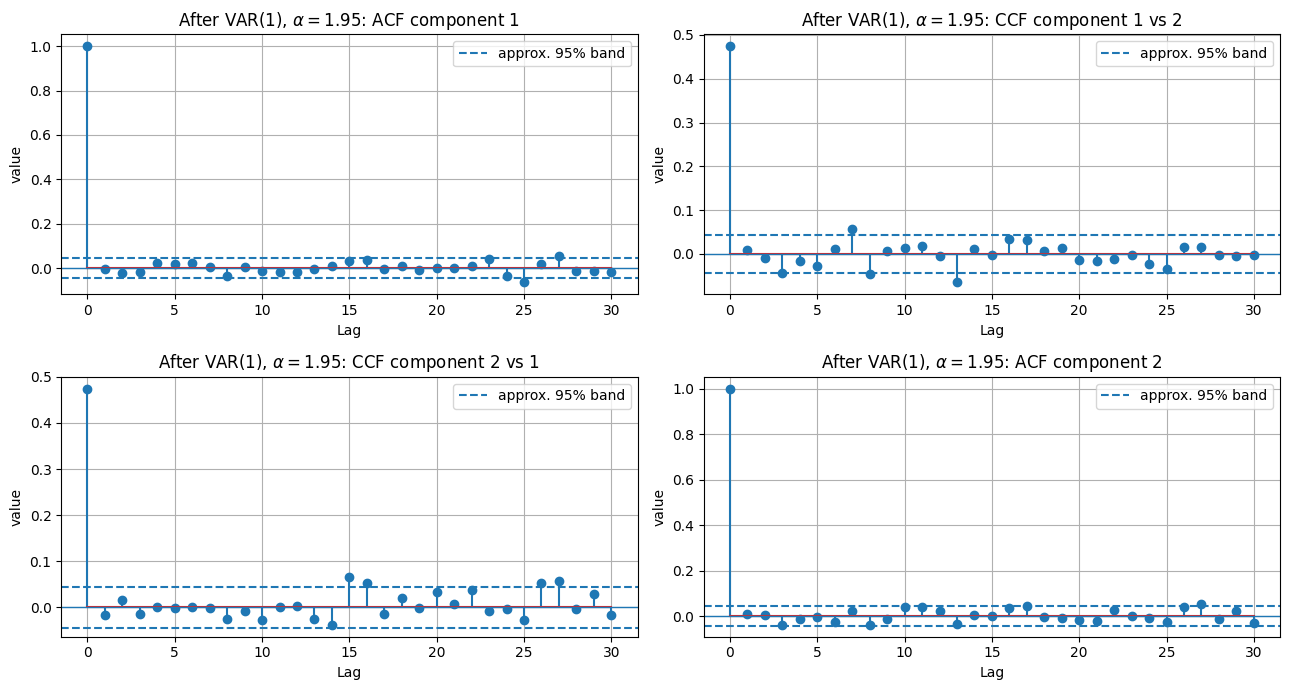

/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/964494109.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result["alpha_hats"], labels=[r"$\hat{\alpha}$"])


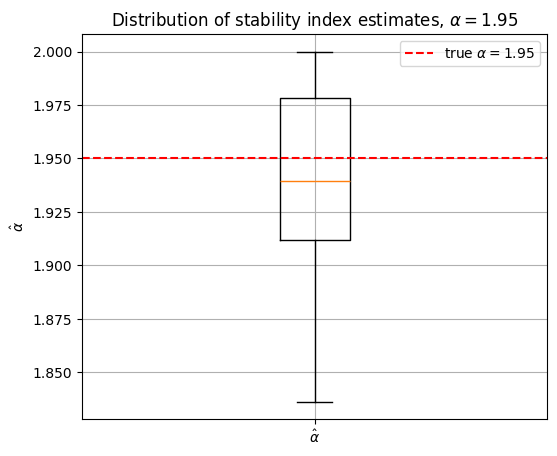

Diagnostics before VAR(1), alpha=2.0


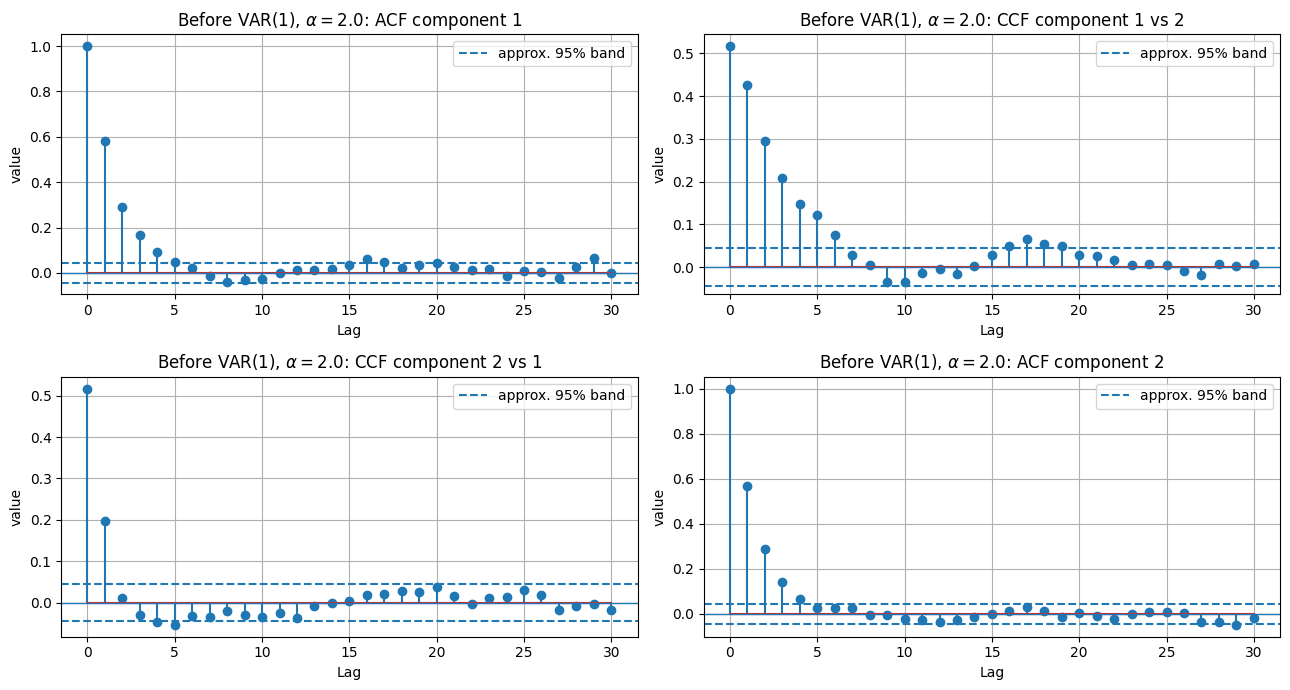

Diagnostics after VAR(1), alpha=2.0


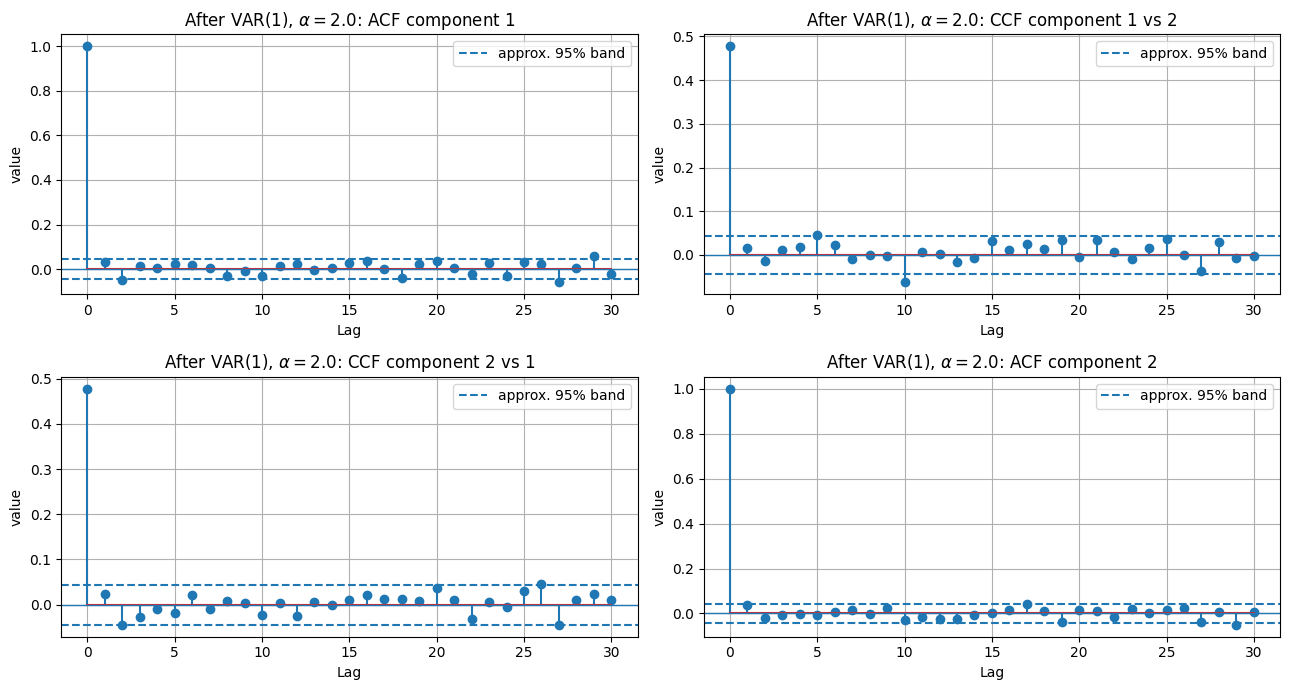

/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/964494109.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result["alpha_hats"], labels=[r"$\hat{\alpha}$"])


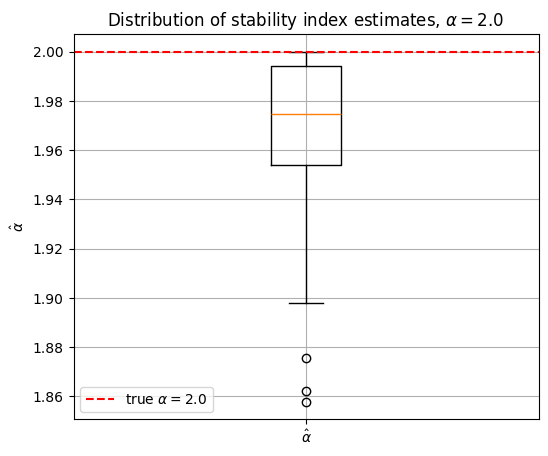

In [189]:
for alpha in alphas_order_2d:
    plot_mc_2d_part2(mc_2d_final_scaled[alpha])

The residual diagnostics after fitting the VAR(1) model indicate that the temporal dependence has been effectively removed. For both components, the robust ACF values at lags greater than zero are close to zero and mostly remain within the approximate 95% confidence bands. The same conclusion holds for the robust cross-correlation functions, which suggests that the fitted VAR(1) model adequately captures both within-component and cross-component linear dependence.

The boxplot of the stability-index estimates shows that the estimator recovers the true value of $\alpha$ reasonably well. A slight downward bias is still visible, but the estimates remain concentrated around the true parameter value.

In [191]:
import importlib
import estimation2d

importlib.reload(estimation2d)

from estimation2d import (
    estimate_2d_model_fixed_var1,
    summarize_2d_estimation,
    estimate_sigma_characteristic_function,
)

# $\Sigma$

In [192]:
est2d_sigma = estimate_2d_model_fixed_var1(
    sim2d["S"],
    trend_window=501,
    scale_window=151,
    h_max=30,
    compute_diagnostics=True,
    scale_multiplier=scale_multiplier_2d,
    estimate_sigma=True,
    sigma_grid_size=9,
    sigma_grid_max=3.0,
    sigma_maxiter=300,
)

summarize_2d_estimation(est2d_sigma)

Two-dimensional estimation summary
----------------------------------
Estimated Theta:
[[ 0.49545282  0.19921618]
 [-0.12965311  0.62248887]]

Estimated alpha: 1.8591

Componentwise alpha:
  alpha_1: 1.8422
  alpha_2: 1.8760

Estimated Sigma:
[[0.55393329 0.2717225 ]
 [0.2717225  0.63126207]]


In [193]:
def run_mc_2d_for_alpha(
    alpha,
    n_replications=100,
    base_seed=20_000,
    trend_window=501,
    scale_window=151,
    scale_multiplier=1.0,
    estimate_sigma=False,
):
    T_hats = []
    SC_hats = []
    Theta_hats = []
    Sigma_hats = []
    alpha_hats = []
    alpha_1_hats = []
    alpha_2_hats = []

    representative_sim = None
    representative_est = None

    for rep in range(n_replications):
        seed = base_seed + rep

        sim_rep = simulate_2d_model(
            **base_params_2d,
            alpha=alpha,
            random_state=seed,
        )

        est_rep = estimate_2d_model_fixed_var1(
            sim_rep["S"],
            trend_window=trend_window,
            scale_window=scale_window,
            h_max=30,
            compute_diagnostics=(rep == 0),
            scale_multiplier=scale_multiplier,
            estimate_sigma=estimate_sigma,
            sigma_grid_size=9,
            sigma_grid_max=3.0,
            sigma_maxiter=300,
        )

        T_hats.append(est_rep["T_hat"])
        SC_hats.append(est_rep["SC_hat"])
        Theta_hats.append(est_rep["Theta_hat"])
        alpha_hats.append(est_rep["alpha_hat"])
        alpha_1_hats.append(est_rep["alpha_info"]["alpha_1"])
        alpha_2_hats.append(est_rep["alpha_info"]["alpha_2"])

        if estimate_sigma:
            Sigma_hats.append(est_rep["Sigma_hat"])

        if rep == 0:
            representative_sim = sim_rep
            representative_est = est_rep

    result = {
        "alpha": alpha,
        "t": representative_sim["t"],
        "true_T": representative_sim["T"],
        "true_SC": representative_sim["SC"],
        "true_Theta": representative_sim["Theta"],
        "true_Sigma": representative_sim["Sigma"],
        "T_hats": np.asarray(T_hats),
        "SC_hats": np.asarray(SC_hats),
        "Theta_hats": np.asarray(Theta_hats),
        "alpha_hats": np.asarray(alpha_hats),
        "alpha_1_hats": np.asarray(alpha_1_hats),
        "alpha_2_hats": np.asarray(alpha_2_hats),
        "representative_sim": representative_sim,
        "representative_est": representative_est,
    }

    if estimate_sigma:
        result["Sigma_hats"] = np.asarray(Sigma_hats)

    return result

In [198]:
n_replications_2d_sigma = 100

mc_2d_final_sigma = {}

for idx, alpha in enumerate(alphas_order_2d):
    print(f"Running 2D Monte Carlo with Sigma estimation for alpha={alpha}...")
    mc_2d_final_sigma[alpha] = run_mc_2d_for_alpha(
        alpha=alpha,
        n_replications=n_replications_2d_sigma,
        base_seed=40_000 + idx * 10_000,
        trend_window=501,
        scale_window=151,
        scale_multiplier=scale_multiplier_2d,
        estimate_sigma=True,
    )

print("Done.")

Running 2D Monte Carlo with Sigma estimation for alpha=1.85...
Running 2D Monte Carlo with Sigma estimation for alpha=1.9...
Running 2D Monte Carlo with Sigma estimation for alpha=1.95...
Running 2D Monte Carlo with Sigma estimation for alpha=2.0...
Done.


In [201]:
mc_2d_sigma_summary_rows = []

for alpha in alphas_order_2d:
    result = mc_2d_final_sigma[alpha]
    Theta_hats = result["Theta_hats"]
    Sigma_hats = result["Sigma_hats"]

    mc_2d_sigma_summary_rows.append({
        "true_alpha": alpha,

        "mean_alpha_hat": np.mean(result["alpha_hats"]),
        "median_alpha_hat": np.median(result["alpha_hats"]),
        "std_alpha_hat": np.std(result["alpha_hats"], ddof=1),

        "mean_theta_11": np.mean(Theta_hats[:, 0, 0]),
        "median_theta_11": np.median(Theta_hats[:, 0, 0]),
        "true_theta_11": Theta_true[0, 0],

        "mean_theta_12": np.mean(Theta_hats[:, 0, 1]),
        "median_theta_12": np.median(Theta_hats[:, 0, 1]),
        "true_theta_12": Theta_true[0, 1],

        "mean_theta_21": np.mean(Theta_hats[:, 1, 0]),
        "median_theta_21": np.median(Theta_hats[:, 1, 0]),
        "true_theta_21": Theta_true[1, 0],

        "mean_theta_22": np.mean(Theta_hats[:, 1, 1]),
        "median_theta_22": np.median(Theta_hats[:, 1, 1]),
        "true_theta_22": Theta_true[1, 1],

        "mean_sigma_11": np.mean(Sigma_hats[:, 0, 0]),
        "median_sigma_11": np.median(Sigma_hats[:, 0, 0]),
        "true_sigma_11": Sigma_true[0, 0],

        "mean_sigma_12": np.mean(Sigma_hats[:, 0, 1]),
        "median_sigma_12": np.median(Sigma_hats[:, 0, 1]),
        "true_sigma_12": Sigma_true[0, 1],

        "mean_sigma_21": np.mean(Sigma_hats[:, 1, 0]),
        "median_sigma_21": np.median(Sigma_hats[:, 1, 0]),
        "true_sigma_21": Sigma_true[1, 0],

        "mean_sigma_22": np.mean(Sigma_hats[:, 1, 1]),
        "median_sigma_22": np.median(Sigma_hats[:, 1, 1]),
        "true_sigma_22": Sigma_true[1, 1],

        "n_replications": n_replications_2d_sigma,
    })

mc_2d_sigma_summary = pd.DataFrame(mc_2d_sigma_summary_rows)
mc_2d_sigma_summary

,true_alpha,mean_alpha_hat,median_alpha_hat,std_alpha_hat,mean_theta_11,median_theta_11,true_theta_11,mean_theta_12,median_theta_12,true_theta_12,...,mean_sigma_12,median_sigma_12,true_sigma_12,mean_sigma_21,median_sigma_21,true_sigma_21,mean_sigma_22,median_sigma_22,true_sigma_22,n_replications
0,1.85,1.854486,1.853443,0.055084,0.491884,0.491266,0.5,0.191568,0.191545,0.2,...,0.299845,0.297841,0.32,0.299845,0.297841,0.32,0.641355,0.638989,0.64,100
1,1.90,1.902304,1.912441,0.053956,0.493469,0.493900,0.5,0.189463,0.190143,0.2,...,0.311935,0.312437,0.32,0.311935,0.312437,0.32,0.672648,0.673241,0.64,100
2,1.95,1.935060,1.938023,0.046984,0.492189,0.495645,0.5,0.187710,0.187983,0.2,...,0.329987,0.328058,0.32,0.329987,0.328058,0.32,0.703095,0.705504,0.64,100
3,2.00,1.966646,1.976907,0.033629,0.498085,0.499477,0.5,0.188918,0.189737,0.2,...,0.342330,0.340131,0.32,0.342330,0.340131,0.32,0.728588,0.731216,0.64,100


The covariance matrix $\Sigma$ was estimated using the empirical characteristic function of the VAR(1) residuals. The estimator minimizes the distance between the empirical characteristic function and the theoretical characteristic function of the sub-Gaussian $S\alpha S$ distribution.

The Monte Carlo results show that the off-diagonal entries $\Sigma_{12}$ and $\Sigma_{21}$, which describe contemporaneous dependence between components, are recovered accurately. The diagonal entries are also estimated reasonably well, although small deviations are visible. This is expected because $\Sigma$ is estimated at the final stage of the procedure, after trend estimation, scale normalization, VAR fitting and stability-index estimation.

In [202]:
def plot_sigma_boxplots(result):
    Sigma_hats = result["Sigma_hats"]
    true_Sigma = result["true_Sigma"]
    alpha = result["alpha"]

    entries = [
        (0, 0, r"$\hat{\Sigma}_{11}$", true_Sigma[0, 0]),
        (0, 1, r"$\hat{\Sigma}_{12}$", true_Sigma[0, 1]),
        (1, 0, r"$\hat{\Sigma}_{21}$", true_Sigma[1, 0]),
        (1, 1, r"$\hat{\Sigma}_{22}$", true_Sigma[1, 1]),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(10, 7))

    for ax, (i, j, label, true_value) in zip(axes.ravel(), entries):
        values = Sigma_hats[:, i, j]
        ax.boxplot(values, labels=[label])
        ax.axhline(true_value, linestyle="--", color="red", label=f"true = {true_value:.2f}")
        ax.set_title(f"Distribution of {label}")
        ax.grid(True)
        ax.legend()

    fig.suptitle(rf"Sigma estimation, $\alpha={alpha}$")
    plt.tight_layout()
    plt.show()

### RAW

/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/3307185817.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/3307185817.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/3307185817.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/3307185817.py:17: MatplotlibDeprecationWarning: The 'labels' paramet

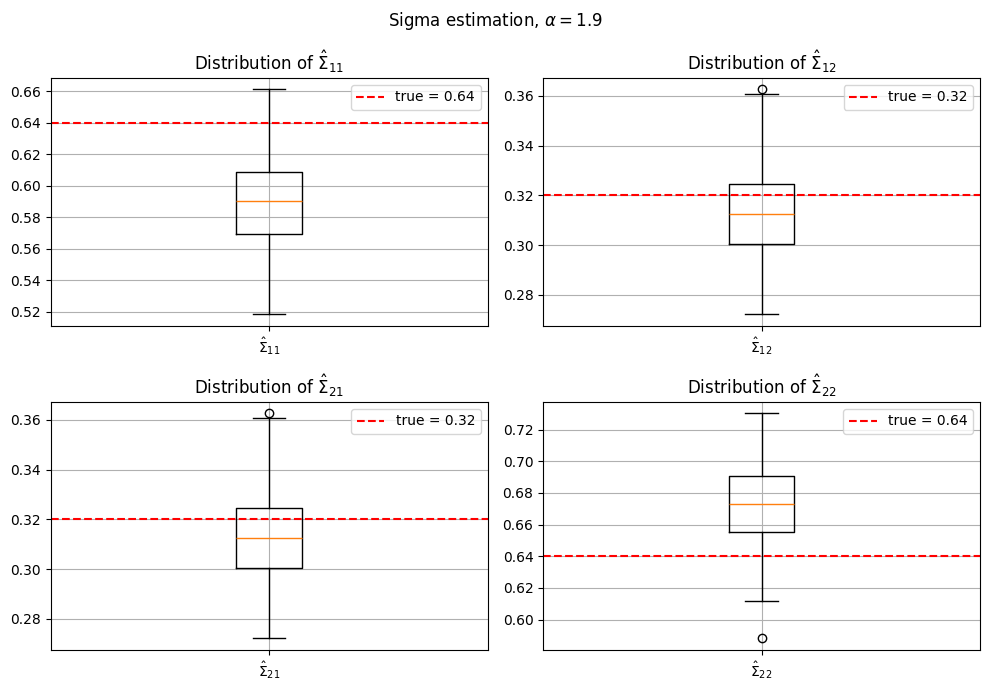

In [218]:
plot_sigma_boxplots(mc_2d_final_sigma[1.9])

The raw estimates of $\Sigma$ showed a systematic deviation in the diagonal entries. This effect is caused by the fact that $\Sigma$ is estimated at the final stage of the pipeline and is therefore very sensitive to small errors in the reconstruction of the componentwise scale functions.

To verify this effect, a scale-adjusted version of the Sigma estimates was also computed in the simulation study. Since the true scale functions are known for simulated data, the estimated Sigma matrices were transformed back using the median ratio between the estimated and true scale functions. The adjusted estimates were much closer to the true covariance matrix, which confirms that the main source of bias was scale reconstruction rather than the characteristic-function fitting itself.

In [ ]:
phi_source_alpha2 = run_phi_source_diagnostic(
    alpha=2.0,
    trend_window=101,
    scale_window=151,
    n_replications=50,
)

phi_source_summary_alpha2 = (
    phi_source_alpha2
    .groupby("variant")
    .agg(
        mean_phi_hat=("phi_hat", "mean"),
        median_phi_hat=("phi_hat", "median"),
        std_phi_hat=("phi_hat", "std"),
    )
    .reset_index()
)

phi_source_summary_alpha2

,variant,mean_phi_hat,median_phi_hat,std_phi_hat
0,estimated_trend_true_scale,0.485743,0.485840,0.019577
1,full_pipeline,0.482897,0.482109,0.019344
2,oracle_true_R2,0.501829,0.503141,0.019641
3,true_trend_estimated_scale,0.499251,0.500974,0.019394
4,true_trend_true_scale,0.501829,0.503141,0.019641


$\alpha=1.9$

In [206]:
def add_scale_adjusted_sigma(mc_2d_results, alphas_order, trim_edges=100):
    """
    Adds scale-adjusted Sigma estimates to Monte Carlo results.

    If the estimated scale is not exactly equal to the true scale, the residuals
    are effectively rescaled. Since Sigma is estimated from these residuals,
    we correct Sigma by the median scale ratio of each component.

    This is a diagnostic correction for simulated data, where the true scale is known.
    """
    for alpha in alphas_order:
        result = mc_2d_results[alpha]

        SC_hats = result["SC_hats"]
        true_SC = result["true_SC"]
        Sigma_hats = result["Sigma_hats"]

        ratios = SC_hats / true_SC[None, :, :]

        if trim_edges > 0:
            ratios_inner = ratios[:, trim_edges:-trim_edges, :]
        else:
            ratios_inner = ratios

        d1 = np.median(ratios_inner[:, :, 0])
        d2 = np.median(ratios_inner[:, :, 1])

        D = np.diag([d1, d2])

        Sigma_hats_adjusted = np.array([
            D @ Sigma_hat @ D
            for Sigma_hat in Sigma_hats
        ])

        result["Sigma_hats_adjusted"] = Sigma_hats_adjusted
        result["sigma_scale_adjustment"] = {
            "d1": d1,
            "d2": d2,
            "D": D,
        }

    return mc_2d_results

In [207]:
mc_2d_final_sigma = add_scale_adjusted_sigma(
    mc_2d_final_sigma,
    alphas_order_2d,
    trim_edges=100,
)

In [208]:
def scale_ratio_2d_summary(mc_2d_results, alphas_order, trim_edges=100):
    rows = []

    for alpha in alphas_order:
        result = mc_2d_results[alpha]

        SC_hats = result["SC_hats"]
        true_SC = result["true_SC"]

        ratios = SC_hats / true_SC[None, :, :]

        if trim_edges > 0:
            ratios_inner = ratios[:, trim_edges:-trim_edges, :]
        else:
            ratios_inner = ratios

        rows.append({
            "alpha": alpha,

            "mean_ratio_sc1": np.mean(ratios_inner[:, :, 0]),
            "median_ratio_sc1": np.median(ratios_inner[:, :, 0]),

            "mean_ratio_sc2": np.mean(ratios_inner[:, :, 1]),
            "median_ratio_sc2": np.median(ratios_inner[:, :, 1]),

            "mean_ratio_all": np.mean(ratios_inner),
            "median_ratio_all": np.median(ratios_inner),
        })

    return pd.DataFrame(rows)

In [209]:
scale_ratio_2d_final = scale_ratio_2d_summary(
    mc_2d_final_sigma,
    alphas_order_2d,
    trim_edges=100,
)

scale_ratio_2d_final

,alpha,mean_ratio_sc1,median_ratio_sc1,mean_ratio_sc2,median_ratio_sc2,mean_ratio_all,median_ratio_all
0,1.85,1.075479,1.068317,1.007357,1.002663,1.041418,1.034316
1,1.90,1.047053,1.041907,0.982662,0.979347,1.014857,1.008915
2,1.95,1.022331,1.017835,0.959241,0.955881,0.990786,0.986031
3,2.00,1.001489,0.998018,0.942397,0.938622,0.971943,0.966717


In [210]:
mc_2d_sigma_adjusted_summary_rows = []

for alpha in alphas_order_2d:
    result = mc_2d_final_sigma[alpha]
    Sigma_hats_adj = result["Sigma_hats_adjusted"]

    mc_2d_sigma_adjusted_summary_rows.append({
        "true_alpha": alpha,

        "d1_scale_ratio": result["sigma_scale_adjustment"]["d1"],
        "d2_scale_ratio": result["sigma_scale_adjustment"]["d2"],

        "mean_sigma_11_adj": np.mean(Sigma_hats_adj[:, 0, 0]),
        "median_sigma_11_adj": np.median(Sigma_hats_adj[:, 0, 0]),
        "true_sigma_11": Sigma_true[0, 0],

        "mean_sigma_12_adj": np.mean(Sigma_hats_adj[:, 0, 1]),
        "median_sigma_12_adj": np.median(Sigma_hats_adj[:, 0, 1]),
        "true_sigma_12": Sigma_true[0, 1],

        "mean_sigma_21_adj": np.mean(Sigma_hats_adj[:, 1, 0]),
        "median_sigma_21_adj": np.median(Sigma_hats_adj[:, 1, 0]),
        "true_sigma_21": Sigma_true[1, 0],

        "mean_sigma_22_adj": np.mean(Sigma_hats_adj[:, 1, 1]),
        "median_sigma_22_adj": np.median(Sigma_hats_adj[:, 1, 1]),
        "true_sigma_22": Sigma_true[1, 1],
    })

mc_2d_sigma_adjusted_summary = pd.DataFrame(mc_2d_sigma_adjusted_summary_rows)
mc_2d_sigma_adjusted_summary

,true_alpha,d1_scale_ratio,d2_scale_ratio,mean_sigma_11_adj,median_sigma_11_adj,true_sigma_11,mean_sigma_12_adj,median_sigma_12_adj,true_sigma_12,mean_sigma_21_adj,median_sigma_21_adj,true_sigma_21,mean_sigma_22_adj,median_sigma_22_adj,true_sigma_22
0,1.85,1.068317,1.002663,0.640351,0.636694,0.64,0.321182,0.319036,0.32,0.321182,0.319036,0.32,0.644775,0.642397,0.64
1,1.90,1.041907,0.979347,0.639784,0.640598,0.64,0.318295,0.318807,0.32,0.318295,0.318807,0.32,0.645151,0.645720,0.64
2,1.95,1.017835,0.955881,0.641328,0.637132,0.64,0.321054,0.319177,0.32,0.321054,0.319177,0.32,0.642425,0.644625,0.64
3,2.00,0.998018,0.938622,0.644524,0.642719,0.64,0.320682,0.318621,0.32,0.320682,0.318621,0.32,0.641894,0.644209,0.64


In [211]:
def plot_sigma_boxplots_adjusted(result):
    Sigma_hats = result["Sigma_hats_adjusted"]
    true_Sigma = result["true_Sigma"]
    alpha = result["alpha"]

    entries = [
        (0, 0, r"$\hat{\Sigma}_{11}^{adj}$", true_Sigma[0, 0]),
        (0, 1, r"$\hat{\Sigma}_{12}^{adj}$", true_Sigma[0, 1]),
        (1, 0, r"$\hat{\Sigma}_{21}^{adj}$", true_Sigma[1, 0]),
        (1, 1, r"$\hat{\Sigma}_{22}^{adj}$", true_Sigma[1, 1]),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(10, 7))

    for ax, (i, j, label, true_value) in zip(axes.ravel(), entries):
        values = Sigma_hats[:, i, j]
        ax.boxplot(values, labels=[label])
        ax.axhline(true_value, linestyle="--", color="red", label=f"true = {true_value:.2f}")
        ax.set_title(f"Distribution of {label}")
        ax.grid(True)
        ax.legend()

    fig.suptitle(rf"Scale-adjusted Sigma estimation, $\alpha={alpha}$")
    plt.tight_layout()
    plt.show()

/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' paramet

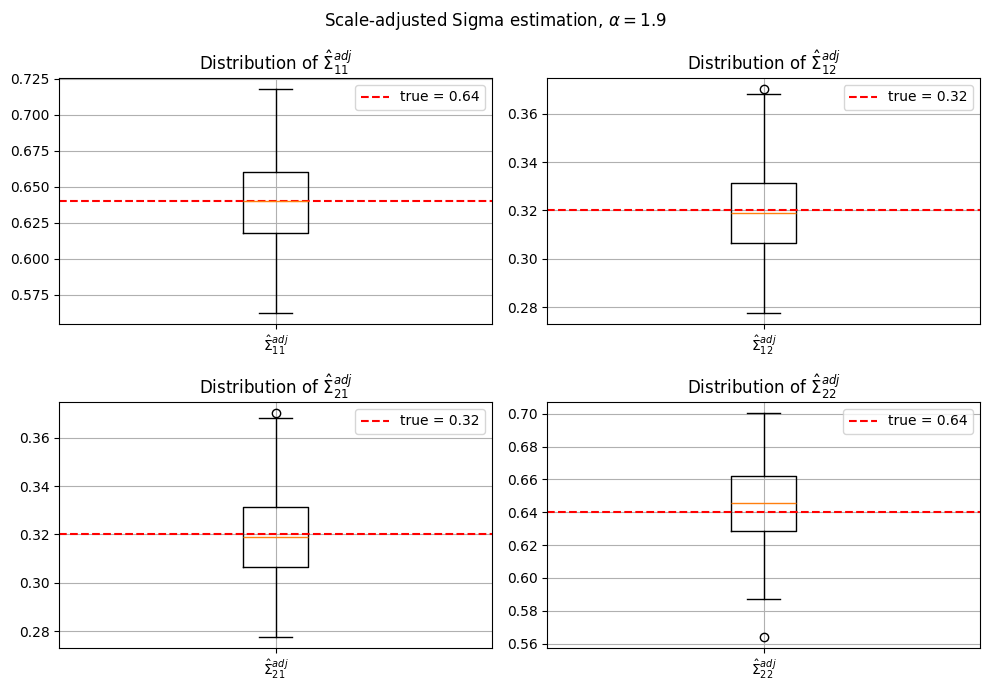

In [212]:
plot_sigma_boxplots_adjusted(mc_2d_final_sigma[1.90])

In [213]:
mc_2d_sigma_adjusted_summary_rows = []

for alpha in alphas_order_2d:
    result = mc_2d_final_sigma[alpha]
    Sigma_hats_adj = result["Sigma_hats_adjusted"]

    mc_2d_sigma_adjusted_summary_rows.append({
        "true_alpha": alpha,

        "d1_scale_ratio": result["sigma_scale_adjustment"]["d1"],
        "d2_scale_ratio": result["sigma_scale_adjustment"]["d2"],

        "mean_sigma_11_adj": np.mean(Sigma_hats_adj[:, 0, 0]),
        "median_sigma_11_adj": np.median(Sigma_hats_adj[:, 0, 0]),
        "true_sigma_11": Sigma_true[0, 0],

        "mean_sigma_12_adj": np.mean(Sigma_hats_adj[:, 0, 1]),
        "median_sigma_12_adj": np.median(Sigma_hats_adj[:, 0, 1]),
        "true_sigma_12": Sigma_true[0, 1],

        "mean_sigma_21_adj": np.mean(Sigma_hats_adj[:, 1, 0]),
        "median_sigma_21_adj": np.median(Sigma_hats_adj[:, 1, 0]),
        "true_sigma_21": Sigma_true[1, 0],

        "mean_sigma_22_adj": np.mean(Sigma_hats_adj[:, 1, 1]),
        "median_sigma_22_adj": np.median(Sigma_hats_adj[:, 1, 1]),
        "true_sigma_22": Sigma_true[1, 1],
    })

mc_2d_sigma_adjusted_summary = pd.DataFrame(mc_2d_sigma_adjusted_summary_rows)
mc_2d_sigma_adjusted_summary

,true_alpha,d1_scale_ratio,d2_scale_ratio,mean_sigma_11_adj,median_sigma_11_adj,true_sigma_11,mean_sigma_12_adj,median_sigma_12_adj,true_sigma_12,mean_sigma_21_adj,median_sigma_21_adj,true_sigma_21,mean_sigma_22_adj,median_sigma_22_adj,true_sigma_22
0,1.85,1.068317,1.002663,0.640351,0.636694,0.64,0.321182,0.319036,0.32,0.321182,0.319036,0.32,0.644775,0.642397,0.64
1,1.90,1.041907,0.979347,0.639784,0.640598,0.64,0.318295,0.318807,0.32,0.318295,0.318807,0.32,0.645151,0.645720,0.64
2,1.95,1.017835,0.955881,0.641328,0.637132,0.64,0.321054,0.319177,0.32,0.321054,0.319177,0.32,0.642425,0.644625,0.64
3,2.00,0.998018,0.938622,0.644524,0.642719,0.64,0.320682,0.318621,0.32,0.320682,0.318621,0.32,0.641894,0.644209,0.64


/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' paramet

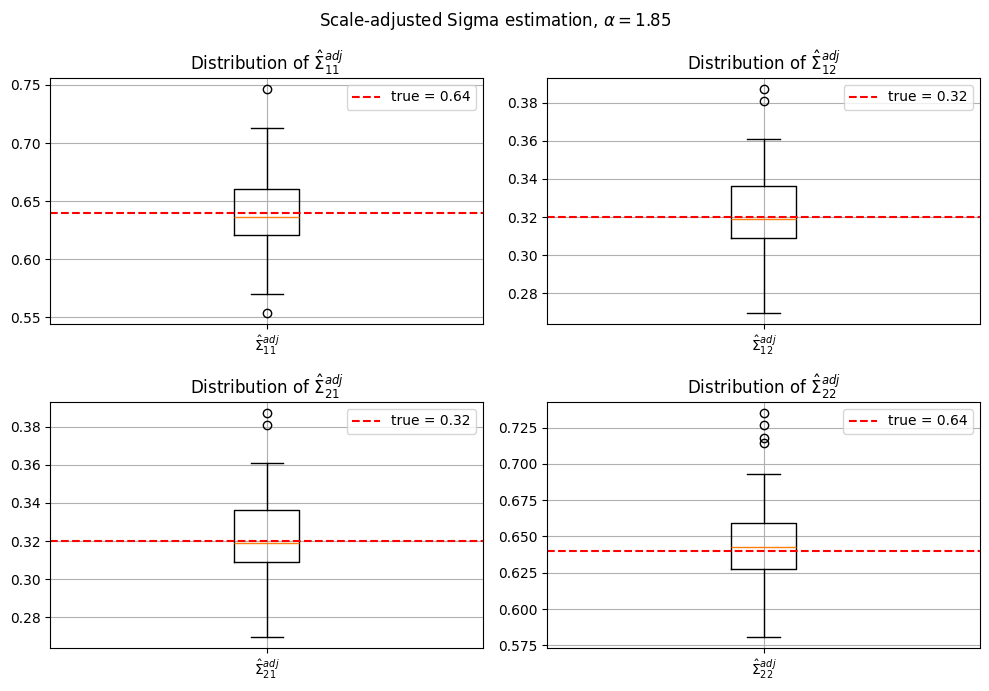

/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' paramet

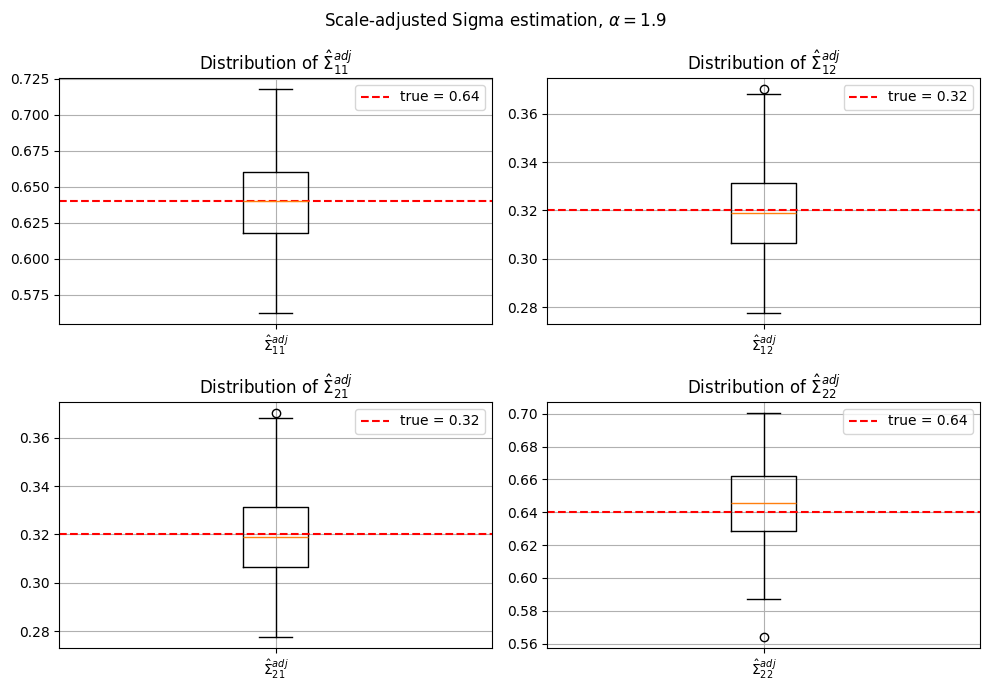

/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' paramet

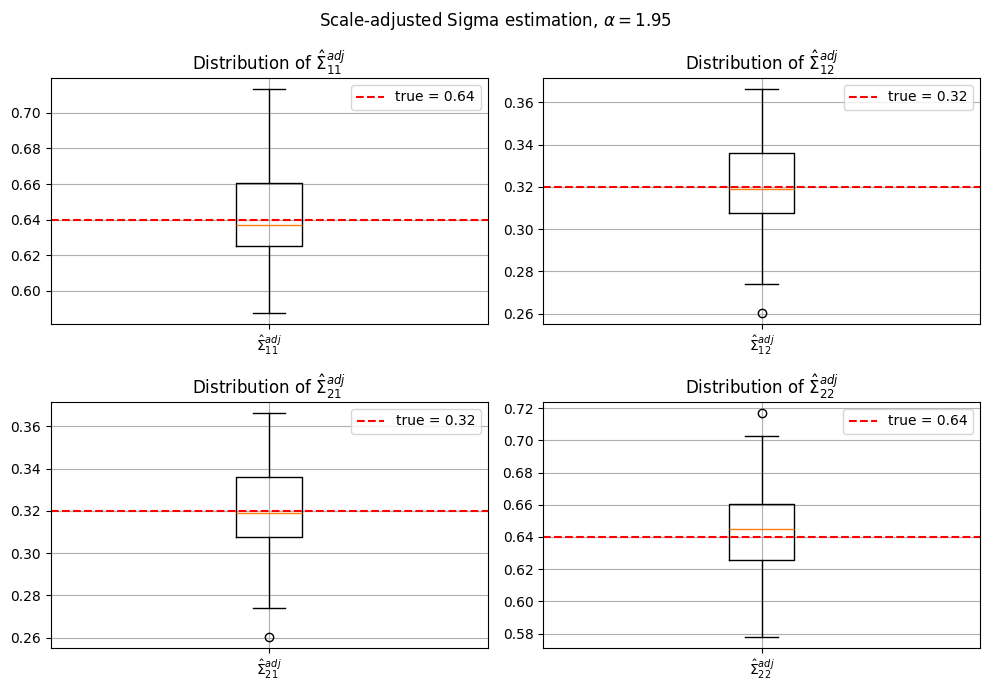

/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4002663885.py:17: MatplotlibDeprecationWarning: The 'labels' paramet

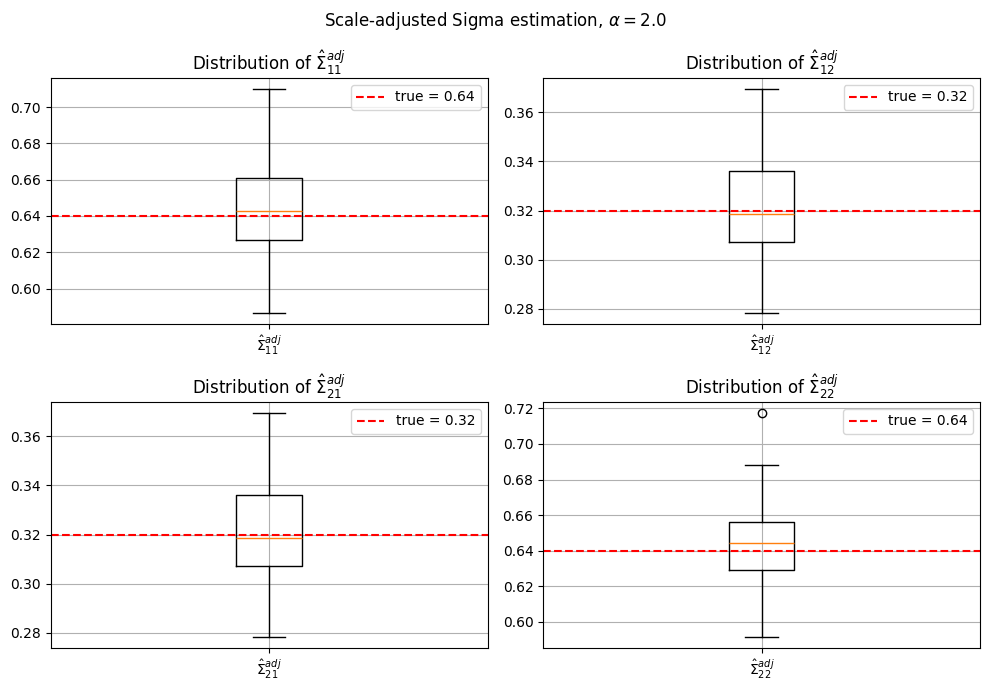

In [214]:
for alpha in alphas_order_2d:
    plot_sigma_boxplots_adjusted(mc_2d_final_sigma[alpha])

## jAK W PRACY

In [215]:
def plot_mc_2d_part2_with_adjusted_sigma(result):
    alpha = result["alpha"]
    est_rep = result["representative_est"]

    diagnostics_R3 = est_rep["diagnostics_R3"]
    R3_hat = est_rep["R3_hat"]

    Sigma_hats = result["Sigma_hats_adjusted"]
    true_Sigma = result["true_Sigma"]

    fig, axes = plt.subplots(4, 2, figsize=(13, 15))

    # ACF/CCF after VAR(1)
    names = [
        ("acf_1", "ACF component 1", axes[0, 0]),
        ("ccf_12", "CCF component 1 vs 2", axes[0, 1]),
        ("ccf_21", "CCF component 2 vs 1", axes[1, 0]),
        ("acf_2", "ACF component 2", axes[1, 1]),
    ]

    band = 1.96 / np.sqrt(len(R3_hat))

    for key, title, ax in names:
        values = diagnostics_R3[key]
        lags = np.arange(len(values))

        ax.stem(lags, values)
        ax.axhline(0, linewidth=1)
        ax.axhline(band, linestyle="--", label="approx. 95% band")
        ax.axhline(-band, linestyle="--")
        ax.set_title(rf"After VAR(1), $\alpha={alpha}$: {title}")
        ax.set_xlabel("Lag")
        ax.set_ylabel("value")
        ax.grid(True)
        ax.legend()

    # Adjusted Sigma boxplots
    sigma_entries = [
        (0, 0, r"$\hat{\Sigma}_{11}^{adj}$", true_Sigma[0, 0], axes[2, 0]),
        (0, 1, r"$\hat{\Sigma}_{12}^{adj}$", true_Sigma[0, 1], axes[2, 1]),
        (1, 0, r"$\hat{\Sigma}_{21}^{adj}$", true_Sigma[1, 0], axes[3, 0]),
        (1, 1, r"$\hat{\Sigma}_{22}^{adj}$", true_Sigma[1, 1], axes[3, 1]),
    ]

    for i, j, label, true_value, ax in sigma_entries:
        values = Sigma_hats[:, i, j]
        ax.boxplot(values, labels=[label])
        ax.axhline(true_value, linestyle="--", color="red", label=f"true = {true_value:.2f}")
        ax.set_title(f"Distribution of {label}")
        ax.grid(True)
        ax.legend()

    fig.suptitle(
        rf"Monte Carlo estimation results for the two-dimensional model, $\alpha={alpha}$ — part II",
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()

    # Alpha boxplot separately
    plt.figure(figsize=(6, 5))
    plt.boxplot(result["alpha_hats"], labels=[r"$\hat{\alpha}$"])
    plt.axhline(alpha, linestyle="--", color="red", label=rf"true $\alpha={alpha}$")
    plt.title(rf"Distribution of stability index estimates, $\alpha={alpha}$")
    plt.ylabel(r"$\hat{\alpha}$")
    plt.grid(True)
    plt.legend()
    plt.show()

/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/554680248.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/554680248.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/554680248.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[label])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/554680248.py:47: MatplotlibDeprecationWarning: The 'labels' parameter o

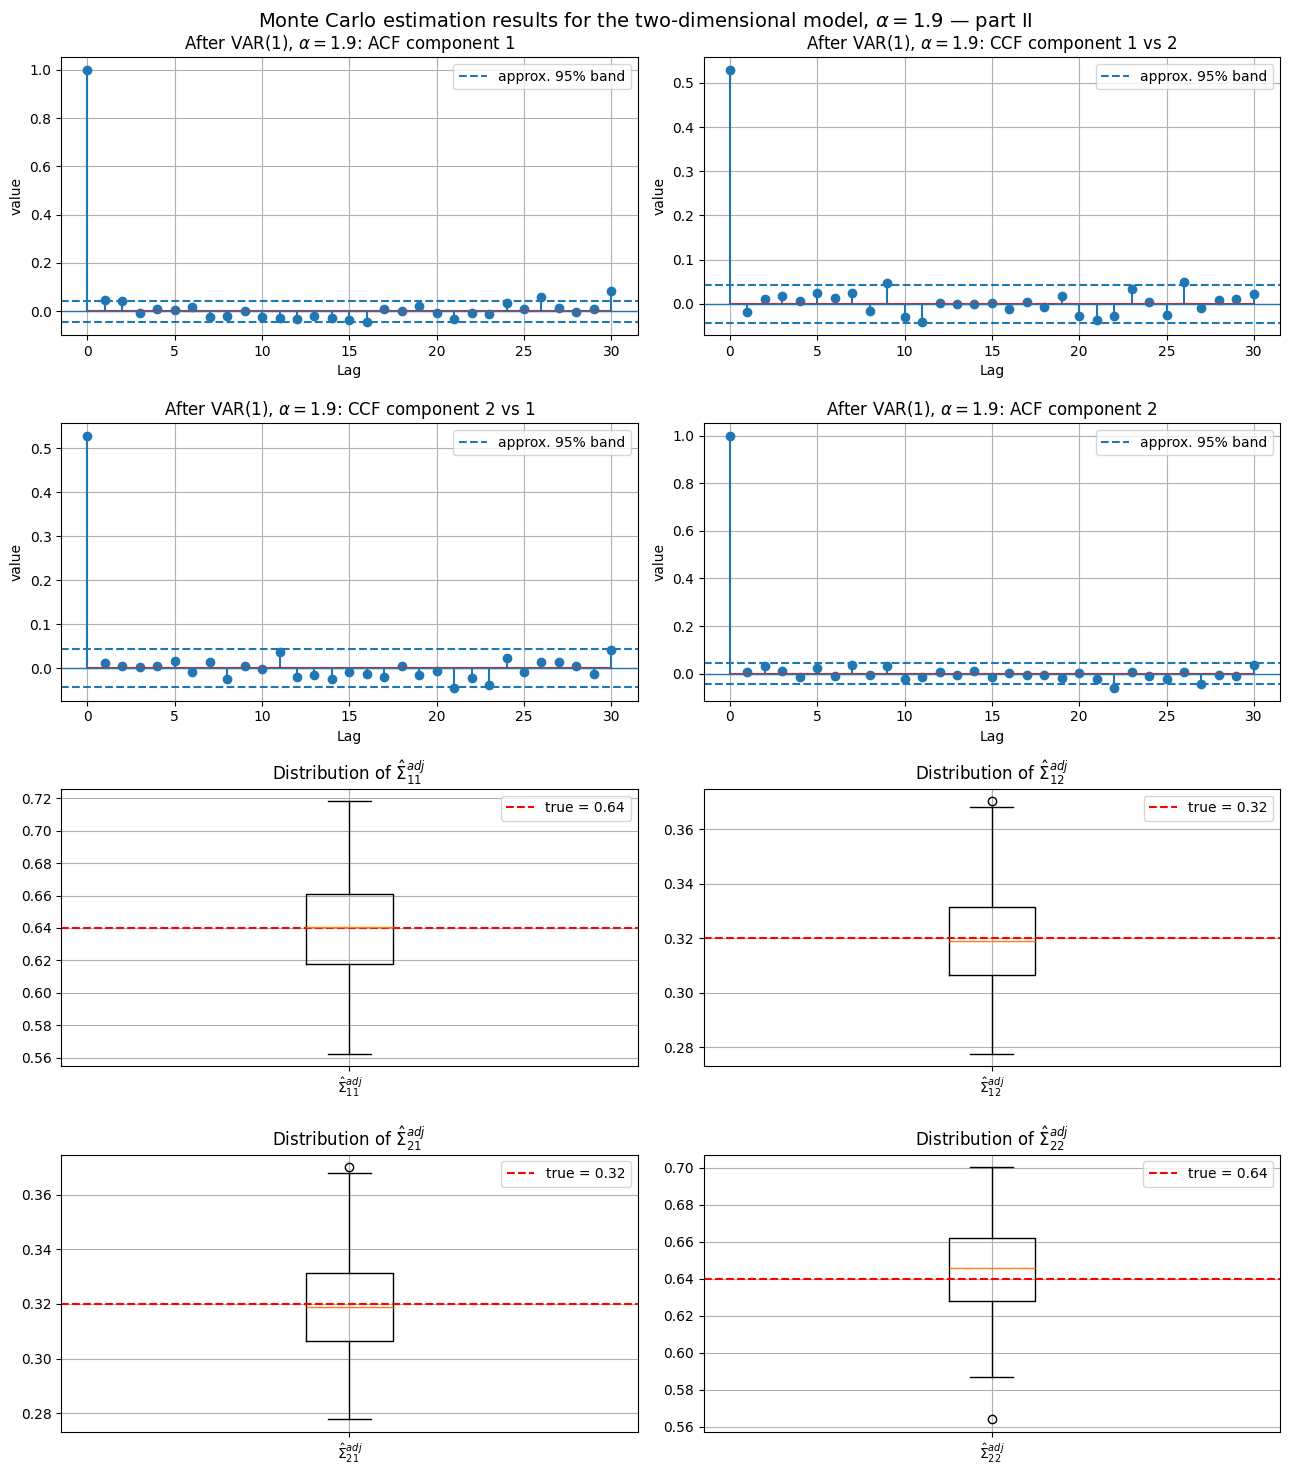

/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/554680248.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result["alpha_hats"], labels=[r"$\hat{\alpha}$"])


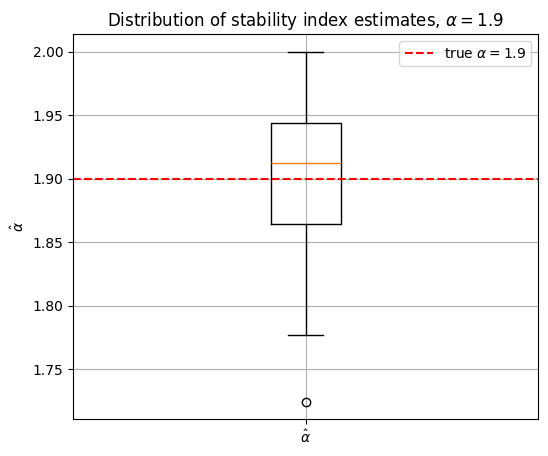

In [216]:
plot_mc_2d_part2_with_adjusted_sigma(mc_2d_final_sigma[1.90])

The adjusted Sigma estimates are centred close to the true values. The off-diagonal entries are recovered particularly well, which means that the contemporaneous dependence between the two components is properly captured. The diagonal entries also improve substantially after scale adjustment.